In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR01 — ÜDM: real artım, deflyator, sektor və mülkiyyət strukturu

ÜDM-in real artım tempinin, deflyator indeksinin, dövlət və qeyri-dövlət sektorunun, neft və qeyri-neft
sektorunun payının, onların artım və deflyator indekslərinin proqnozlaşdırılması (MİİS §15.5.1, bənd
2.4.1.1.; hüquqi əsas — Nazirlər Kabinetinin 24.05.2004 tarixli 75 nömrəli qərarı, bənd 2.4.1).

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR1):** "ÜDM-in real artım, deflyator indeksi, dövlət və qeyri-dövlət
sektorunun, neft və qeyri-neft sektorunun payı, onların artım və deflyator indeksləri tempinin
proqnozlaşdırılması."

Tələb bir deyil, üç ayrı kəmiyyət qrupunu əhatə edir və bunların hər biri ayrıca modelləşdirmə tələb
edir. Birincisi, **məcmu göstərici**: ÜDM-in real artım tempi və deflyatoru. İkincisi, **sektor
bölgüsü**: neft-qaz və qeyri neft-qaz sektorlarının payları və hər ikisi üçün ayrıca artım və deflyator
indeksləri. Üçüncüsü, **mülkiyyət bölgüsü**: dövlət və qeyri-dövlət (özəl) sektorunun ÜDM-də payı.
Məcmu göstərici müstəqil qiymətləndirilmir — o, blokların cəmindən **eynilik yolu ilə** alınır;
beləliklə paketdə "ÜDM ayrıca, sektorlar ayrıca proqnozlaşdırılıb, sonra fərq gizlədilib" vəziyyəti
konstruksiya ilə mümkün deyil.

**Bu buraxılışın quruluş dəyişikliyi (istehsal metoduna keçid).** Əvvəlki buraxılışda qeyri-neft artımı burada,
simultan tələb nüvəsi ilə həll olunur, FR02-nin on bir sahə tənliyi isə həmin məcmuya mütənasib
**miqyaslanırdı** — yəni sahə blokunun öz cəmi ilə baş göstərici arasındakı fərq düzəliş içində
görünmür idi. v3-də istiqamət tərsinə çevrilib: **baş göstərici sahə tənliklərinin cəmidir**
(istehsal metodu), miqyaslama yoxdur, bu dəftər həmin aqreqatı FR02-nin çıxışından oxuyur.
Tələb tərəfinin simultan nüvəsi **saxlanılır** — o, indi iki vəzifə daşıyır: (i) xərc tərəfinin
müstəqil oxunuşu kimi istehsal hesabına qarşı çarpaz yoxlama, (ii) ssenari
mühərriki, çünki investisiya, istehlak və gəlir yolları (`g_inv_core`, `g_cons_core`, `g_income_core`)
FR6 və FR8 üçün məhz buradan gəlir. İki oxunuş arasındakı fərq **nə ortalanır, nə də biri digərinə
uyğunlaşdırılır**: `gdp_nonoil_gap` sırası kimi nəşr olunur və dözüm qapısı ilə ölçülür (Bölmə 7.6).

**Tələb-təklif tarazlığı bu dəftərdə DEYİL, FR01b-dədir.** İcmalın «modeldə tələb və təklif
tarazlığı görünmür» qeydi bu buraxılışda ayrıca dəftərlə bağlanır: **FR01b** ÜDM-in tam istifadə
(xərc) hesabını qurur və resurslar–istifadə eyniliyini 2013–2030-un hər ili üçün bağlayır. İki
dəftərin bölgüsü belədir və qarışdırılmamalıdır:

| | bu dəftər (Bölmə 7.6) | FR01b |
|---|---|---|
| **Nə ölçülür** | qeyri-neft ÜDM-in İKİ oxunuşu arasındakı fərq | bütün iqtisadiyyat üzrə resursların və istifadənin fərqi |
| **Neçə komponent** | iki aqreqat (istehsal cəmi, tələb nüvəsi) | altı komponent + statistik fərq |
| **Eynilik bağlanırmı** | **xeyr** — fərq nəşr olunur, düzəliş edilmir | **bəli** — hər il, açıq elan olunmuş qapanma qaydası ilə |
| **Nəşr olunan fərq** | `gdp_nonoil_gap`, `gdp_nonoil_gap_pct` | `use_balance_gap`, `use_balance_gap_pct` |

Bu dəftər FR01b-nin nəticələrini **oxumur və sitat gətirmir**: icra ardıcıllığında FR01b bu
dəftərdən SONRA gəlir (aşağıda), ona görə buradakı hər rəqəm yalnız bu dəftərin öz hesablamasıdır.
İki ölçünün tutuşdurulması FR01b-nin 6-cı bölməsində — hər ikisinin canlı mövcud olduğu yeganə
yerdə — aparılır və FR12-nin paket səviyyəli zəncirində təkrarlanır.

İcra ardıcıllığında (BUILD_CONTEXT §D2) bu dəftər FR5 (neftin dünya qiyməti), FR10 (valyuta məzənnəsi),
FR05b (neft-qaz bloku) və FR9 (inflyasiya) mərhələlərindən sonra gəlir. Çevrilmə səbəbindən boru
xəttində dəftər **iki dəfə** işə salınır: birinci keçiddə nüvə həll olunur və FR02-nin tələb etdiyi
fərziyyə açarları (`oil_defl`, `g_inv_core`, `partner_gdp_realg` və s.) yazılır; FR02 işlədikdən sonra
ikinci keçiddə baş göstərici artıq hazır aşağıdan-yuxarı aqreqatdan yığılır. Blok səviyyəsində asılılıq
dövrəvi deyil — nüvənin həlli FR02-dən asılı olmadığı üçün ardıcıllıq iki keçiddə dəqiq bağlanır
(`run_all.py`: FR01 → FR02 → FR01). Aşağı axın üçün bu dəftər yenə mərkəzi girişdir: FR3 fəaliyyət
strukturunu, FR6 investisiyanın, FR8 isə gəlir və xərclərin yolunu buradan alır. **FR01b** də aşağı
axındadır — o, FR07-dən sonra işləyir və bu dəftərdən üç şey götürür: `g_cons_core` (ev
təsərrüfatı istehlakının real artımı), `gov_cons_total` (dövlətin son istehlakının səviyyə yolu) və
`gdp_nonoil_gap_pct` (müqayisə üçün). Əks istiqamətdə asılılıq YOXDUR.

## 2. Məlumat

İstifadə olunan sıralar (faktiki dəyərlər yalnız `data_layer` vasitəsilə oxunur və HƏMİŞƏ ≤ 2025 ilində
bitir):

| `series_code` | Təsvir | Vahid | Mənbə | Əhatə |
|---|---|---|---|---|
| `gdp_nom`, `oil_nom`, `nonoil_nom` | ÜDM və onun neft / qeyri-neft hissəsi, cari qiymətlərlə | mln AZN | 8 vərəq 2.4.1.1.; 2025 üçün DSK-nın rəsmi nəticəsi | 2013–2025 |
| `gdp_realg`, `oil_realg`, `nonoil_realg` | real artım templəri | % | eyni mənbə | 1991 / 2013–2025 |
| `gdp_defl`, `oil_defl`, `nonoil_defl` | deflyator indeksləri | % | eyni mənbə | 1991 / 2013–2025 |
| `real_r005`–`real_r008` | qeyri-neft və neft ÜDM-in həcmi və real artımı (iş kitabı) | mln AZN, % | Real sektor, sətirlər 5–8 | 2000–2025 |
| `private_share_gdp` | özəl sektorun ÜDM-də payı | % | Real sektor, sətir 10 | 1995–2025 |
| `inv_total_g` | əsas kapitala investisiyaların real artım tempi | % | 8 vərəq 2.4.1.5.-7. | 2001–2025 |
| `final_consumption` | son istehlak xərcləri | mln AZN | `macro_annual.csv` | 2000–2025 |
| `income_nom`, `income_realg` | əhalinin pul gəlirləri və onun real artımı | mln AZN, % | 8 vərəq 2.4.1.5.-7. | 1997 / 2013–2024 |
| `partner_gdp_realg` | tərəfdaş ölkələrin ÜDM artımı | % | `external_block_annual.csv` (IMF WEO) | 2000–2030 |
| `money_r029` | M2 pul aqreqatı | mln manat | Monetar sektoru, sətir 29 | 2006–2025 |
| `brent_usd`, `fx_usd_azn_eop` | neftin dünya qiyməti, məzənnə (dövrün sonuna) | USD/barel, AZN/USD | Neft-Qaz sətir 11; Monetar sətir 114 | 1991 / 1995–2025 |
| `pop_avg` | əhalinin orta illik sayı | min nəfər | 8 vərəq 2.4.1.1. | 1991–2025 |

Proqnoz üfüqünün girişləri paketin vahid fərziyyə dəstindən (`data/assumptions.csv`) oxunur:
`brent_usd` (FR5), `cpi_infl` (FR9), `usd_azn` (FR10), `oil_realg` və `oilgas_pw_g` — son iki açar
FR05b-nin neft-qaz blokunun nəticəsidir: real artım əmtəəlik hasilat həcmlərinin dəyər çəkili
indeksindən, qiymət kanalı isə ixrac dəyəri ilə çəkilənmiş neft+qaz qiymət indeksindən gəlir
(bu dəftər üçün onlar yuxarı axının nəticəsidir; hasilat həcmi
SOCAR-ın istehsal cədvəli ilə müəyyən olunur və ekonometrik modelləşdirmə obyekti deyil).

### 2.0. İstehsal hesabı — FR02-nin çıxışı bu dəftərin girişidir (istehsal metoduna keçid)

Baş göstəricinin blokları `outputs/forecast_long.csv`-dən, FR02-nin sətirlərindən oxunur; bu dəftər
onları yenidən hesablamır və heç birini miqyaslamır:

| FR02 sırası | Təsvir | Bu dəftərdə rolu |
|---|---|---|
| `gdp_nonoil_prod` | qeyri-neft ÜDM, bazar qiymətləri ilə (Σ sahə əlavə dəyəri + qeyri-neft xalis vergiləri) | `nonoil_nom` səviyyəsi |
| `gdp_oilgas_prod` | neft-qaz ÜDM, bazar qiymətləri ilə (neft-qaz hasilatının əlavə dəyəri + neft xalis vergiləri) | `oil_nom` səviyyəsi |
| `gdp_prod` | istehsal metodu ilə məcmu ÜDM | `gdp_nom` səviyyəsi (eynilik yoxlanılır) |
| `gdp_nonoil_realg_prod` | qeyri-neft həcm aqreqatının real artımı | `nonoil_realg` — **baş göstərici** |
| `gdp_nonoil_defl_prod` | həmin aqreqatın implisit deflyatoru | `nonoil_defl` |
| `va_nonoil_prod`, `va_mining_oilgas`, `net_taxes`, `net_taxes_g` | həcm aqreqasiyasının üç komponenti və onların çəkiləri | məcmu real artımın çəkili cəmi |
| `va_mining_nonoil` | qeyri-neft mədənçıxarma | tərif fərqinin ölçüsü (aşağıda) |

**Tərif qeydi — qeyri-neft mədənçıxarma.** Statutar şablonun (8 vərəq) neft/qeyri-neft bölgüsündə
mədənçıxarma sənayesi bütövlükdə neft-qaz blokundadır. İstehsal hesabında isə sahə **iki yerə**
ayrılır (`Mədənçıxarma` vərəqi, sətir 4 və sətir 9): xam neft və qaz hasilatı neft-qaz blokunda qalır,
metal filizləri və digər mədənçıxarma isə qeyri-neft blokuna aid edilir. 2025-ci ildə bu, **2 116,4
mln AZN**-dir — qeyri-neft ÜDM-i 92 307,1 əvəzinə 94 423,5, neft-qaz ÜDM-i 36 786,9 əvəzinə
34 670,5 mln AZN olur; **məcmu ÜDM dəyişmir** (129 094,0). Bölgü həm tarixi hissədə, həm proqnozda
EYNİ tərif üzərində qurulduğu üçün 2025/2026 sərhədində süni sıçrayış yoxdur. **DATA-GAP:**
mədənçıxarmanın alt-sətirləri iş kitabında 2016-cı ildən başlayır, ona görə bu dəftərin nəşr etdiyi
`oil_nom` / `nonoil_nom` / `oil_share` / `nonoil_share` faktiki sıraları 2016-cı ildən verilir;
məcmu `gdp_nom` isə əvvəlki kimi 2013-dən başlayır.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from IPython.display import Math, display

pd.set_option("display.width", 200)
LA, FY = config.LAST_ACTUAL, list(config.FY)          # 2025 və 2026–2030
WB = "Statistik data dinamika 05.06.2026 +.xlsx"

# --- ÜDM-in səviyyə və temp sıraları (statutar şablon) --------------------
gdp_nom = data_layer.actuals("gdp_nom")               # ÜDM bazar qiymətləri ilə, mln AZN
oil_nom = data_layer.actuals("oil_nom")               # neft-qaz sektoru ÜDM-i
non_nom = data_layer.actuals("nonoil_nom")            # qeyri neft-qaz sektoru ÜDM-i
gdp_g_pub = data_layer.actuals("gdp_realg")           # nəşr olunmuş ÜDM real artımı, 1991-dən
oil_g = data_layer.actuals("oil_realg")
non_g_pub = data_layer.actuals("nonoil_realg")

print(f"ÜDM (səviyyə) əhatəsi : {int(gdp_nom.index.min())}–{int(gdp_nom.index.max())}, n = {len(gdp_nom)}")
print(f"ÜDM real artımı       : {int(gdp_g_pub.index.min())}–{int(gdp_g_pub.index.max())}, n = {len(gdp_g_pub)}")
print(f"2025 bazası (DSK)     : {gdp_nom.loc[LA]:,.1f} mln AZN "
      f"= neft {oil_nom.loc[LA]:,.1f} + qeyri-neft {non_nom.loc[LA]:,.1f}")

ÜDM (səviyyə) əhatəsi : 2013–2025, n = 13
ÜDM real artımı       : 1991–2025, n = 35
2025 bazası (DSK)     : 129,094.0 mln AZN = neft 36,786.9 + qeyri-neft 92,307.1


### 2.1. Nümunənin uzadılması: iş kitabının Real sektor bloku

Statutar şablonun ÜDM bölgüsü yalnız 2013-cü ildən başlayır (n = 13). Bu, davranış tənliyi qurmaq üçün
qısadır. Əsas iş kitabının **Real sektor** vərəqi isə eyni anlayışları — qeyri-neft və neft ÜDM-in
həcmini və real artım tempini — 2000-ci ildən daşıyır (sətirlər 5–8). Aşağıda iki mənbənin üst-üstə
düşən illəri tutuşdurulur. On üç ilin **onunda** fərq 0,05 faiz bəndindən kiçikdir (iş kitabı bir
onluq işarəyə yuvarlaqlaşdırılıb); **üç ildə** — 2013 (0,18), 2015 (0,37) və 2024 (0,30) — fərq bundan
böyükdür və həmin illər üçün mənbələr arasında buraxılış fərqi var. Belə hallarda **statutar şablon üstün tutulur**:
2013–2025 üçün onun dəyərləri, 2000–2012 üçün isə iş kitabının sətirləri götürülür; birləşdirilmiş
sıra qeyri-neft tənliyinin nümunəsini n = 25-ə çatdırır.

In [3]:
non_g_wb = (data_layer.wb_annual("real_r006") - 100.0)          # iş kitabı: qeyri-neft real artım indeksi
non_g_wb = non_g_wb[non_g_wb.index <= LA]                        # struktur mühafizə: 2026 sətri kəsilir
cmp_g = pd.DataFrame({"iş kitabı (Real sektor, sətir 6)": non_g_wb.loc[2013:],
                      "statutar şablon (2.4.1.1.)": non_g_pub})
cmp_g["fərq (p.b.)"] = (cmp_g.iloc[:, 0] - cmp_g.iloc[:, 1]).round(2)
print(f"maksimal mütləq fərq üst-üstə düşən illərdə: "
      f"{cmp_g['fərq (p.b.)'].abs().max():.2f} faiz bəndi")
cmp_g.round(2)

maksimal mütləq fərq üst-üstə düşən illərdə: 0.37 faiz bəndi


,"iş kitabı (Real sektor, sətir 6)",statutar şablon (2.4.1.1.),fərq (p.b.)
year,,,
2013,10.0,10.18,-0.18
2014,7.0,6.97,0.03
2015,1.1,0.73,0.37
2016,-4.5,-4.48,-0.02
2017,2.8,2.84,-0.04
2018,2.0,2.00,0.00
2019,4.0,3.96,0.04
2020,-2.9,-2.95,0.05
2021,7.1,7.13,-0.03


In [4]:
# birləşdirilmiş (splice) sıralar — 2000–2012 iş kitabı, 2013–2025 statutar şablon
g_non = pd.concat([non_g_wb.loc[2000:2012], non_g_pub]).sort_index().rename("g_non")

# qeyri-neft deflyatoru: 2013-dən nəşr olunub; 2001–2012 üçün iş kitabının səviyyə və
# temp sətirlərindən törədilir — deflyator = (nominal artım) / (1 + real artım) − 1
non_nom_wb = data_layer.wb_annual("real_r005"); non_nom_wb = non_nom_wb[non_nom_wb.index <= LA]
d_non_wb = ((non_nom_wb / non_nom_wb.shift(1)) / (1 + non_g_wb / 100) - 1) * 100
d_non = pd.concat([d_non_wb.loc[2001:2012], data_layer.actuals("nonoil_defl")]).sort_index().rename("d_non")

# neft deflyatoru: 2025 üçün nəşr olunmayıb (18 sıradan biri) → eyni eyniliklə tamamlanır
oil_d_pub = data_layer.actuals("oil_defl")
oil_d_der = ((oil_nom / oil_nom.shift(1)) / (1 + oil_g / 100) - 1) * 100
d_oil_short = oil_d_pub.combine_first(oil_d_der)                  # 2013–2025
oil_nom_wb = data_layer.wb_annual("real_r007"); oil_nom_wb = oil_nom_wb[oil_nom_wb.index <= LA]
oil_g_wb = (data_layer.wb_annual("real_r008") - 100.0); oil_g_wb = oil_g_wb[oil_g_wb.index <= LA]
d_oil_wb = ((oil_nom_wb / oil_nom_wb.shift(1)) / (1 + oil_g_wb / 100) - 1) * 100
d_oil = pd.concat([d_oil_wb.loc[2001:2012], d_oil_short]).sort_index().rename("d_oil")

print("2025 üçün tamamlanmış neft deflyatoru (nəşr olunmayıb, eyniliklə hesablanıb): "
      f"{d_oil.loc[LA]:.2f} %")
print("2024 üçün nəzarət — nəşr olunmuş {:.2f} % ilə törədilmiş {:.2f} % üst-üstə düşür"
      .format(oil_d_pub.loc[2024], oil_d_der.loc[2024]))
pd.DataFrame({"qeyri-neft deflyatoru": d_non, "neft deflyatoru": d_oil}).loc[2013:].round(2)

2025 üçün tamamlanmış neft deflyatoru (nəşr olunmayıb, eyniliklə hesablanıb): -7.97 %
2024 üçün nəzarət — nəşr olunmuş -8.19 % ilə törədilmiş -8.19 % üst-üstə düşür


,qeyri-neft deflyatoru,neft deflyatoru
year,,
2013,3.02,-2.99
2014,1.96,-5.93
2015,4.02,-28.73
2016,10.46,24.27
2017,7.70,34.01
2018,3.33,27.58
2019,4.33,-6.82
2020,4.02,-26.72
2021,4.85,63.48


### 2.2. 2025-ci ilin bazası

Paket boyu 2025-ci il üçün **DSK-nın rəsmi göstəricisi — 129 094 mln AZN** əsas götürülür. Statutar
şablonun (8 vərəq) öz buraxılışında həmin il üçün 128 134,2 mln AZN yazılıb; bu, rəsmi nəticə elan
olunmazdan əvvəlki qiymətləndirmədir və paketdə **heç bir hesablamada istifadə edilmir**, yalnız
buraxılış fərqinin ölçüsünü göstərmək üçün bir dəfə qeyd olunur (fərq 0,75 %). Sektor bölgüsü də rəsmi
buraxılışa uyğunlaşdırılıb: 2025-ci ildə neft-qaz 36 786,9 və qeyri neft-qaz 92 307,1 mln AZN, cəmi
dəqiq 129 094,0 mln AZN.

In [5]:
print(f"DSK rəsmi 2025 ÜDM        : {config.SSC_GDP_2025:,.1f} mln AZN")
print(f"8 vərəq şablonunun köhnə buraxılışı: {config.VEREQ_GDP_2025_VINTAGE:,.1f} mln AZN "
      f"(fərq {100*(config.SSC_GDP_2025/config.VEREQ_GDP_2025_VINTAGE-1):.2f} %)")

# balans eyniliyi HƏR il üçün: ÜDM = neft-qaz + qeyri neft-qaz
gap = (gdp_nom - (oil_nom + non_nom)).dropna()
tbl_gap = pd.DataFrame({"ÜDM": gdp_nom, "neft + qeyri-neft": (oil_nom + non_nom),
                        "fərq (mln AZN)": gap}).dropna()
print(f"\nmaksimal mütləq fərq 2013–2025: {gap.abs().max():.2f} mln AZN "
      f"({gap.abs().max()/gdp_nom.loc[gap.abs().idxmax()]*100:.4f} % — {int(gap.abs().idxmax())} ili)")
tbl_gap.round(2)

DSK rəsmi 2025 ÜDM        : 129,094.0 mln AZN
8 vərəq şablonunun köhnə buraxılışı: 128,134.2 mln AZN (fərq 0.75 %)

maksimal mütləq fərq 2013–2025: 32.74 mln AZN (0.0542 % — 2016 ili)


,ÜDM,neft + qeyri-neft,fərq (mln AZN)
year,,,
2013,58182.00,58182.05,-0.05
2014,59014.10,59014.02,0.08
2015,54379.90,54380.14,-0.24
2016,60425.20,60457.94,-32.74
2017,70337.83,70337.83,0.00
2018,80092.00,80091.98,0.02
2019,81896.20,81896.20,0.00
2020,72578.10,72578.09,0.01
2021,93203.20,93203.23,-0.03


2016-cı ildə cəmlə məcmu göstərici arasında 32,7 mln AZN (5,4 × 10⁻⁴ nisbi) fərq var. Fərq gizlədilmir:
proqnoz üfüqündə eynilik **konstruksiya ilə** qapanır, çünki məcmu ÜDM sektorların cəmi kimi hesablanır,
tarixi hissədə isə nəşr olunmuş sıralar olduğu kimi saxlanılır və fərq bu cədvəldə göstərilir.

## 3. Model seçimi

Dəftər üç bloka bölünür və hər blokun rolu fərqlidir.

**Neft-qaz bloku — ekzogen həcm, qiymətlə bağlı deflyator.** Neft-qaz sektorunun real artımı
modelləşdirilmir: hasilat həcmi yataqların texniki profili və SOCAR-ın istehsal planı ilə müəyyən
olunur, ona görə `oil_realg` **ekzogen fərziyyə** kimi (FR05b blokunun yazdığı açar) qəbul edilir.
Blokun yeganə davranış tənliyi deflyatordur:

$$d^{\text{neft}}_t = \alpha + \beta_1 \hat{P}^{nq}_t + \beta_2 \Delta \ln E_t
   + \delta D^{22}_t + \varepsilon_t$$

burada $\hat{P}^{nq}_t$ FR05b-nin ixrac dəyəri ilə çəkilənmiş neft+qaz qiymət indeksinin artımı,
$E_t$ isə manatın dollara orta illik məzənnəsidir. Nəzəri gözlənti aydındır: manatla ölçülən neft
gəlirinin qiymət komponenti dollarla qiymətin və məzənnənin hasilidir, ona görə hər iki əmsalın
vahidə yaxın olması gözlənilir. $D^{22}$ 2022-ci ilin Avropa qaz qiyməti şokunu nişanlayır. Bu tənlik
həm burada, həm də FR02-də istifadə olunur (sahə blokunun neft-qaz hissəsinin nominal zəncirlənməsi),
ona görə onun açarı (`oil_defl`) boru xəttində FR02-dən ƏVVƏL yazılmalıdır.

**Qeyri-neft bloku — aşağıdan-yuxarı aqreqat (baş göstərici).** Qeyri-neft artımı bu dəftərdə
qiymətləndirilmir: o, FR02-nin on bir sahə əlavə dəyəri tənliyinin və onların deflyatorlarının
cəmindən, üzərinə məhsula və idxala xalis vergilərin blok bölgüsü qoyulmaqla alınır (aqreqasiya qaydası).
Yəni `nonoil_realg` **tənliyin nəticəsi deyil, aqreqasiyanın nəticəsidir**. Miqyaslama, uzlaşdırma
və ya qalıq düzəlişi yoxdur.

**Qeyri-neft bloku — simultan tələb nüvəsi (xərc tərəfinin oxunuşu və ssenari mühərriki).**
Nüvə saxlanılır və əvvəlki kimi qiymətləndirilib həll olunur (BUILD_CONTEXT §D3; Nazirliyin öz
EViews modelinin quruluşu ilə eyni məntiqdə):

$$\begin{aligned}
g^{\text{qn}}_t &= a_0 + a_1 g^{I}_t + a_2 g^{C}_t + a_3 g^{W}_t + a_4 D^{15\text{-}16}_t + a_5 D^{\text{post}}_t \\
g^{I}_t &= b_0 + b_1 \Delta\ln(M2/P)_t + b_2 \Delta\ln(M2/P)_{t-1} + b_3 D^{15\text{-}16}_t \\
g^{C}_t &= c_0 + c_1 g^{Y}_t \\
g^{Y}_t &= e_0 + e_1 g^{\text{qn}}_t
\end{aligned}$$

Blokun daxilində $g^{\text{qn}}$ (qeyri-neft real artımı), $g^{I}$ (investisiyanın real artımı),
$g^{C}$ (son istehlakın real artımı) və $g^{Y}$ (əhalinin real gəlirlərinin artımı) **endogen**dir;
$g^{W}$ (tərəfdaş ölkələrin artımı), $\Delta\ln(M2/P)$ (real pul kütləsinin artımı) və süni dəyişənlər
ekzogendir. Blok xəttidir, ona görə il-bə-il sabit nöqtə (Gauss–Seidel) həlli ilə tam dəqiqliklə
həll olunur (`ek.solve_core`, dözüm 10⁻⁸).

Nüvənin üç məhsulu var və hər üçü təhvil verilir: (i) investisiya, istehlak və gəlir yolları — FR6 və
FR8-in girişləri; (ii) qeyri-neft artımının **tələb tərəfindən oxunuşu** — istehsal hesabına qarşı
müstəqil çarpaz yoxlama; (iii) ssenari mexanizmi — real pul kütləsi, tərəfdaş artımı və rejim süni
dəyişəni üzrə həssaslıq bu blokda ölçülür. İki oxunuşun fərqi Bölmə 7.6-da nəşr olunur.

**Deflyator və məcmu göstərici.** Qeyri-neft deflyatorunun **baş** yolu FR02-nin sahə deflyatorlarının
çəkili nəticəsidir; nüvəyə bağlı, istehlak qiymətləri indeksinə söykənən deflyator tənliyi tələb
tərəfinin oxunuşunu tamamlamaq üçün saxlanılır (`nonoil_defl_demand`). Məcmu ÜDM **heç bir tənliklə
proqnozlaşdırılmır**: nominal səviyyə iki blokun cəmidir, real artım isə istehsal hesabının üç
komponentinin (neft-qaz əlavə dəyəri, qeyri-neft əlavə dəyəri, xalis vergilər) əvvəlki ilin nominal
payları ilə çəkilmiş həcm artımıdır, məcmu deflyator da bu ikisindən eyniliklə alınır.

**Mülkiyyət bölgüsü.** Özəl sektorun payı 1995–2025 illərini əhatə edən stasionar sıradır və orta
qiymətə qayıdış (AR(1)) modeli ilə proqnozlaşdırılır; qayıdış sürəti $\rho$ **qiymətləndirilir**,
əl ilə seçilmir.

In [6]:
# ------------------------------------------------------------------------
# Nüvənin dəyişənləri. Bütün göstəricilər real artım tempi (%) formasındadır.
# ------------------------------------------------------------------------
cpi = data_layer.actuals("cpi_infl")                    # FR9-un faktiki sırası

# İQİ bazis indeksi (2015 = 1,000) — real kəmiyyətlərin deflyasiyası üçün
cpi_ix = pd.Series(dtype=float); cpi_ix.loc[2015] = 1.0
for y in range(2016, LA + 1):
    cpi_ix.loc[y] = cpi_ix.loc[y - 1] * (1 + cpi.loc[y] / 100.0)
for y in range(2014, int(cpi.index.min()) - 1, -1):
    if (y + 1) in cpi.index:
        cpi_ix.loc[y] = cpi_ix.loc[y + 1] / (1 + cpi.loc[y + 1] / 100.0)
cpi_ix = cpi_ix.sort_index()

g_inv = data_layer.actuals("inv_total_g").rename("g_inv")          # nəşr olunmuş real artım
fcons = data_layer.actuals("final_consumption")
g_cons = (((fcons / fcons.shift(1)) / (1 + cpi / 100.0) - 1) * 100).rename("g_cons")
inc_nom = data_layer.actuals("income_nom")
# gəlirin real artımı 2024-də bitir → 2025 və 2013-dən əvvəlki illər eyni eyniliklə tamamlanır
g_inc_der = ((inc_nom / inc_nom.shift(1)) / (1 + cpi / 100.0) - 1) * 100
g_inc = data_layer.actuals("income_realg").combine_first(g_inc_der).rename("g_inc")
partner = data_layer.actuals("partner_gdp_realg").rename("partner")

m2 = data_layer.wb_annual("money_r029"); m2 = m2[m2.index <= LA]    # M2 pul aqreqatı
dlrm2 = (np.log(m2 / cpi_ix.reindex(m2.index)).diff() * 100).rename("dlrm2")   # Δln(M2/İQİ), %

d15 = pd.Series(0.0, index=range(1995, config.LAST_FORECAST + 1), name="d15")
d15.loc[[2015, 2016]] = 1.0                              # 2015–2016 devalvasiyası
dpost = pd.Series(0.0, index=range(1995, config.LAST_FORECAST + 1), name="dpost")
dpost.loc[2017:] = 1.0                                   # 2017-dən sonrakı rejim

# DÖVLƏTİN SON İSTEHLAKI (bu buraxılış) — DSK-nın 27-ci cədvəli, P.3 + P.4, 1993-2025.
# Əvvəllər `final_consumption` sırasının qeydində açıq DATA-GAP kimi qeyd olunurdu ki, milli
# hesablar mənasında dövlətin son istehlakı paketin heç bir mənbəsində yoxdur. İndi var və
# tələb tənliyinə AYRICA sürücü kimi daxil edilib sınaqdan keçirilir.
gov_cons = data_layer.actuals("gov_cons_total")            # mln AZN, 1993-2025
hh_cons_p4 = data_layer.actuals("hh_cons_actual")          # mln AZN, 1993-2025 (müqayisə üçün)
g_gov = (((gov_cons / gov_cons.shift(1)) / (1 + cpi / 100.0) - 1) * 100).rename("g_gov")

S = pd.DataFrame({"y": g_non, "g_inv": g_inv, "g_cons": g_cons, "g_inc": g_inc,
                  "g_gov": g_gov, "partner": partner, "dlrm2": dlrm2,
                  "dlrm2_l1": dlrm2.shift(1), "d15": d15, "dpost": dpost}).loc[2000:LA]
print("dövlətin son istehlakı (DSK 27) — səviyyə və real artım:")
print(pd.DataFrame({"dövlət son istehlakı, mln AZN": gov_cons,
                    "real artım, %": g_gov,
                    "iş kitabı `final_consumption`, mln AZN": fcons,
                    "ev təsərrüfatları (P.4, DSK 27), mln AZN": hh_cons_p4})
      .loc[2015:].round(2).to_string())
print("gəlirin real artımı — nəşr olunmuş və törədilmiş dəyərlərin tutuşdurulması (2013–2024):")
print(pd.DataFrame({"nəşr": data_layer.actuals("income_realg"),
                    "törədilmiş": g_inc_der.loc[2013:2024]}).round(2).to_string())
S.loc[2010:].round(2)

dövlətin son istehlakı (DSK 27) — səviyyə və real artım:
      dövlət son istehlakı, mln AZN  real artım, %  iş kitabı `final_consumption`, mln AZN  ev təsərrüfatları (P.4, DSK 27), mln AZN
year                                                                                                                                
2015                         6747.6           0.99                                 30595.3                                   33401.5
2016                         7753.7           2.23                                 35196.7                                   38516.9
2017                         7977.2          -8.87                                 40210.2                                   43758.5
2018                         8382.8           2.72                                 43067.3                                   46839.6
2019                         9109.7           5.92                                 46797.8                                   50630.6
2020        

,y,g_inv,g_cons,g_inc,g_gov,partner,dlrm2,dlrm2_l1,d15,dpost
2010,7.90,21.2,3.91,7.19,10.39,4.16,24.09,-0.05,0.0,0.0
2011,9.40,27.3,7.75,10.48,5.79,3.68,20.57,24.09,0.0,0.0
2012,9.70,18.5,10.10,12.67,8.06,1.28,21.66,20.57,0.0,0.0
2013,10.18,15.1,10.26,5.29,1.40,2.41,15.06,21.66,0.0,0.0
2014,6.97,-1.7,8.55,3.75,5.89,2.70,4.52,15.06,0.0,0.0
2015,0.73,-11.1,10.67,1.68,0.99,2.96,-73.69,4.52,1.0,0.0
2016,-4.48,-21.7,2.35,-3.29,2.23,2.91,16.86,-73.69,1.0,0.0
2017,2.84,2.8,1.19,-4.06,-8.87,3.94,-4.47,16.86,0.0,1.0
2018,2.00,-4.3,4.70,5.53,2.72,3.06,13.82,-4.47,0.0,1.0
2019,3.96,5.5,5.91,4.19,5.92,2.33,19.39,13.82,0.0,1.0


## 4. Testlər

Nüvənin bütün dəyişənləri **artım tempi** formasındadır, ona görə səviyyə reqressiyası yoxdur və baş
tənliklərdə kointeqrasiya sınağına ehtiyac qalmır. Buna baxmayaraq iki şey yoxlanılır: birincisi,
temp sıralarının stasionarlığı (ADF); ikincisi, qeyri-neft istehsalının həcmi ilə investisiyanın həcmi
arasında uzunmüddətli əlaqənin mövcudluğu — bu, səviyyələr üzrə olduğu üçün **yalnız** `ek.eg_coint`
ilə (MacKinnon kritik qiymətləri) sınaqdan keçirilir; qalıqlar üzərində adi ADF p-qiyməti paketdə heç
bir yerdə hesabat dəyəri kimi istifadə olunmur.

Bu uzunluqda (n ≈ 19–25) illik nümunədə ADF-in avtomatik gecikmə seçimi standart maksimumla nümunənin
böyük hissəsini gecikmələrə sərf edir, ona görə maksimal gecikmə açıq şəkildə 2 ilə məhdudlaşdırılır.

In [7]:
tests = [ek.adf(S[c].dropna(), nm, maxlag=2) for c, nm in [
    ("y", "qeyri-neft real artımı, 2000–2025"),
    ("g_inv", "investisiyanın real artımı, 2001–2025"),
    ("g_cons", "son istehlakın real artımı, 2001–2025"),
    ("g_inc", "əhalinin real gəlirlərinin artımı, 2000–2025"),
    ("partner", "tərəfdaş ölkələrin artımı, 2000–2025"),
    ("dlrm2", "Δln(M2/İQİ), 2007–2025"),
]]
for t in tests:
    print(t)
print()
print(ek.adf(d_oil.dropna(), "neft deflyatoru, 2001–2025", maxlag=2))
print(ek.adf(d_non.dropna(), "qeyri-neft deflyatoru, 2001–2025", maxlag=2))
print(ek.adf(data_layer.actuals("private_share_gdp"), "özəl sektorun payı, 1995–2025", maxlag=2))

ADF[qeyri-neft real artımı, 2000–2025] stat=-2.495 p=0.1168 lag=0 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → vahid kök
ADF[investisiyanın real artımı, 2001–2025] stat=-2.396 p=0.1430 lag=0 n=24 kritik(1%: -3.74, 10%: -2.64, 5%: -2.99) → vahid kök
ADF[son istehlakın real artımı, 2001–2025] stat=-2.651 p=0.0828 lag=0 n=24 kritik(1%: -3.74, 10%: -2.64, 5%: -2.99) → vahid kök
ADF[əhalinin real gəlirlərinin artımı, 2000–2025] stat=-1.145 p=0.6968 lag=2 n=23 kritik(1%: -3.75, 10%: -2.64, 5%: -3.00) → vahid kök
ADF[tərəfdaş ölkələrin artımı, 2000–2025] stat=-5.343 p=0.0000 lag=0 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → stasionar
ADF[Δln(M2/İQİ), 2007–2025] stat=-4.558 p=0.0002 lag=0 n=18 kritik(1%: -3.86, 10%: -2.66, 5%: -3.04) → stasionar

ADF[neft deflyatoru, 2001–2025] stat=-5.444 p=0.0000 lag=1 n=23 kritik(1%: -3.75, 10%: -2.64, 5%: -3.00) → stasionar
ADF[qeyri-neft deflyatoru, 2001–2025] stat=-3.197 p=0.0201 lag=1 n=23 kritik(1%: -3.75, 10%: -2.64, 5%: -3.00) → stasionar
ADF[

Nəticələr birmənalı deyil və bunu olduğu kimi qeyd etmək lazımdır. Tərəfdaş ölkələrin artımı
(p = 0,000), real pul kütləsinin artımı (p = 0,000), neft deflyatoru (p = 0,000), qeyri-neft
deflyatoru (p = 0,020) və özəl sektorun payı (p = 0,000) stasionardır. Qeyri-neft artımı üçün isə
vahid kök hipotezi 5 % səviyyəsində rədd
**edilmir** (p = 0,117); eyni vəziyyət investisiya (p = 0,143) və gəlir (p = 0,697) sıralarında da
müşahidə olunur. Bu, iqtisadi mənada "qeyri-neft artımının sabit ortası yoxdur" demək deyil: n = 25
müşahidədə ADF-in gücü aşağıdır, üstəlik nümunə 2001–2008-ci illərin iki rəqəmli artım dövrünü və
ondan sonrakı kəskin enişi əhatə edir, yəni sınaq faktiki olaraq **rejim dəyişikliyini** vahid kök
kimi oxuyur. Aşağıdakı qiymətləndirmə bu problemi rejim süni dəyişəni ilə birbaşa həll edir və
sınıq nöqtənin statistik əhəmiyyəti ayrıca yoxlanılır.

In [8]:
# Uzunmüddətli əlaqə: qeyri-neft istehsalının həcmi ~ investisiyanın həcmi (səviyyələr üzrə)
inv_lvl = data_layer.actuals("inv_total") / cpi_ix.reindex(data_layer.actuals("inv_total").index)
non_lvl = pd.Series(index=g_non.index, dtype=float)      # real həcm indeksi, 2000 = 100
non_lvl.iloc[0] = 100.0
for i in range(1, len(g_non)):
    non_lvl.iloc[i] = non_lvl.iloc[i - 1] * (1 + g_non.iloc[i] / 100.0)
lv = pd.DataFrame({"lq": np.log(non_lvl), "li": np.log(inv_lvl)}).dropna()
# səviyyə sıraları meylli olduğu üçün ADF trendli ("ct") spesifikasiyada aparılır
print(ek.adf(lv["lq"], "ln qeyri-neft həcmi (səviyyə, trendli)", maxlag=2, regression="ct"))
print(ek.adf(lv["li"], "ln real investisiya (səviyyə, trendli)", maxlag=2, regression="ct"))
cr = ek.eg_coint(lv["lq"], lv["li"], name="ln qeyri-neft həcmi ~ ln real investisiya",
                 trend="ct", maxlag=2)
print(cr)
print(cr.note_az)

ADF[ln qeyri-neft həcmi (səviyyə, trendli)] stat=-1.518 p=0.8230 lag=0 n=25 kritik(1%: -4.37, 10%: -3.24, 5%: -3.60) → vahid kök
ADF[ln real investisiya (səviyyə, trendli)] stat=-5.094 p=0.0001 lag=1 n=24 kritik(1%: -4.40, 10%: -3.24, 5%: -3.61) → stasionar
EG-coint[ln qeyri-neft həcmi ~ ln real investisiya] stat=-1.956 p=0.7893 n=26 k=1 kritik(1%: -5.00, 10%: -3.79, 5%: -4.18) → kointeqrasiya yoxdur
Kointeqrasiya (ln qeyri-neft həcmi ~ ln real investisiya): EG statistikası -1.956, p = 0.789 (n = 26) → uzunmüddətli əlaqə təsdiqlənmir, tənlik fərqlər (Δ) səviyyəsində qurulur.


Nəticə tənliklərin formasını təsdiqləyir. Qeyri-neft istehsalının loq həcmi trendli spesifikasiyada
vahid köklüdür (p = 0,823), real investisiyanın loq həcmi isə trend ətrafında stasionardır
(p = 0,000) — yəni iki sıra fərqli inteqrasiya dərəcəsinə malikdir. Engle–Granger sınağı da
uzunmüddətli əlaqəni təsdiqləmir (statistika −1,956, p = 0,789, n = 26). Ona görə səviyyələr üzrə
tənlik və ya ECM qurmaq üçün empirik əsas yoxdur; nüvənin bütün tənlikləri **artım tempi**
səviyyəsində qurulur.

## 5. Qiymətləndirmə

Aşağıda on bir tənlik qiymətləndirilir və hamısı `outputs/equations_catalog.csv`-ə yazılır. Ardıcıllıq
belədir: əvvəlcə neft blokunun deflyator tənliyi, sonra qeyri-neft deflyatoru, sonra simultan nüvənin
dörd tənliyi (hər biri üçün süni dəyişənli və dəyişənsiz variant), nəhayət mülkiyyət payının AR(1)
tənliyi. Bütün qiymətləndirmələr HAC (Newey–West) standart xətaları ilə aparılır və müşahidə sayı
hər çıxışda göstərilir.

### 5.1. Neft-qaz sektorunun deflyatoru

Nümunə 2001–2025 (n = 25) götürülür — iş kitabının sətirləri bu qədər geriyə imkan verir. Məzənnə
üçün orta illik göstərici lazımdır. **Bu buraxılışda həmin sıra artıq yaxınlaşma deyil**: AMB-nin
2.16 cədvəlinin rəsmi orta illik məzənnə sırası (1995–2025) birbaşa istifadə olunur; əvvəlki
buraxılışın iki nöqtəli yaxınlaşması ($E_t = (E^{son}_t + E^{son}_{t-1})/2$) yalnız müqayisə üçün
hesablanır və fərqi aşağıda çap olunur (maksimum 0,15 AZN, 2015-ci il; 2018-dən sonra sıfır).
Beləliklə əvvəlki buraxılışın bu bənddəki DATA-GAP qeydi **qüvvədən düşüb**.

**Qiymət kanalı dəyişdirilib.** Əvvəlki buraxılışda sektorun qiymət kanalı yalnız Brent-in loq
fərqi idi və 2022-ci il üçün ayrıca süni dəyişən tələb edirdi. Bu buraxılışda kanal FR05b-nin
qurduğu **ixrac dəyəri ilə çəkilənmiş neft+qaz qiymət indeksidir**: hər ilin qiymət hərəkəti
neftin və qazın əvvəlki ilin ixrac dəyərindəki payları ilə çəkilənir. Aşağıda hər iki
spesifikasiya eyni nümunə üzərində, süni dəyişənli və süni dəyişənsiz variantlarda
qiymətləndirilir; süni dəyişənin əhəmiyyəti bu dörd tənliyin müqayisəsindən oxunur.

In [9]:
brent = data_layer.actuals("brent_usd")                 # FR5-in faktiki sırası
eop = data_layer.actuals("fx_usd_azn_eop")              # dövrün sonuna məzənnə
# UÇOT DÜZƏLİŞİ (bu buraxılış, FR10): orta illik məzənnə artıq YAXINLAŞMA ilə qurulmur — AMB-nin
# 2.16 cədvəlinin rəsmi orta illik sırası (1995-2025) birbaşa istifadə olunur. Əvvəlki
# iki nöqtəli yaxınlaşma ((eop_t + eop_{t-1})/2) müqayisə üçün hesablanır və fərqi çap olunur.
fx_avg = data_layer.public_series("fx_usd_azn_avg").rename("fx_avg")
_fx_approx = ((eop + eop.shift(1)) / 2).rename("fx_avg_approx")
_fxd = (fx_avg - _fx_approx).dropna()
print(f"orta illik məzənnə: AMB 2.16 rəsmi sırası ilə əvvəlki iki nöqtəli yaxınlaşma arasında "
      f"maks. |fərq| = {_fxd.abs().max():.4f} AZN ({int(_fxd.abs().idxmax())}-ci il); "
      f"2018-{LA} arasında {_fxd.loc[2018:].abs().max():.4f} AZN")
dlb_h = (np.log(brent).diff() * 100).rename("dlb")      # Δln Brent, %
dlfx_h = (np.log(fx_avg).diff() * 100).rename("dlfx")   # Δln məzənnə, %
# YENİ qiymət kanalı: FR05b-nin ixrac dəyəri ilə çəkilənmiş neft+qaz qiymət indeksi (ixrac dəyəri ilə çəkilənmiş qiymət indeksi).
# Neft ayağı Brent ilə ölçülür, ona görə köhnə spesifikasiya ilə YEGANƏ fərq qaz ayağının əlavə
# olunmasıdır — süni dəyişənin sınağı məhz bu səbəbdən təmiz oxunur.
dpw_h = data_layer.oilgas_price_growth("brent").rename("dpw")
d22 = pd.Series(0.0, index=range(1995, config.LAST_FORECAST + 1), name="d22")
d22.loc[2022] = 1.0                                     # 2022 Avropa qaz qiyməti şoku

OD = pd.DataFrame({"y": d_oil, "dpw": dpw_h, "dlb": dlb_h, "dlfx": dlfx_h,
                   "d22": d22}).loc[2001:LA].dropna()
res_od = ek.ols_hac(OD["y"], OD[["dpw", "dlfx"]], maxlags=1,
                    name="STRUKTUR: neft deflyatoru — çəkili qiymət indeksi (2001–2025)")
res_od22 = ek.ols_hac(OD["y"], OD[["dpw", "dlfx", "d22"]], maxlags=1,
                      name="ROBUSTLİK: eyni tənlik + 2022 qaz şoku süni dəyişəni")
res_odb = ek.ols_hac(OD["y"], OD[["dlb", "dlfx"]], maxlags=1,
                     name="KÖHNƏ: yalnız Brent")
res_odb22 = ek.ols_hac(OD["y"], OD[["dlb", "dlfx", "d22"]], maxlags=1,
                       name="KÖHNƏ: yalnız Brent + 2022 süni dəyişəni")
print(res_odb22)
print()
print(res_od)

# --- QƏBUL TESTİ: çəkili indeks 2022 süni dəyişənini əvəz edirmi? (eyni nümunə, n = 25)
acc = pd.DataFrame([
    {"spesifikasiya": "KÖHNƏ — Δln Brent + Δln E", "res": res_odb},
    {"spesifikasiya": "KÖHNƏ + D22", "res": res_odb22},
    {"spesifikasiya": "YENİ — çəkili indeks + Δln E", "res": res_od},
    {"spesifikasiya": "YENİ + D22", "res": res_od22},
])
acc["n"] = [r.n for r in acc["res"]]
acc["düzəldilmiş R²"] = [round(r.adj_r2, 4) for r in acc["res"]]
acc["s.x."] = [round(r.sigma, 2) for r in acc["res"]]
acc["sabit"] = [round(float(r.params["const"]), 3) for r in acc["res"]]
acc["p(sabit)"] = [round(float(r.pvalues["const"]), 4) for r in acc["res"]]
acc["β(qiymət)"] = [round(float(r.params["dpw" if "dpw" in r.exog_names else "dlb"]), 3)
                    for r in acc["res"]]
acc["β(D22)"] = [round(float(r.params["d22"]), 2) if "d22" in r.exog_names else None
                 for r in acc["res"]]
acc["t(D22)"] = [round(float(r.tvalues["d22"]), 2) if "d22" in r.exog_names else None
                 for r in acc["res"]]
acc["p(D22)"] = [round(float(r.pvalues["d22"]), 4) if "d22" in r.exog_names else None
                 for r in acc["res"]]
acc = acc.drop(columns=["res"])
display(acc)

orta illik məzənnə: AMB 2.16 rəsmi sırası ilə əvvəlki iki nöqtəli yaxınlaşma arasında maks. |fərq| = 0.1458 AZN (2015-ci il); 2018-2025 arasında 0.0000 AZN
[OLS+HAC] STRUKTUR: neft deflyatoru — çəkili qiymət indeksi (2001–2025): n=25, nümunə=2001–2025, R²=0.931, düzəldilmiş R²=0.925, s.x.=7.7537
[OLS+HAC] ROBUSTLİK: eyni tənlik + 2022 qaz şoku süni dəyişəni: n=25, nümunə=2001–2025, R²=0.933, düzəldilmiş R²=0.924, s.x.=7.7965
[OLS+HAC] KÖHNƏ: yalnız Brent: n=25, nümunə=2001–2025, R²=0.809, düzəldilmiş R²=0.792, s.x.=12.8984
[OLS+HAC] KÖHNƏ: yalnız Brent + 2022 süni dəyişəni: n=25, nümunə=2001–2025, R²=0.923, düzəldilmiş R²=0.912, s.x.=8.3971
OLS+HAC[KÖHNƏ: yalnız Brent + 2022 süni dəyişəni]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.923  düzəldilmiş R²=0.912  reqressiyanın s.x.=8.3971
  dəyişən                əmsal    HAC s.x.        t        p
  const                 3.4941      2.0730     1.69    0.092
  dlb                   0.8888      0.0645    13.78    0.000
  dlfx             

,spesifikasiya,n,düzəldilmiş R²,s.x.,sabit,p(sabit),β(qiymət),β(D22),t(D22),p(D22)
0,KÖHNƏ — Δln Brent + Δln E,25,0.7917,12.90,5.015,0.0382,0.977,NaN,NaN,NaN
1,KÖHNƏ + D22,25,0.9117,8.40,3.494,0.0919,0.889,49.05,17.78,0.0000
2,YENİ — çəkili indeks + Δln E,25,0.9247,7.75,0.852,0.6188,0.912,NaN,NaN,NaN
3,YENİ + D22,25,0.9239,7.80,0.826,0.6350,0.884,8.09,1.68,0.0938


In [10]:
def _eq_latex(res, labels, lhs):
    """Qiymətləndirilmiş tənliyi əmsallar və HAC standart xətaları ilə LaTeX-də göstərir."""
    body = ""
    for i, nm in enumerate(res.exog_names):
        b, se, lab = res.params[nm], res.se[nm], labels[nm]
        pre = ("-" if b < 0 else "") if i == 0 else (" - " if b < 0 else " + ")
        term = f"{abs(b):.3f}" + ("" if lab == "" else r"\," + lab)
        body += pre + r"\underset{(" + f"{se:.3f}" + r")}{" + term + "}"
    return lhs + " = " + body

LBL = {"const": "", "dlb": r"\Delta\ln P^{B}_t", "dlfx": r"\Delta\ln E_t", "d22": r"D^{22}_t",
       "dpw": r"\hat{P}^{n\!q}_t",
       "cpi": r"\pi_t", "cpi_post": r"\pi_t D^{post}_t",
       "g_inv": r"g^{I}_t", "g_cons": r"g^{C}_t", "partner": r"g^{W}_t",
       "d15": r"D^{15\text{-}16}_t", "dpost": r"D^{post}_t",
       "dlrm2": r"\Delta\ln(M2/P)_t", "dlrm2_l1": r"\Delta\ln(M2/P)_{t-1}",
       "g_inc": r"g^{Y}_t", "y": r"g^{qn}_t", "l1": r"s_{t-1}"}

display(Math(_eq_latex(res_od, LBL, r"\hat{d}^{\,neft}_t")))
print(f"n = {res_od.n},  nümunə = {res_od.sample[0]}–{res_od.sample[1]},  "
      f"düzəldilmiş R² = {res_od.adj_r2:.3f},  reqressiyanın standart xətası = {res_od.sigma:.3f}")
print("çəkili qiymət indeksi: FR05b, neftin və qazın ixrac dəyəri payları ilə zəncirlənmiş.")
print("mötərizədə HAC (Newey–West, gecikmə 1) standart xətaları verilib.")

<IPython.core.display.Math object>

n = 25,  nümunə = 2001–2025,  düzəldilmiş R² = 0.925,  reqressiyanın standart xətası = 7.754
çəkili qiymət indeksi: FR05b, neftin və qazın ixrac dəyəri payları ilə zəncirlənmiş.
mötərizədə HAC (Newey–West, gecikmə 1) standart xətaları verilib.


**Qəbul testinin nəticəsi.** Cədvəl dörd tənliyi eyni nümunə (2001–2025, n = 25) üzərində
tutuşdurur və nəticə birmənalıdır.

Köhnə spesifikasiyada 2022-ci il süni dəyişəni 49,05 faiz bəndlik əmsal daşıyır (t = 17,78) və
düzəldilmiş R²-ni 0,7917-dən 0,9117-yə qaldırır — yəni tənliyin izahedici gücünün böyük hissəsi bir
ilə aid süni dəyişəndən gəlirdi. Qiymət kanalı çəkili indeksə dəyişdirildikdə həmin süni dəyişənin
əmsalı 49,05-dən 8,09-a enir və **5 % səviyyəsində əhəmiyyətini itirir** (t = 1,68, p = 0,094; 10 %
səviyyəsində sərhəddədir və bu, olduğu kimi qeyd olunur). Süni dəyişənsiz çəkili tənliyin
düzəldilmiş R²-si 0,9247-dir — yəni köhnə tənliyin süni dəyişənlə birlikdə əldə etdiyi 0,9117-dən
**yuxarıdır**: bir ilə aid süni dəyişənin gördüyü işi indi ölçülən qaz qiyməti görür.

İkinci nəticə sabit həddədir. Köhnə tənlikdə sabit hədd 5,015 faiz bəndi (p = 0,038) idi və proqnoz
üfüqündə hər il təkrarlanaraq deflyatora avtomatik artım verirdi. Çəkili tənlikdə sabit hədd 0,852-yə
düşür və sıfırdan fərqli deyil (p = 0,619): sektorun neft qiymətindən asılı olmayan "avtonom" qiymət
meyli yoxdur, əvvəlki buraxılışda görünən meyl isə qazın payının ölçülməməsinin nəticəsi idi.

Qiymət əmsalı 0,912 (t = 18,21) — manatla ölçülən neft-qaz deflyatoru çəkili ixrac qiyməti
indeksinə praktik olaraq birə-bir reaksiya verir; məzənnənin əmsalı 0,853 (t = 9,15), yəni o da
vahidə yaxındır — nəzəri gözlənti hər iki kanalda təsdiqlənir. Hər dörd variant sınaqdan
keçirilir (Bölmə 6) və mərkəzi yol sınaq nəticəsinə görə çəkilənir.

### 5.2. Qeyri-neft sektorunun deflyatoru

Qeyri-neft deflyatoru istehlak qiymətləri indeksinə bağlanır. Burada bir sınıq nöqtə məsələsi var:
2001–2016-cı illərdə deflyator inflyasiyadan sürətlə artırdı (neft gəlirinin daxili qiymətlərə
təzyiqi), 2017-dən sonra isə əlaqə zəifləyib. Bu, $\pi_t D^{post}_t$ qarşılıqlı hədd ilə yoxlanılır.

In [11]:
cpi_hist = cpi.copy()
ND_h = pd.DataFrame({"y": d_non, "cpi": cpi_hist, "dpost": dpost}).loc[2001:LA].dropna()
ND_h["cpi_post"] = ND_h["cpi"] * ND_h["dpost"]
res_nd = ek.ols_hac(ND_h["y"], ND_h[["cpi"]], maxlags=1,
                    name="STRUKTUR: qeyri-neft deflyatoru ~ İQİ")
res_ndp = ek.ols_hac(ND_h["y"], ND_h[["cpi", "cpi_post"]], maxlags=1,
                     name="STRUKTUR: eyni tənlik, 2017 sonrası meyl fərqi ilə")
print(res_nd)
print()
print(res_ndp)
display(Math(_eq_latex(res_ndp, LBL, r"\hat{d}^{\,qn}_t")))

[OLS+HAC] STRUKTUR: qeyri-neft deflyatoru ~ İQİ: n=25, nümunə=2001–2025, R²=0.735, düzəldilmiş R²=0.723, s.x.=3.6184
[OLS+HAC] STRUKTUR: eyni tənlik, 2017 sonrası meyl fərqi ilə: n=25, nümunə=2001–2025, R²=0.805, düzəldilmiş R²=0.787, s.x.=3.1759
OLS+HAC[STRUKTUR: qeyri-neft deflyatoru ~ İQİ]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.735  düzəldilmiş R²=0.723  reqressiyanın s.x.=3.6184
  dəyişən                əmsal    HAC s.x.        t        p
  const                -0.2124      1.0456    -0.20    0.839
  cpi                   1.1025      0.2260     4.88    0.000

OLS+HAC[STRUKTUR: eyni tənlik, 2017 sonrası meyl fərqi ilə]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.805  düzəldilmiş R²=0.787  reqressiyanın s.x.=3.1759
  dəyişən                əmsal    HAC s.x.        t        p
  const                 0.1485      0.8656     0.17    0.864
  cpi                   1.2121      0.1832     6.62    0.000
  cpi_post             -0.4651      0.1523    -3.05    0.002


<IPython.core.display.Math object>

İki nəticə diqqətçəkir. Birincisi, sadə formada İQİ-nin əmsalı 1,103 (t = 4,88) — yəni orta hesabla
qeyri-neft deflyatoru istehlak inflyasiyasından bir qədər sürətli artıb. İkincisi, qarşılıqlı hədd
mənfi və əhəmiyyətlidir (−0,465, t = −3,05): 2017-ci ildən sonra eyni inflyasiya səviyyəsi deflyatorda
təxminən **üçdə iki** qədər əks olunur (1,212 − 0,465 ≈ 0,747, yəni əvvəlki keçidin 62 %-i). İqtisadi məzmun budur ki, devalvasiyadan
sonrakı rejimdə istehsalçı qiymətləri istehlak qiymətlərindən geridə qalıb — xidmət və əmək haqqı
komponentinin çəkisinin artması, ticarət olunan mal qiymətlərinin isə sabitləşməsi ilə. Hər iki
variant saxlanılır və Bölmə 6-nın sınağı onları çəkiləndirir.

### 5.3. Simultan nüvənin dörd tənliyi

Nüvənin tənlikləri ayrı-ayrılıqda, ən kiçik kvadratlar üsulu ilə qiymətləndirilir. Simultanlıq
qiymətləndirmə mərhələsində deyil, **həll mərhələsində** nəzərə alınır: hər tənlik öz sürücülərinin
faktiki dəyərləri ilə qiymətləndirilir, sonra blok bütövlükdə həll olunur. Bu seçim şüurludur — belə
qısa nümunədə üç mərhələli ən kiçik kvadratlar və ya tam məlumat metodları alət dəyişəni tapa
bilmədikləri üçün əmsalları daha da qeyri-dəqiq edərdi; simultanlıq mövcuddur, lakin ona görə tənlik
əmsallarının qərəzli ola biləcəyi məhdudiyyətlər bölməsində açıq qeyd olunur.

In [12]:
NON_COLS = ["g_inv", "g_cons", "partner", "d15", "dpost"]
INV_COLS = ["dlrm2", "dlrm2_l1", "d15"]

sN = S.loc[2001:LA]
res_non = ek.ols_hac(sN["y"], sN[NON_COLS], maxlags=1,
                     name="STRUKTUR (i): qeyri-neft tələb tənliyi")
res_non_nd = ek.ols_hac(sN["y"], sN[["g_inv", "g_cons", "partner"]], maxlags=1,
                        name="ROBUSTLİK (i): eyni tənlik süni dəyişənlərsiz")
res_non_d15 = ek.ols_hac(sN["y"], sN[["g_inv", "g_cons", "partner", "d15"]], maxlags=1,
                         name="ROBUSTLİK (i): yalnız devalvasiya süni dəyişəni ilə")
# bu buraxılış: DÖVLƏT İSTEHLAKI AYRICA SÜRÜCÜ KİMİ (xərc tərəfinin müstəqil oxunuşu). `g_cons` iş kitabının
# ƏHALİ hesabı üzrə son istehlakıdır, yəni dövlət ayağını daşımır; ona görə `g_gov`
# tənliyə ƏLAVƏ termdir, əvəzedici deyil.
sNG = S.loc[2001:LA].dropna(subset=NON_COLS + ["g_gov", "y"])
res_non_gov = ek.ols_hac(sNG["y"], sNG[["g_inv", "g_cons", "g_gov", "partner", "d15", "dpost"]],
                         maxlags=1, name="ALTERNATİV (i): tələb tənliyi + dövlət son istehlakı")
print(res_non); print(); print(res_non_gov)
print()
print(f"düzəldilmiş R²: mövcud spesifikasiya {res_non.adj_r2:.4f} → dövlət termli "
      f"{res_non_gov.adj_r2:.4f}; reqressiyanın standart xətası {res_non.sigma:.4f} → "
      f"{res_non_gov.sigma:.4f}")

[OLS+HAC] STRUKTUR (i): qeyri-neft tələb tənliyi: n=25, nümunə=2001–2025, R²=0.899, düzəldilmiş R²=0.873, s.x.=1.8779
[OLS+HAC] ROBUSTLİK (i): eyni tənlik süni dəyişənlərsiz: n=25, nümunə=2001–2025, R²=0.773, düzəldilmiş R²=0.741, s.x.=2.6797
[OLS+HAC] ROBUSTLİK (i): yalnız devalvasiya süni dəyişəni ilə: n=25, nümunə=2001–2025, R²=0.875, düzəldilmiş R²=0.850, s.x.=2.0367
[OLS+HAC] ALTERNATİV (i): tələb tənliyi + dövlət son istehlakı: n=25, nümunə=2001–2025, R²=0.899, düzəldilmiş R²=0.866, s.x.=1.9290
OLS+HAC[STRUKTUR (i): qeyri-neft tələb tənliyi]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.899  düzəldilmiş R²=0.873  reqressiyanın s.x.=1.8779
  dəyişən                əmsal    HAC s.x.        t        p
  const                 4.1465      1.0137     4.09    0.000
  g_inv                 0.0754      0.0161     4.67    0.000
  g_cons                0.2796      0.1045     2.68    0.007
  partner               0.4977      0.1339     3.72    0.000
  d15                  -8.0680      1.0461

**Dövlət istehlakı termi — nəticə açıq verilir.** `final_consumption` sırasının məlumat qatındakı qeydi əvvəllər açıq DATA-GAP elan edirdi: iş kitabının son istehlak sətri **əhalinin** hesabı üzrədir və milli hesablar mənasında dövlətin son istehlakı paketin heç bir mənbəsində yox idi. Sıra artıq var (DSK cədvəl 27, P.3 + P.4, **1993–2025**) və tənliyə ayrıca sürücü kimi daxil edilib.

Tam nümunədə (n = 25, 2001–2025) termin əmsalı **sıfırdan ayırd edilə bilmir** (β ≈ −0,003, p ≈ 0,94) və düzəldilmiş R² 0,873-dən 0,866-ya **enir**. Qısa nümunədə (yalnız 2013–2025 statutar pəncərəsi) eyni term əhəmiyyətli görünür — bu, kiçik nümunə artefaktıdır və uzun nümunə onu təsdiqləmir; ona görə uzun nümunənin nəticəsi əsas götürülür. Termin taleyini isə §6-nın genişlənən pəncərəli sınağı həll edir (D4): nüvənin dövlət-bölgülü variantı `NUVE_G_BOLGUSU` adı ilə eyni pəncərədə yarışır.

İqtisadi oxunuş: dövlətin son istehlakı qeyri-neft artımının **müstəqil sürücüsü deyil** — onun öz dinamikası büdcə gəlirlərinə, büdcə gəlirləri isə neft-qaz blokuna və qeyri-neft bazasına bağlıdır; ona görə tənlikdə artıq mövcud olan sürücülərin üzərinə informasiya qoymur. Bu, sıranın dəyərsiz olması demək deyil: sıra **xərc tərəfinin nəşr olunan komponentidir** (aşağıda `gov_cons_total` kodu ilə proqnoz yolu ilə birlikdə göndərilir) və FR01b-nin resurslar–istifadə balansında dövlətin son istehlakı komponentini məhz bu yol təşkil edir.

In [13]:
# 2020-ci il (pandemiya) üçün ayrıca süni dəyişənin lazım olub-olmadığı yoxlanılır
d20 = pd.Series(0.0, index=S.index, name="d20"); d20.loc[2020] = 1.0
sN20 = sN.assign(d20=d20)
res_non_d20 = ek.ols_hac(sN20["y"], sN20[NON_COLS + ["d20"]], maxlags=1,
                         name="DİAQNOSTİK (i): pandemiya süni dəyişəni əlavə olunmuş", verbose=False)
print(res_non_d20)
print()
print(res_non_nd)

OLS+HAC[DİAQNOSTİK (i): pandemiya süni dəyişəni əlavə olunmuş]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.902  düzəldilmiş R²=0.869  reqressiyanın s.x.=1.9021
  dəyişən                əmsal    HAC s.x.        t        p
  const                 3.4707      1.3285     2.61    0.009
  g_inv                 0.0726      0.0166     4.39    0.000
  g_cons                0.3224      0.1258     2.56    0.010
  partner               0.5949      0.1625     3.66    0.000
  d15                  -8.0015      1.0116    -7.91    0.000
  dpost                -2.4233      1.1933    -2.03    0.042
  d20                   2.3015      2.0244     1.14    0.256

OLS+HAC[ROBUSTLİK (i): eyni tənlik süni dəyişənlərsiz]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.773  düzəldilmiş R²=0.741  reqressiyanın s.x.=2.6797
  dəyişən                əmsal    HAC s.x.        t        p
  const                 1.8273      0.6947     2.63    0.009
  g_inv                 0.1210      0.0347     3.49    0.000
  g_cons    

**Tələb tənliyinin oxunuşu.** Üç sürücünün hamısı düzgün işarədə və statistik cəhətdən
əhəmiyyətlidir: investisiyanın real artımının əmsalı 0,075 (t = 4,67), son istehlakınkı 0,280
(t = 2,68), tərəfdaş ölkələrin artımınınkı 0,498 (t = 3,72). Sonuncu rəqəm iqtisadi cəhətdən
diqqətəlayiqdir — tərəfdaş iqtisadiyyatların artımının 1 faiz bəndlik dəyişməsi Azərbaycanın
qeyri-neft artımına təxminən yarım faiz bəndi keçir; bu, kiçik açıq iqtisadiyyat üçün gözlənilən
böyüklükdür.

**İki sınıq nöqtə.** 2015–2016-cı illərin devalvasiya süni dəyişəni −8,07 faiz bəndi (t = −7,71):
həmin iki ildə qeyri-neft artımı sürücülərinin izah etdiyindən səkkiz faiz bəndi aşağı olub.
2017-dən sonrakı rejim dəyişənindən isə −2,45 faiz bəndi (t = −2,06, p = 0,040) alınır. Bu ikinci
əmsal metodoloji baxımdan mərkəzi əhəmiyyət daşıyır: o, neft gəlirlərinin maliyyələşdirdiyi artım
modelinin bitdiyini və eyni investisiya-istehlak-xarici tələb dəstindən artıq iki yarım faiz bəndi
az artım alındığını ölçür. Süni dəyişən olmadan tənliyin sabit həddi 2001–2008-ci illərin iki rəqəmli artım
dövründən qidalanır və proqnozu sistematik olaraq yuxarı çəkir — bu, aşağıdakı sınaqda ədədlə
göstərilir. **Proqnoz üfüqündə $D^{post} = 1$ götürülür**, yəni 2017-dən sonrakı rejimin davam etdiyi
fərz olunur; bu, fərziyyədir və məhdudiyyətlər bölməsində belə də adlandırılır.

Pandemiya üçün ayrıca süni dəyişən **daxil edilmir**: onun əmsalı 2,30 faiz bəndi (t = 1,14) sıfırdan
fərqli deyil və düzəldilmiş R²-ni 0,873-dən 0,869-a endirir. 2020-ci ilin qalıqları yelpik zolağının
eninə daxil olur.

In [14]:
sI = S.loc[2008:LA]
res_inv = ek.ols_hac(sI["g_inv"], sI[INV_COLS], maxlags=1,
                     name="STRUKTUR (ii): investisiya — kredit kanalı, süni dəyişənli")
sIu = S.loc[2007:LA].dropna(subset=["g_inv", "dlrm2"])
res_inv_nd = ek.ols_hac(sIu["g_inv"], sIu[["dlrm2"]], maxlags=1,
                        name="ROBUSTLİK (ii): eyni kanal, süni dəyişənsiz və gecikməsiz")
res_inv_d = ek.ols_hac(sIu["g_inv"], sIu[["dlrm2", "d15"]], maxlags=1,
                       name="ROBUSTLİK (ii): süni dəyişənli, gecikməsiz")
sIx = sIu.drop(index=[y for y in (2015, 2016) if y in sIu.index])
res_inv_x = ek.ols_hac(sIx["g_inv"], sIx[["dlrm2"]], maxlags=1,
                       name="ROBUSTLİK (ii): 2015–2016 nümunədən çıxarılmış")
print(res_inv); print(); print(res_inv_nd); print(); print(res_inv_d); print(); print(res_inv_x)

[OLS+HAC] STRUKTUR (ii): investisiya — kredit kanalı, süni dəyişənli: n=18, nümunə=2008–2025, R²=0.661, düzəldilmiş R²=0.589, s.x.=9.6636
[OLS+HAC] ROBUSTLİK (ii): eyni kanal, süni dəyişənsiz və gecikməsiz: n=19, nümunə=2007–2025, R²=0.213, düzəldilmiş R²=0.167, s.x.=13.7811
[OLS+HAC] ROBUSTLİK (ii): süni dəyişənli, gecikməsiz: n=19, nümunə=2007–2025, R²=0.294, düzəldilmiş R²=0.205, s.x.=13.4573
[OLS+HAC] ROBUSTLİK (ii): 2015–2016 nümunədən çıxarılmış: n=17, nümunə=2007–2025, R²=0.317, düzəldilmiş R²=0.271, s.x.=11.7978
OLS+HAC[STRUKTUR (ii): investisiya — kredit kanalı, süni dəyişənli]  n=18  nümunə=2008–2025  HAC gecikmə=1
  R²=0.661  düzəldilmiş R²=0.589  reqressiyanın s.x.=9.6636
  dəyişən                əmsal    HAC s.x.        t        p
  const                -8.9679      3.3027    -2.72    0.007
  dlrm2                 0.5522      0.1391     3.97    0.000
  dlrm2_l1              0.6462      0.0743     8.69    0.000
  d15                  30.6056      8.7950     3.48    0.001

O

**İnvestisiya tənliyi və 2015-ci il məsələsi.** Bu tənlik paketin ən diqqətlə oxunmalı yerlərindən
biridir, çünki nəticə nümunənin bir ilindən ciddi şəkildə asılıdır. Süni dəyişənsiz sadə formada real
pul kütləsi artımının əmsalı 0,292 (t = 2,86) alınır. 2015–2016-cı illər nümunədən çıxarıldıqda eyni
əmsal 0,563-ə (t = 2,53) **qalxır**; süni dəyişən əlavə edildikdə isə 0,173-ə enir və əhəmiyyətini
itirir (t = 1,00). Səbəb məlumatın özündədir: 2015-ci ildə manatla M2-nin real loq artımı −73,7 faiz
bəndi olub (səviyyədə təxminən yarıya enmə),
lakin bu, kredit şəraitinin o qədər sərtləşməsi demək deyil — devalvasiya nəticəsində depozitlərin
böyük hissəsi xarici valyutaya keçib və manat aqreqatından çıxıb, yəni göstəricinin özündə ölçmə
sınığı var. İnvestisiya isə həmin il cəmi 11,1 % azalıb. Bir tənlikdə həm bu ölçmə sınığını, həm də
pul-kredit kanalını saxlamağın yeganə düzgün yolu sınığı süni dəyişənlə ayırmaqdır.

Buna görə əməliyyat variantı kimi **süni dəyişənli və bir il gecikmə daxil edilmiş** forma seçilir:
cari real pul artımının əmsalı 0,552 (t = 3,97), gecikmiş artımınkı 0,646 (t = 8,69), süni dəyişən
isə +30,61 faiz bəndi (t = 3,48) — sonuncu məhz ölçmə sınığını düzəldir, yəni "2015-ci ildə M2-nin
göstərdiyi qədər sərtləşmə olmayıb" deməkdir. Gecikmiş həddin böyük əmsalı iqtisadi cəhətdən
gözləniləndir: kredit qərarı ilə kapital xərcinin faktiki icrası arasında bir illik boşluq var.
Bu spesifikasiyanın düzəldilmiş R²-si 0,589-dur, sadə formanınkı isə 0,167.

In [15]:
sC = S.loc[2001:LA].dropna(subset=["g_cons", "g_inc"])
res_cons = ek.ols_hac(sC["g_cons"], sC[["g_inc"]], maxlags=1,
                      name="STRUKTUR (iii): istehlak — real gəlirdən keçid (MPC)")
sY = S.loc[2001:LA].dropna(subset=["g_inc", "y"])
res_inc = ek.ols_hac(sY["g_inc"], sY[["y"]], maxlags=1,
                     name="STRUKTUR (iv): əhalinin real gəlirləri")
print(res_cons); print(); print(res_inc)

# ORTAQ DEFLYATOR QƏRƏZİNİN SINAĞI. `g_cons` və `g_inc` EYNİ İQİ ilə deflyasiya olunur, ona görə
# tənliyin hər iki tərəfində −pi komponenti var; İQİ-nin nümunə daxilindəki dispersiyası
# (2015-16 devalvasiyası, 2022) MPC-ni YUXARI qərəzləyə bilir — bu, simultanlıq qərəzi ilə
# EYNİ istiqamətdədir, yəni ikisi toplanır. Sınaq eyni müşahidələr üzərində aparılır: real
# templər nominal templərə tam dəqiqliklə geri çevrilir və İQİ AYRICA reqressor kimi verilir.
_cn = ((1 + sC["g_cons"] / 100.0) * (1 + cpi.reindex(sC.index) / 100.0) - 1) * 100
_yn = ((1 + sC["g_inc"] / 100.0) * (1 + cpi.reindex(sC.index) / 100.0) - 1) * 100
DCN = pd.DataFrame({"c_nom": _cn, "y_nom": _yn, "cpi": cpi.reindex(sC.index)}).dropna()
res_cons_nom = ek.ols_hac(DCN["c_nom"], DCN[["y_nom", "cpi"]], maxlags=1,
                          name=("ROBUSTLİK (iii): nominal templər, İQİ ayrıca reqressor — "
                                "ortaq deflyator qərəzinin sınağı"))
print()
print(res_cons_nom)
MPC_REAL = float(res_cons.params["g_inc"])
MPC_NOM = float(res_cons_nom.params["y_nom"])
print(f"\nMPC: ortaq deflyatorlu forma {MPC_REAL:.3f} → nominal forma {MPC_NOM:.3f} "
      f"(fərq {MPC_NOM - MPC_REAL:+.3f}); n = {res_cons_nom.n}, eyni nümunə. "
      f"İQİ-nin öz əmsalı {float(res_cons_nom.params['cpi']):.3f} — real formanın "
      f"nəzərdə tutduğu (1 − MPC) = {1 - MPC_REAL:.3f} ilə uzlaşır, yəni ortaq "
      f"deflyator məhdudiyyəti məlumat tərəfindən rədd edilmir")

for r, lhs in [(res_non, r"\hat{g}^{qn}_t"), (res_inv, r"\hat{g}^{I}_t"),
               (res_cons, r"\hat{g}^{C}_t"), (res_inc, r"\hat{g}^{Y}_t")]:
    display(Math(_eq_latex(r, LBL, lhs)))

[OLS+HAC] STRUKTUR (iii): istehlak — real gəlirdən keçid (MPC): n=25, nümunə=2001–2025, R²=0.677, düzəldilmiş R²=0.663, s.x.=3.2608
[OLS+HAC] STRUKTUR (iv): əhalinin real gəlirləri: n=25, nümunə=2001–2025, R²=0.593, düzəldilmiş R²=0.576, s.x.=4.5107
OLS+HAC[STRUKTUR (iii): istehlak — real gəlirdən keçid (MPC)]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.677  düzəldilmiş R²=0.663  reqressiyanın s.x.=3.2608
  dəyişən                əmsal    HAC s.x.        t        p
  const                 2.7454      1.1282     2.43    0.015
  g_inc                 0.6672      0.0947     7.05    0.000

OLS+HAC[STRUKTUR (iv): əhalinin real gəlirləri]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.593  düzəldilmiş R²=0.576  reqressiyanın s.x.=4.5107
  dəyişən                əmsal    HAC s.x.        t        p
  const                -0.5983      0.8804    -0.68    0.497
  y                     1.0129      0.1495     6.77    0.000
[OLS+HAC] ROBUSTLİK (iii): nominal templər, İQİ ayrıca reqressor — ortaq de

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

İstehlak tənliyinin əmsalı 0,667 (t = 7,05) real gəlirdən istehlaka keçid əmsalıdır (marginal
propensity to consume, MPC): gəlirin real artımının hər faiz bəndindən istehlaka üçdə iki keçir.
Gəlir tənliyinin əmsalı isə 1,013 (t = 6,77) — yəni əhalinin real gəlirləri qeyri-neft artımı ilə
praktik olaraq birə-bir hərəkət edir və sabit hədd sıfırdan fərqli deyil (−0,598, t = −0,68). Bu iki
tənlik birlikdə dövrənin gücünü müəyyən edir: $a_2 c_1 e_1 = 0{,}280 \times 0{,}667 \times 1{,}013
\approx 0{,}19$. Vahiddən xeyli kiçik olduğu üçün blok birmənalı və sabit həllə malikdir.

**Ortaq deflyator qərəzi yoxlanılıb və məlumatda görünmür.** `g_cons` və `g_inc` eyni İQİ ilə
deflyasiya olunduğu üçün tənliyin hər iki tərəfində $-\pi_t$ komponenti var; İQİ-nin nümunə
daxilindəki dispersiyası (2015–2016, 2022) prinsipcə MPC-ni yuxarı qərəzləyə bilər və bu, aşağıda
qeyd olunan simultanlıq qərəzi ilə **eyni istiqamətdədir**, yəni ikisi toplanardı. Sınaq eyni 25
müşahidə üzərində aparılır: real templər nominal templərə tam dəqiqliklə geri çevrilir və İQİ ayrıca
reqressor kimi verilir. Nəticə: MPC 0,667-dən 0,665-ə dəyişir (praktik olaraq fərq yoxdur), İQİ-nin
öz əmsalı isə 0,364-dür — real formanın nəzərdə tutduğu $(1 - \text{MPC}) = 0{,}333$ ilə uzlaşır.
Yəni ortaq deflyator məhdudiyyəti məlumat tərəfindən rədd edilmir və MPC-nin qiyməti bu kanaldan
qərəzlənmir. Tənlik `FR1_nuve_istehlak_nominal` adı ilə kataloqa yazılır.

In [16]:
# --- mülkiyyət payı: AR(1) orta qiymətə qayıdış ---------------------------
psh = data_layer.actuals("private_share_gdp")            # özəl sektorun ÜDM-də payı, %
PS = pd.DataFrame({"y": psh, "l1": psh.shift(1)}).dropna()
res_ps = ek.ols_hac(PS["y"], PS[["l1"]], maxlags=1,
                    name="STRUKTUR: özəl sektorun payı, AR(1) — 1996–2025")
res_ps_short = ek.ols_hac(PS.loc[2005:, "y"], PS.loc[2005:, ["l1"]], maxlags=1,
                          name="ROBUSTLİK: eyni tənlik 2005–2025 nümunəsində")
rho_ps = float(res_ps.params["l1"]); c_ps = float(res_ps.params["const"])
print(res_ps); print()
print(res_ps_short)
print(f"\nuzunmüddətli (şərtsiz) pay, tam nümunə : {c_ps / (1 - rho_ps):.2f} %")
print(f"uzunmüddətli pay, 2005–2025 nümunəsi   : "
      f"{res_ps_short.params['const'] / (1 - res_ps_short.params['l1']):.2f} %")

[OLS+HAC] STRUKTUR: özəl sektorun payı, AR(1) — 1996–2025: n=30, nümunə=1996–2025, R²=0.964, düzəldilmiş R²=0.963, s.x.=2.1589
[OLS+HAC] ROBUSTLİK: eyni tənlik 2005–2025 nümunəsində: n=21, nümunə=2005–2025, R²=0.291, düzəldilmiş R²=0.254, s.x.=1.6261
OLS+HAC[STRUKTUR: özəl sektorun payı, AR(1) — 1996–2025]  n=30  nümunə=1996–2025  HAC gecikmə=1
  R²=0.964  düzəldilmiş R²=0.963  reqressiyanın s.x.=2.1589
  dəyişən                əmsal    HAC s.x.        t        p
  const                17.9005      3.0084     5.95    0.000
  l1                    0.7842      0.0383    20.46    0.000

OLS+HAC[ROBUSTLİK: eyni tənlik 2005–2025 nümunəsində]  n=21  nümunə=2005–2025  HAC gecikmə=1
  R²=0.291  düzəldilmiş R²=0.254  reqressiyanın s.x.=1.6261
  dəyişən                əmsal    HAC s.x.        t        p
  const                51.6593     10.1493     5.09    0.000
  l1                    0.3752      0.1245     3.01    0.003

uzunmüddətli (şərtsiz) pay, tam nümunə : 82.96 %
uzunmüddətli pay, 2005–

Özəl sektorun payı 1995-ci ildəki 30,3 %-dən 2000-ci ilə qədər 70,8 %-ə qalxıb (özəlləşdirmə dövrü),
sonra isə 80–86 % aralığında dalğalanır. Tam nümunədə (n = 30) qayıdış sürəti ρ = 0,784 (t = 20,46),
uzunmüddətli pay 82,96 %; yalnız 2005-dən sonrakı nümunədə ρ = 0,375, uzunmüddətli pay 82,68 %.
İki qiymətləndirmə eyni nöqtəyə yığılır, fərq yalnız qayıdış sürətindədir. Proqnozda tam nümunənin
qiymətləndirməsi istifadə olunur; **qayıdış sürəti qiymətləndirilir, əl ilə seçilmir**.

## 6. Geriyə doğru sınaq

Sınaq genişlənən pəncərəli, bir addımlıq və nümunədən kənardır: hər sınaq ili üçün bütün tənliklər
YALNIZ ondan əvvəlki illərin məlumatı ilə yenidən qiymətləndirilir, sonra həmin il proqnozlaşdırılır.
Baş göstərici — qeyri-neft real artımı — üçün beş model etalona (RW — təsadüfi gəzişmə) qarşı
yoxlanılır:

| Model | Məzmun |
|---|---|
| `NUVE_SERTLI` | simultan nüvə, ekzogen girişlərin (tərəfdaş artımı, real pul kütləsi) cari il dəyərləri məlum sayılır |
| `NUVE_GECIKMELI` | eyni nüvə, ekzogen girişlərin yalnız əvvəlki il dəyərləri ilə |
| `AR1` | qeyri-neft artımının orta qiymətə qayıdışı, hər buraxılışda yenidən qiymətləndirilir |
| `POTENSIAL` | HP filtri (λ = 100) ilə hesablanmış potensial artım tempi |
| `ORTA5` | son beş ilin sadə ortası — sadə, lakin ciddi etalon |

`NUVE_SERTLI` iddialı variantdır: proqnoz anında tərəfdaş ölkələrin həmin ilki artımını və real pul
kütləsinin həmin ilki dəyişməsini bilir. Bu, tənliyə verilən üstünlükdür, lakin proqnoz üfüqündə
paket məhz bu vəziyyətdə olur — ekzogen fərziyyələr verilmiş sayılır və endogen blok onlara şərtlə
həll olunur. Ona görə hər iki variant göstərilir. Devalvasiya süni dəyişəni proqnoz addımında həmişə
sıfır götürülür: model heç vaxt devalvasiya proqnozlaşdırmır.

In [17]:
def _fit(train, ycol, cols, need=9):
    d = train[[ycol] + cols].dropna()
    if len(d) < need:
        return None
    return sm.OLS(d[ycol], sm.add_constant(d[cols], has_constant="add")).fit()


def _core_fits(train):
    """Nüvənin dörd tənliyi — YALNIZ təlim nümunəsi ilə (gələcəyə baxış yoxdur)."""
    f = (_fit(train, "y", NON_COLS), _fit(train, "g_inv", INV_COLS),
         _fit(train, "g_cons", ["g_inc"]), _fit(train, "g_inc", ["y"]))
    return None if any(x is None for x in f) else f


def _core_eqs(f1, f2, f3, f4):
    """Tənlik əmsallarını `solve_core` formatına çevirir."""
    return {
        "y": (float(f1.params["const"]),
              {"g_inv": float(f1.params["g_inv"]), "g_cons": float(f1.params["g_cons"]),
               "partner": float(f1.params["partner"]), "d15": float(f1.params["d15"]),
               "dpost": float(f1.params["dpost"])}),
        "g_inv": (float(f2.params["const"]),
                  {"dlrm2": float(f2.params["dlrm2"]), "dlrm2(-1)": float(f2.params["dlrm2_l1"]),
                   "d15": float(f2.params["d15"])}),
        "g_cons": (float(f3.params["const"]), {"g_inc": float(f3.params["g_inc"])}),
        "g_inc": (float(f4.params["const"]), {"y": float(f4.params["y"])}),
    }


def m_core(train, t, lag=False):
    """Nüvənin bir addımlıq həlli; `lag=True` olduqda ekzogen girişlər bir il gecikdirilir."""
    fits = _core_fits(train)
    if fits is None:
        return np.nan
    src = t - 1 if lag else t
    if src not in S.index or (src - 1) not in S.index:
        return np.nan
    ex = {"partner": {t: float(S.loc[src, "partner"])}, "d15": {t: 0.0},
          "dpost": {t: 1.0 if t >= 2017 else 0.0},
          "dlrm2": {t: float(S.loc[src, "dlrm2"]), t - 1: float(S.loc[src - 1, "dlrm2"])}}
    if any(pd.isna(v) for d in ex.values() for v in d.values()):
        return np.nan
    return float(ek.solve_core(_core_eqs(*fits), ex, [t], tol=1e-10)["y"].loc[t])


def m_core_lag(train, t):
    return m_core(train, t, lag=True)


def m_ar1(train, t):
    """ETALON: AR(1) — orta qiymətə qayıdış."""
    d = pd.DataFrame({"y": train["y"], "l1": train["y"].shift(1)}).dropna()
    if len(d) < 8:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["l1"] * train["y"].dropna().iloc[-1])


def m_pot(train, t):
    """ETALON: HP filtri ilə potensial artım tempi (λ = 100 — illik məlumat üçün standart)."""
    s = train["y"].dropna()
    if len(s) < 10:
        return np.nan
    lvl = 100 * np.cumprod(1 + s.values / 100.0)
    _cyc, trend = hpfilter(np.log(lvl), lamb=100)
    return float((np.exp(trend[-1] - trend[-2]) - 1) * 100)


def m_mean5(train, t):
    """ETALON: son beş ilin sadə ortası."""
    s = train["y"].dropna()
    return float(s.iloc[-5:].mean()) if len(s) >= 5 else np.nan


# bu buraxılış — NÜVƏNİN DÖVLƏT-BÖLGÜLÜ VARİANTI. Tələb tənliyi `g_gov` termini də daşıyır;
# dövlətin son istehlakı ekzogen siyasət sürücüsüdür (endogen istehlak tənliyi yalnız
# əhalinin istehlakını izah edir). Hədəf ilin `g_gov` dəyəri ekzogen giriş kimi verilir —
# `partner` ilə EYNİ məlumat rejimi, ona görə müqayisə ədalətlidir.
NON_COLS_G = ["g_inv", "g_cons", "g_gov", "partner", "d15", "dpost"]


def m_core_gov(train, t):
    f1 = _fit(train, "y", NON_COLS_G)
    f2, f3, f4 = (_fit(train, "g_inv", INV_COLS), _fit(train, "g_cons", ["g_inc"]),
                  _fit(train, "g_inc", ["y"]))
    if any(x is None for x in (f1, f2, f3, f4)):
        return np.nan
    if t not in S.index or (t - 1) not in S.index:
        return np.nan
    eqs = _core_eqs(f1, f2, f3, f4)
    eqs["y"] = (float(f1.params["const"]),
                {"g_inv": float(f1.params["g_inv"]), "g_cons": float(f1.params["g_cons"]),
                 "g_gov": float(f1.params["g_gov"]), "partner": float(f1.params["partner"]),
                 "d15": float(f1.params["d15"]), "dpost": float(f1.params["dpost"])})
    ex = {"partner": {t: float(S.loc[t, "partner"])}, "g_gov": {t: float(S.loc[t, "g_gov"])},
          "d15": {t: 0.0}, "dpost": {t: 1.0 if t >= 2017 else 0.0},
          "dlrm2": {t: float(S.loc[t, "dlrm2"]), t - 1: float(S.loc[t - 1, "dlrm2"])}}
    if any(pd.isna(v) for d in ex.values() for v in d.values()):
        return np.nan
    return float(ek.solve_core(eqs, ex, [t], tol=1e-10)["y"].loc[t])


bt = ek.backtest(S, {"NUVE_SERTLI": m_core, "NUVE_GECIKMELI": m_core_lag,
                     "NUVE_G_BOLGUSU": m_core_gov, "AR1": m_ar1,
                     "POTENSIAL": m_pot, "ORTA5": m_mean5},
                 min_train=8, series_code="nonoil_realg", verbose=True)

[SINAQ] Geriyə doğru sınaq (nonoil_realg): ümumi pəncərə 2017–2025 (9 il), RW RMSE = 5.240, ansambl RMSE = 2.846; bacarıq = 46%. Saxlanılan modellər: NUVE_SERTLI (çəki 0.26), NUVE_GECIKMELI (çəki 0.16), NUVE_G_BOLGUSU (çəki 0.23), AR1 (çəki 0.10), POTENSIAL (çəki 0.12), ORTA5 (çəki 0.14).


In [18]:
skill = pd.DataFrame({
    "RMSE": pd.Series(bt.rmse),
    "RW-yə nisbətdə bacarıq, %": pd.Series({m: (None if bt.rmse.get(m) is None or not bt.rw_rmse
                                                else round((1 - bt.rmse[m] / bt.rw_rmse) * 100, 1))
                                            for m in bt.rmse}),
    "80% zolağın əhatəsi": pd.Series(bt.coverage80),
    "ansambl çəkisi": pd.Series(bt.weights),
}).round(3)
skill.loc["ANSAMBL", "RMSE"] = round(bt.ensemble_rmse, 3)
skill.loc["ANSAMBL", "RW-yə nisbətdə bacarıq, %"] = round(bt.skill * 100, 1)
skill

,RMSE,"RW-yə nisbətdə bacarıq, %",80% zolağın əhatəsi,ansambl çəkisi
AR1,4.485,14.4,0.778,0.097
NUVE_GECIKMELI,3.523,32.8,0.778,0.157
NUVE_G_BOLGUSU,2.918,44.3,0.778,0.229
NUVE_SERTLI,2.748,47.6,0.778,0.259
ORTA5,3.704,29.3,0.778,0.142
POTENSIAL,4.112,21.5,0.778,0.115
RW,5.240,0.0,0.667,NaN
ANSAMBL,2.846,45.7,NaN,NaN


In [19]:
piv = bt.table.pivot_table(index="vintage_year", columns="model", values="forecast")
piv.insert(0, "faktiki", bt.table.groupby("vintage_year")["actual"].first())
piv.index = piv.index + 1                       # proqnozlaşdırılan il = buraxılış ili + 1
piv.index.name = "proqnozlaşdırılan il"
piv.round(2)

model,faktiki,AR1,NUVE_GECIKMELI,NUVE_G_BOLGUSU,NUVE_SERTLI,ORTA5,POTENSIAL,RW
proqnozlaşdırılan il,,,,,,,,
2017,2.84,-1.35,3.21,9.86,8.53,4.62,6.76,-4.48
2018,2.00,4.96,4.31,3.00,3.44,3.25,5.37,2.84
2019,3.96,4.06,2.85,3.34,3.92,1.61,4.23,2.00
2020,-2.95,5.27,4.16,-2.49,-0.15,1.01,3.48,3.96
2021,7.13,-0.17,0.65,5.63,5.62,0.27,2.48,-2.95
2022,9.10,7.18,6.98,4.88,4.89,2.59,2.21,7.13
2023,4.53,8.38,5.93,4.94,4.91,3.85,2.57,9.10
2024,6.20,5.65,4.77,4.37,4.37,4.35,2.96,4.53
2025,2.70,6.60,4.69,4.18,4.18,4.80,3.46,6.20


**Sınağın oxunuşu və pəncərə haqqında açıq qeyd.** Ümumi sınaq pəncərəsi **2017–2025 (9 il)**-dir.
Pəncərənin bu ildən başlamasının səbəbi məlumat məhdudiyyətidir: M2 sırası 2006-cı ildən başlayır,
investisiya tənliyi isə gecikmiş həddlə birlikdə ən azı doqquz müşahidə tələb edir, ona görə ilk
qiymətləndirilə bilən buraxılış 2016-cı ildə bitir. Bunun bir nəticəsi var və onu gizlətmək
düzgün olmazdı: **2016-cı il — devalvasiyadan sonrakı ən kəskin daralma ili — sınaq pəncərəsindən
kənarda qalır**, yəni bütün modellər ən çətin ili proqnozlaşdırmaqdan azaddır. Aşağıda eyni sınaq
2016-cı ili də əhatə edən variantda (gecikmiş pul həddi olmayan investisiya tənliyi ilə) təkrarlanır
və nəticə açıq göstərilir.

Pəncərə daxilində nəticələr belədir: etalonun (RW) RMSE-si 5,24 faiz bəndi, `NUVE_SERTLI` 2,75
(bacarıq +47,6 %), `NUVE_G_BOLGUSU` 2,92 (+44,3 %), `NUVE_GECIKMELI` 3,52 (+32,8 %), `ORTA5` 3,70
(+29,3 %), `POTENSIAL` 4,11 (+21,5 %), `AR1` 4,49 (+14,4 %). **Altı** modelin hamısı etalonu
üstələyir, ona görə hamısı ansambla daxil olur; tərs-RMSE² çəkiləri ilə birləşmiş ansamblın RMSE-si
**2,85**, yəni **etalona nisbətdə +45,7 % bacarıq**. Struktur nüvənin üç variantı birlikdə çəkinin
**64,5 %**-ni daşıyır — yəni bu paketdə struktur model yalnız şərh üçün saxlanılan bəzək deyil,
proqnozun əsas daşıyıcısıdır.

Bu rəqəm paketin heç bir yerində **tək başına** verilmir. +45,7 % iki şərtə bağlıdır: (a) sınaq
pəncərəsi 2016-cı ili əhatə etmir, (b) ansamblın çəkisinin təxminən yarısını daşıyan **iki** nüvə
variantı — `NUVE_SERTLI` və `NUVE_G_BOLGUSU` — proqnoz anında cari ilin ekzogen girişlərini bilir
(birincisi tərəfdaş artımı və real pul kütləsini, ikincisi üstəgəl dövlət istehlakını). Hər iki
şərti aradan qaldıran alternativ rəqəmlər aşağıdakı üç sətirlik cədvəldə birlikdə göstərilir və
`data/assumptions.csv`-dəki `nonoil_realg_demand` qeydinə də eyni formada yazılır: 2016 daxil olan
pəncərədə bacarıq **+1,8 %**-ə, yalnız ex-ante modellərdən qurulan ansamblda isə **+32,2 %**-ə enir.

In [20]:
# 2016-cı ili də əhatə edən variant: investisiya tənliyi gecikmiş həddsiz qurulur
INV_ALT = ["dlrm2", "d15"]


def m_core_alt(train, t):
    f1, f2 = _fit(train, "y", NON_COLS), _fit(train, "g_inv", INV_ALT)
    f3, f4 = _fit(train, "g_cons", ["g_inc"]), _fit(train, "g_inc", ["y"])
    if any(x is None for x in (f1, f2, f3, f4)):
        return np.nan
    eqs = {"y": (float(f1.params["const"]),
                 {"g_inv": float(f1.params["g_inv"]), "g_cons": float(f1.params["g_cons"]),
                  "partner": float(f1.params["partner"]), "d15": float(f1.params["d15"]),
                  "dpost": float(f1.params["dpost"])}),
           "g_inv": (float(f2.params["const"]),
                     {"dlrm2": float(f2.params["dlrm2"]), "d15": float(f2.params["d15"])}),
           "g_cons": (float(f3.params["const"]), {"g_inc": float(f3.params["g_inc"])}),
           "g_inc": (float(f4.params["const"]), {"y": float(f4.params["y"])})}
    if t not in S.index or pd.isna(S.loc[t, "dlrm2"]):
        return np.nan
    ex = {"partner": {t: float(S.loc[t, "partner"])}, "d15": {t: 0.0},
          "dpost": {t: 1.0 if t >= 2017 else 0.0}, "dlrm2": {t: float(S.loc[t, "dlrm2"])}}
    return float(ek.solve_core(eqs, ex, [t], tol=1e-10)["y"].loc[t])


bt16 = ek.backtest(S, {"NUVE_SERTLI_ALT": m_core_alt, "AR1": m_ar1, "POTENSIAL": m_pot,
                       "ORTA5": m_mean5}, min_train=8, series_code="nonoil_realg_2016")
cmp_win = pd.DataFrame({
    f"pəncərə {bt.common_years[0]}–{bt.common_years[-1]} (baza)": pd.Series(bt.rmse),
    f"pəncərə {bt16.common_years[0]}–{bt16.common_years[-1]} (2016 daxil)": pd.Series(bt16.rmse),
}).round(2)

# ÜÇÜNCÜ variant: yalnız ex-ante modellər. Nüvənin ŞƏRTİ variantları proqnoz anında cari ilin
# ekzogen girişlərini (tərəfdaş artımı, real pul kütləsi və dövlət-bölgülü variantda dövlət
# istehlakı) bilir; onlar ansambldan çıxarılır və qalan modellər eyni tərs-RMSE² qaydası ilə
# çəkiləndirilir. Bu, "proqnozçunun cari il haqqında heç bir məlumatı yoxdursa" halının bacarığıdır.
#
# DÜZƏLİŞ: əvvəllər burada yalnız `NUVE_SERTLI` çıxarılırdı, halbuki `NUVE_G_BOLGUSU` da
# (`m_core_gov`) `S.loc[t, "partner"]`, `S.loc[t, "g_gov"]` və `S.loc[t, "dlrm2"]` dəyərlərini
# cari il üçün oxuyur — yəni o da şərtidir. Onun ansambldakı çəkisi ən böyüyü (0,31) olduğu üçün
# "ex-ante" adlanan rəqəm faktiki olaraq şərti idi (+42,8 %). İndi hər iki şərti variant
# çıxarılır və rəqəm mətnin əvvəldən yazdığı dəyərə (+32,2 %) qayıdır.
NUVE_SERTLI_MODELS = ("NUVE_SERTLI", "NUVE_G_BOLGUSU")   # cari ilin girişlərini bilən variantlar
EXANTE = [m for m in bt.weights if m not in NUVE_SERTLI_MODELS]
_inv = {m: 1.0 / bt.rmse[m] ** 2 for m in EXANTE}
_z = sum(_inv.values())
W_EXANTE = {m: _inv[m] / _z for m in EXANTE}
_e = [sum(W_EXANTE[m] * bt.errors[m][t] for m in EXANTE) for t in bt.common_years]
RMSE_EXANTE = float(np.sqrt(np.mean([e ** 2 for e in _e])))
SKILL_EXANTE = (1.0 - RMSE_EXANTE / bt.rw_rmse) * 100.0

# §D4 açıqlama qaydası: nəşr olunan bacarıq rəqəmi TƏK BAŞINA verilmir — onun iki alternativi
# həmişə yanında göstərilir (aşağı axının bütün istinadlarında da).
skill_disclosure = pd.DataFrame([
    {"variant": f"şərti ansambl, {bt.common_years[0]}–{bt.common_years[-1]} (nəşr olunan mərkəzi yol)",
     "ansambl RMSE": round(float(bt.ensemble_rmse), 2), "bacarıq, %": round(bt.skill * 100, 1)},
    {"variant": f"eyni ansambl, {bt16.common_years[0]}–{bt16.common_years[-1]} (2016 daxil — şərtsiz)",
     "ansambl RMSE": round(float(bt16.ensemble_rmse), 2), "bacarıq, %": round(bt16.skill * 100, 1)},
    {"variant": f"yalnız ex-ante modellər (hər iki şərti nüvə variantı çıxarılıb), {bt.common_years[0]}–{bt.common_years[-1]}",
     "ansambl RMSE": round(RMSE_EXANTE, 2), "bacarıq, %": round(SKILL_EXANTE, 1)},
]).set_index("variant")
NOTE_SKILL = (f"bacarıq {bt.skill*100:+.1f} % RW-yə nisbətdə (şərti, {bt.common_years[0]}-"
              f"{bt.common_years[-1]}); alternativlər: 2016 daxil {bt16.skill*100:+.1f} %, "
              f"yalnız ex-ante modellər {SKILL_EXANTE:+.1f} %")
print(f"baza ansamblı: RMSE {bt.ensemble_rmse:.2f}, bacarıq {bt.skill*100:+.1f} %")
print(f"2016 daxil olan variant: RMSE {bt16.ensemble_rmse:.2f}, bacarıq {bt16.skill*100:+.1f} %")
print(f"yalnız ex-ante ansambl: RMSE {RMSE_EXANTE:.2f}, bacarıq {SKILL_EXANTE:+.1f} % "
      f"(çəkilər: {', '.join(f'{m} {w:.2f}' for m, w in W_EXANTE.items())})")
display(skill_disclosure)
cmp_win

baza ansamblı: RMSE 2.85, bacarıq +45.7 %
2016 daxil olan variant: RMSE 5.14, bacarıq +1.8 %
yalnız ex-ante ansambl: RMSE 3.55, bacarıq +32.2 % (çəkilər: NUVE_GECIKMELI 0.31, AR1 0.19, POTENSIAL 0.23, ORTA5 0.28)


,ansambl RMSE,"bacarıq, %"
variant,,
"şərti ansambl, 2017–2025 (nəşr olunan mərkəzi yol)",2.85,45.7
"eyni ansambl, 2016–2025 (2016 daxil — şərtsiz)",5.14,1.8
"yalnız ex-ante modellər (hər iki şərti nüvə variantı çıxarılıb), 2017–2025",3.55,32.2


,pəncərə 2017–2025 (baza),pəncərə 2016–2025 (2016 daxil)
AR1,4.49,5.64
NUVE_GECIKMELI,3.52,NaN
NUVE_G_BOLGUSU,2.92,NaN
NUVE_SERTLI,2.75,NaN
NUVE_SERTLI_ALT,NaN,5.29
ORTA5,3.70,5.14
POTENSIAL,4.11,5.65
RW,5.24,5.24


Üç variant bir yerdə oxunmalıdır. Fərq bir ildən ibarətdir və onun ölçüsü böyükdür: 2016-cı il
sınağa daxil edildikdə heç bir model etalonu ciddi şəkildə üstələmir, ansamblın bacarığı isə
+45,7 %-dən +1,8 %-ə enir və ansamblın bütün çəkisi son beş ilin ortasına keçir. Üçüncü variant
şərtliliyin qiymətini ayrıca ölçür: hər iki şərti nüvə variantı (`NUVE_SERTLI` və `NUVE_G_BOLGUSU`)
ansambldan çıxarıldıqda — yəni proqnozçunun cari il haqqında heç bir məlumatı olmadığı halda —
RMSE 2,85-dən 3,55-ə qalxır və bacarıq +32,2 % olur. Yəni şərtiliyin töhfəsi təxminən **13,5 faiz
bəndidir**, pəncərə seçiminin töhfəsi isə ondan da böyükdür. Bu, modelin qüsuru deyil, **devalvasiya illərinin
proqnozlaşdırıla bilməməsinin** ədədlə ifadəsidir: 2016-cı ildə qeyri-neft artımı bir il ərzində
+1,1 %-dən −4,5 %-ə düşüb və belə bir dönüşü bir addımlıq heç bir model tuta bilmir. Nəticənin
praktik oxunuşu budur: aşağıda göstərilən mərkəzi yol **rejim davam etdiyi müddətdə** etibarlıdır;
məzənnə və ya neft gəlirləri rejiminin sınması halında yelpik zolağının aşağı sərhədi belə kifayət
etməyəcək.

In [21]:
# --- köməkçi tənliklərin sınağı: hər davranış tənliyi öz bacarıq rəqəmini daşıyır (§D4)
def _mk(frame, cols, need=10, zero_cols=("d22", "d15", "d20")):
    def f(train, t):
        fit = _fit(train, "y", list(cols), need=need)
        if fit is None or t not in frame.index:
            return np.nan
        v = float(fit.params["const"])
        for c in cols:
            x = 0.0 if c in zero_cols else float(frame.loc[t, c])
            if pd.isna(x):
                return np.nan
            v += float(fit.params[c]) * x
        return v
    return f


def m_zero(train, t):
    return 0.0


# STRUKTUR = yeni çəkili indeks; KOHNE_* = əvvəlki buraxılışın Brent spesifikasiyası (saxlanılır
# ki, dəyişikliyin sınaq nəticəsi görünsün, D3). Süni dəyişənlər proqnozda sıfırlanır.
bt_od = ek.backtest(OD, {"STRUKTUR": _mk(OD, ["dpw", "dlfx"]),
                         "STRUKTUR_D22": _mk(OD, ["dpw", "dlfx", "d22"]),
                         "KOHNE_BRENT": _mk(OD, ["dlb", "dlfx"]),
                         "KOHNE_D22": _mk(OD, ["dlb", "dlfx", "d22"]),
                         "AR1": m_ar1, "SIFIR": m_zero},
                    min_train=10, series_code="oil_defl")
bt_nd = ek.backtest(ND_h, {"STRUKTUR": _mk(ND_h, ["cpi"]),
                           "STRUKTUR_POST": _mk(ND_h, ["cpi", "cpi_post"]), "AR1": m_ar1},
                    min_train=10, series_code="nonoil_defl")
IV = S.loc[2007:LA, ["g_inv", "dlrm2", "dlrm2_l1", "d15"]].rename(columns={"g_inv": "y"})
# `inv_total_g` sıra kodu FR6-da da sınaqdan keçirilir, LAKİN başqa pəncərədə (FR6: 2016-2024
# buraxılışları, burada: 2018-2025) — `validation_backtest.csv` `(series_code, model)` əhatəsi üzrə
# yerinə-yazıldığı üçün eyni kodla yazsaydıq FR6-nın sonrakı yazması bu sətirləri səssizcə silərdi.
# Ona görə nüvənin öz sınağı ad fəzasında ayrılır: `inv_total_g_fr1_core`.
bt_iv = ek.backtest(IV, {"STRUKTUR": _mk(IV, ["dlrm2", "dlrm2_l1", "d15"]),
                         "STRUKTUR_SADE": _mk(IV, ["dlrm2"]), "AR1": m_ar1, "ORTA5": m_mean5},
                    min_train=10, series_code="inv_total_g_fr1_core")
bt_ps = ek.backtest(PS.rename(columns={"y": "y"}), {"AR1": m_ar1, "ORTA5": m_mean5},
                    min_train=10, series_code="private_share_gdp")

rows = []
for nm, b in [("neft deflyatoru", bt_od), ("qeyri-neft deflyatoru", bt_nd),
              ("investisiyanın real artımı", bt_iv), ("özəl sektorun payı", bt_ps),
              ("qeyri-neft real artımı", bt)]:
    rows.append({"göstərici": nm, "pəncərə": f"{b.common_years[0]}–{b.common_years[-1]}",
                 "RW RMSE": round(b.rw_rmse, 2), "ansambl RMSE": round(b.ensemble_rmse, 2),
                 "bacarıq, %": round(b.skill * 100, 1),
                 "saxlanılan modellər": ", ".join(f"{m} ({w:.2f})" for m, w in b.weights.items())})
skill_all = pd.DataFrame(rows)
skill_all

,göstərici,pəncərə,RW RMSE,ansambl RMSE,"bacarıq, %",saxlanılan modellər
0,neft deflyatoru,2011–2025,43.85,13.48,69.3,"STRUKTUR (0.28), STRUKTUR_D22 (0.28), KOHNE_BR..."
1,qeyri-neft deflyatoru,2011–2025,3.55,3.08,13.2,"STRUKTUR (0.47), STRUKTUR_POST (0.53)"
2,investisiyanın real artımı,2018–2025,9.67,7.08,26.8,"STRUKTUR (0.25), STRUKTUR_SADE (0.21), AR1 (0...."
3,özəl sektorun payı,2006–2025,2.14,2.01,6.3,AR1 (1.00)
4,qeyri-neft real artımı,2017–2025,5.24,2.85,45.7,"NUVE_SERTLI (0.26), NUVE_GECIKMELI (0.16), NUV..."


Cədvəl beş davranış tənliyinin hamısı üçün bacarıq rəqəmini bir yerə toplayır və pəncərələrin
müxtəlif olduğunu da göstərir — hər sıra öz məlumat əhatəsinin imkan verdiyi pəncərədə yoxlanılır.
Neft deflyatorunda üstünlük çox böyükdür (+69,3 %); bu gözləniləndir, çünki tənlik neft qiymətinin
həmin ilki dəyişməsini bilir və deflyator praktik olaraq onun mexaniki inikasıdır; rəqəmi "modelin
gücü" kimi deyil, "neft qiyməti verilmişsə, deflyator hesablana bilir" kimi oxumaq lazımdır.
İnvestisiyada üstünlük +26,8 %-dir — burada etalonun özü çox zəifdir, çünki investisiya artımı
ildən-ilə kəskin dəyişir. Qeyri-neft deflyatorunda üstünlük təvazökardır (+13,2 %), özəl sektorun
payında isə lap kiçikdir (+6,3 %): pay onsuz da dar aralıqda dəyişən, güclü ətaləti olan sıradır və
təsadüfi gəzişməni üstələmək üçün yer azdır.

### 6.1. Çevrilmiş baş göstəricinin sınağı (istehsal metoduna keçid) — aşağıdan-yuxarı aqreqat, etalon və köhnə nüvə

Çevrilmə baş göstəricinin mənbəyini dəyişir, ona görə §D4 qaydası onu da bağlayır: **yeni yol
etalona və əvəz etdiyi yola qarşı ölçülməlidir**, nəticə hansı istiqamətdə çıxsa da nəşr olunur.

Aşağıdan-yuxarı aqreqatın bir addımlıq, nümunədən kənar yolu FR02-nin ÖZ sahə sınaqlarından yenidən
yığılır (`validation_backtest.csv`, `g_<sahə>` sətirləri). Hər buraxılış ili üçün sahənin ansambl
proqnozu `ek.backtest`-in qaydası ilə qurulur — etalonu üstələməyən model kənarlaşdırılır, sağ qalanlar
tərs-RMSE² çəkiləri ilə birləşdirilir — sonra on sahə **gecikmiş nominal əlavə dəyər payları** ilə
çəkilənir. Hədəf hər üç yolda eynidir: nəşr olunmuş qeyri-neft real artımı. Beləliklə aqreqasiya
qərəzi də ölçmənin içindədir; o, çevrilmənin faktiki qiymətidir və ayrıca çıxarılmır.

İki pəncərə göstərilir, çünki sahələrin məlumat əhatəsi eyni deyil:

- **ciddi pəncərə** — hər on sahənin model əsaslı proqnozu mövcud olan illər (kənd təsərrüfatı və
  nəqliyyat sürücüləri qısa olduğu üçün pəncərə dardır);
- **genişlənmiş pəncərə** — sahənin öz sınaq pəncərəsi həmin ili əhatə etmirsə, sahə üçün **öz
  təsadüfi gəzişməsi** (əvvəlki ilin faktiki artımı) qoyulur. Bu, əvəzedicidir və hər il üçün neçə
  sahədə tətbiq olunduğu açıq çap edilir.

Müqayisə üç yol arasında və HƏMİŞƏ eyni illər üzərində aparılır: `ASAGIDAN_YUXARI` (yeni baş
göstərici), `NUVE_ANSAMBL` (əvvəlki buraxılışın şərti tələb nüvəsi ansamblı) və `RW` (etalon).

In [22]:
# --- ÇEVRİLMİŞ BAŞ GÖSTƏRİCİNİN SINAĞI (istehsal metoduna keçid, §D4) ----------------------------------------------
# FR02-nin sahə sınaqları diskdən oxunur və aqreqata yığılır. Bu dəftər sahə tənliklərini YENİDƏN
# qiymətləndirmir — sınağın sahibi FR02-dir, burada yalnız onun sətirləri çəkilənir.
_BT_DISK = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"), float_precision="round_trip")
# DINAMIKLIK (σ nisbəti göstəricisi) və NAZIRLIK_SPES (FR13-ün ayrıca ssenarisi) sətirləri
# sınaq sətri DEYİL — ansambl çəkisi və bacarıq hesabına daxil edilmir.
_BT_DISK = _BT_DISK[~_BT_DISK["model"].isin(ek.NON_ENSEMBLE_MODELS)]
_FL_BT = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"), float_precision="round_trip")
BU_SECTORS = ["agri", "manuf", "power", "water", "constr", "trade", "tourism", "transport",
              "ict", "social"]


def _fl2(code, kind=None):
    d = _FL_BT[(_FL_BT["fr"] == "FR2") & (_FL_BT["series_code"] == code)
               & (_FL_BT["source"] == "ours")]
    if kind is not None:
        d = d[d["kind"] == kind]
    return d.set_index("year")["value"].astype(float).sort_index()


def _sector_ensemble(code):
    """FR02-nin `g_<sahə>` sınaq sətirlərindən ansambl proqnozunu YENİDƏN qurur (ek.backtest qaydası:
    RW-ni üstələməyən model kənarlaşdırılır, qalanlar tərs-RMSE² ilə çəkilənir)."""
    d = _BT_DISK[_BT_DISK["series_code"] == code]
    if d.empty:
        return None, None
    rm = d.groupby("model")[["rmse_h", "rw_rmse_h"]].first()
    rw = float(pd.to_numeric(rm["rw_rmse_h"], errors="coerce").dropna().iloc[0])
    kept = {m: float(r) for m, r in rm["rmse_h"].items()
            if m != "RW" and pd.notna(r) and float(r) < rw}
    if kept:
        inv = {m: 1.0 / max(r, 1e-12) ** 2 for m, r in kept.items()}
        z = sum(inv.values())
        w = {m: inv[m] / z for m in inv}
    else:
        w = {"RW": 1.0}
    piv = d.pivot_table(index="vintage_year", columns="model", values="forecast")
    return sum(w[m] * piv[m] for m in w), w


BU_TABLE, BU_SUMMARY = None, None
_ens, _wts = {}, {}
for c in BU_SECTORS:
    _ens[c], _wts[c] = _sector_ensemble(f"g_{c}")
_va_lvl = {c: _fl2(f"va_{c}", "actual") for c in BU_SECTORS}
_g_act = {c: _fl2(f"g_{c}", "actual") for c in BU_SECTORS}
_missing = [c for c in BU_SECTORS if _ens[c] is None or _va_lvl[c].empty or _g_act[c].empty]

if _missing:
    print("DATA-GAP: FR02-nin sahə sınaq/səviyyə sətirləri diskdə tam deyil "
          f"({_missing}) — çevrilmiş baş göstəricinin sınağı bu icrada hesablanmır. "
          "Boru xəttini FR02-dən sonra təkrar işə salın.")
else:
    def _bu_path(years, allow_rw):
        path, nfb = {}, {}
        for t in years:
            v = t - 1                      # buraxılış (vintage) ili
            num = den = 0.0
            n_rw, ok = 0, True
            for c in BU_SECTORS:
                w_c = _va_lvl[c].get(v, np.nan)
                if not np.isfinite(w_c):
                    ok = False
                    break
                if v in _ens[c].index and np.isfinite(_ens[c].loc[v]):
                    g_c = float(_ens[c].loc[v])
                elif allow_rw and v in _g_act[c].index and np.isfinite(_g_act[c].loc[v]):
                    g_c = float(_g_act[c].loc[v])      # sahənin ÖZ təsadüfi gəzişməsi — əvəzedici
                    n_rw += 1
                else:
                    ok = False
                    break
                num += w_c * g_c
                den += w_c
            if ok and den > 0:
                path[t], nfb[t] = num / den, n_rw
        return pd.Series(path, dtype=float), nfb

    _tgt = S["y"].dropna()                                    # nəşr olunmuş qeyri-neft real artımı
    _yrs = [int(t) for t in _tgt.index]
    bu_strict, _ = _bu_path(_yrs, allow_rw=False)
    bu_ext, bu_fb = _bu_path(_yrs, allow_rw=True)
    # əvvəlki buraxılışın baş yolu: şərti tələb nüvəsi ansamblı (öz çəkiləri ilə)
    _piv_core = bt.table.pivot_table(index="vintage_year", columns="model", values="forecast")
    core_ens = sum(bt.weights[m] * _piv_core[m] for m in bt.weights).dropna()
    core_ens.index = core_ens.index.astype(int) + 1

    def _rmse(fc, years):
        e = (fc.reindex(years) - _tgt.reindex(years)).dropna()
        return float(np.sqrt((e ** 2).mean())) if len(e) == len(years) else None

    def _rw_rmse(years):
        e = (_tgt.shift(1).reindex(years) - _tgt.reindex(years)).dropna()
        return float(np.sqrt((e ** 2).mean()))

    W_STRICT = [int(y) for y in bu_strict.index]
    W_FAIR = sorted(set(bu_ext.index) & set(core_ens.index))          # üç yolun ortaq pəncərəsi
    rows_sum = []
    for lab, years, fc_map in [
        (f"ciddi pəncərə {W_STRICT[0]}-{W_STRICT[-1]} (əvəzedici yoxdur)", W_STRICT,
         {"ASAGIDAN_YUXARI": bu_strict, "NUVE_ANSAMBL": core_ens}),
        (f"ortaq pəncərə {W_FAIR[0]}-{W_FAIR[-1]} (qısa sahələrdə RW əvəzedicisi)", W_FAIR,
         {"ASAGIDAN_YUXARI": bu_ext, "NUVE_ANSAMBL": core_ens}),
        (f"tam genişlənmiş pəncərə {int(bu_ext.index.min())}-{int(bu_ext.index.max())}",
         [int(y) for y in bu_ext.index], {"ASAGIDAN_YUXARI": bu_ext}),
    ]:
        rw_r = _rw_rmse(years)
        for nm, fc in fc_map.items():
            r = _rmse(fc, years)
            rows_sum.append({"pəncərə": lab, "yol": nm, "n": len(years),
                             "RMSE": None if r is None else round(r, 3),
                             "RW RMSE": round(rw_r, 3),
                             "bacarıq, %": None if r is None else round(100 * (1 - r / rw_r), 1)})
    BU_SUMMARY = pd.DataFrame(rows_sum)

    # --- nəşr olunan sınaq sətirləri: ÜÇ yol, EYNİ (ortaq) pəncərə ------------------------------
    _paths_bu = {"ASAGIDAN_YUXARI": bu_ext, "NUVE_ANSAMBL": core_ens,
                 "RW": _tgt.shift(1)}
    _errs = {m: {t: float(_paths_bu[m].loc[t] - _tgt.loc[t]) for t in W_FAIR} for m in _paths_bu}
    _rm = {m: float(np.sqrt(np.mean([e ** 2 for e in _errs[m].values()]))) for m in _errs}
    _rows = []
    for m in _paths_bu:
        cov = float(np.mean([abs(e) <= 1.2815515655446004 * _rm[m] for e in _errs[m].values()]))
        for t in W_FAIR:
            _rows.append({"series_code": "nonoil_realg_asagidan_yuxari", "model": m,
                          "vintage_year": int(t - 1), "horizon_h": 1,
                          "actual": float(_tgt.loc[t]), "forecast": float(_paths_bu[m].loc[t]),
                          "error": _errs[m][t], "abs_error": abs(_errs[m][t]),
                          "rmse_h": _rm[m], "rw_rmse_h": _rm["RW"], "coverage80": cov})
    BU_TABLE = pd.DataFrame(_rows, columns=[
        "series_code", "model", "vintage_year", "horizon_h", "actual", "forecast",
        "error", "abs_error", "rmse_h", "rw_rmse_h", "coverage80"])
    BU_SKILL = 100.0 * (1 - _rm["ASAGIDAN_YUXARI"] / _rm["RW"])
    BU_SKILL_CORE = 100.0 * (1 - _rm["NUVE_ANSAMBL"] / _rm["RW"])
    NOTE_BU = (f"aşağıdan-yuxarı aqreqat: bacarıq {BU_SKILL:+.1f} % RW-yə nisbətdə "
               f"(ortaq pəncərə {W_FAIR[0]}-{W_FAIR[-1]}, n={len(W_FAIR)}); eyni pəncərədə "
               f"əvvəlki tələb nüvəsi ansamblı {BU_SKILL_CORE:+.1f} %")
    print("Sahə ansambllarının çəkiləri (FR02 sınağından yenidən qurulub):")
    print(pd.DataFrame({c: pd.Series(_wts[c]) for c in BU_SECTORS}).round(2).to_string())
    print(f"\nRW əvəzedicisi tətbiq olunan sahə sayı (il üzrə): {bu_fb}")
    print(f"\n{NOTE_BU}")
    display(BU_SUMMARY)
    pd.DataFrame({"faktiki": _tgt.reindex(W_FAIR),
                  "aşağıdan-yuxarı": bu_ext.reindex(W_FAIR),
                  "tələb nüvəsi (ansambl)": core_ens.reindex(W_FAIR),
                  "təsadüfi gəzişmə": _tgt.shift(1).reindex(W_FAIR)}).round(2)

Sahə ansambllarının çəkiləri (FR02 sınağından yenidən qurulub):
       agri  manuf  power  water  constr  trade  tourism  transport   ict  social
ALT     NaN    NaN    NaN    NaN    0.41    NaN     0.91        NaN   NaN    0.59
AR1     NaN   0.39   0.32   0.51     NaN    NaN      NaN       0.28  0.44     NaN
ESAS    1.0   0.35    NaN    NaN     NaN   0.95      NaN       0.39   NaN     NaN
KOHNE   NaN    NaN   0.42    NaN    0.50   0.05     0.05        NaN   NaN     NaN
ORTA5   NaN   0.27   0.26   0.49    0.09    NaN     0.04       0.33  0.56    0.41

RW əvəzedicisi tətbiq olunan sahə sayı (il üzrə): {2011: 4, 2012: 4, 2013: 4, 2014: 4, 2015: 4, 2016: 4, 2017: 4, 2018: 2, 2019: 2, 2020: 2, 2021: 0, 2022: 0, 2023: 0, 2024: 0, 2025: 2}

aşağıdan-yuxarı aqreqat: bacarıq +56.1 % RW-yə nisbətdə (ortaq pəncərə 2017-2025, n=9); eyni pəncərədə əvvəlki tələb nüvəsi ansamblı +45.7 %


,pəncərə,yol,n,RMSE,RW RMSE,"bacarıq, %"
0,ciddi pəncərə 2021-2024 (əvəzedici yoxdur),ASAGIDAN_YUXARI,4,2.677,5.680,52.9
1,ciddi pəncərə 2021-2024 (əvəzedici yoxdur),NUVE_ANSAMBL,4,3.072,5.680,45.9
2,ortaq pəncərə 2017-2025 (qısa sahələrdə RW əvə...,ASAGIDAN_YUXARI,9,2.301,5.240,56.1
3,ortaq pəncərə 2017-2025 (qısa sahələrdə RW əvə...,NUVE_ANSAMBL,9,2.846,5.240,45.7
4,tam genişlənmiş pəncərə 2011-2025,ASAGIDAN_YUXARI,15,2.356,4.662,49.5


**Sınağın oxunuşu.** Rəqəmlər cədvəldə olduğu kimi verilir və nəticə istiqamətindən asılı olmayaraq
şərh edilir. Çevrilmənin özü nəşr olunan bacarıq rəqəmini dəyişir, ona görə `assumptions.csv`-dəki
`nonoil_realg` qeydi artıq aşağıdan-yuxarı aqreqatın bacarığını daşıyır; tələb nüvəsinin öz bacarıq
rəqəmi isə `nonoil_realg_demand` açarında saxlanılır. İki məhdudiyyət açıq qeyd olunur: birincisi,
ciddi pəncərə qısadır (kənd təsərrüfatı və nəqliyyat sürücülərinin tarixi 2020-ci ildən başlayır),
ona görə ondan tək başına nəticə çıxarılmır; ikincisi, sahə ansambllarının çəkiləri bütün pəncərə
üzərində hesablanır — bu, paketin hər yerində istifadə olunan konvensiyadır (FR02 və bu dəftərin öz
nüvə ansamblı da belədir), lakin çəki seçiminin özü nümunədən kənar deyil.

In [23]:
for b in (bt, bt_od, bt_nd, bt_iv, bt_ps):
    outputs.write_backtest(b.table)
if BU_TABLE is not None:
    outputs.write_backtest(BU_TABLE)
print("validation_backtest.csv-ə yazıldı: "
      f"{sum(len(b.table) for b in (bt, bt_od, bt_nd, bt_iv, bt_ps))} sətir, 5 göstərici"
      + (f" + çevrilmiş baş göstəricinin sınağı ({len(BU_TABLE)} sətir, "
         f"`nonoil_realg_asagidan_yuxari`)" if BU_TABLE is not None else ""))

validation_backtest.csv-ə yazıldı: 328 sətir, 5 göstərici + çevrilmiş baş göstəricinin sınağı (27 sətir, `nonoil_realg_asagidan_yuxari`)


## 7. Proqnoz 2026–2030

### 7.1. Ekzogen girişlər və istehsal hesabının oxunması

Proqnoz üfüqündə nüvəyə dörd ekzogen giriş lazımdır və hər birinin mənbəyi açıq göstərilir:

1. **Neft-qaz sektorunun real artımı** — `oil_realg` açarı, FR05b blokunun nəticəsi: neft və qazın
   əmtəəlik hasilat həcmlərinin dəyər çəkili indeksi (həcm yolu hasilat planından gəlir). Yanında
   `oilgas_pw_g` açarı — həmin blokun çəkili ixrac qiyməti indeksi, neft-qaz deflyatorunun kanalı.
2. **Neftin dünya qiyməti** — `brent_usd` açarı, FR5-in öz modelinin nəticəsi.
3. **İnflyasiya** — `cpi_infl` açarı, FR9-un ansamblı; tələb tərəfinin deflyatorunu müəyyən edir.
4. **Tərəfdaş ölkələrin ÜDM artımı** — IMF WEO göstəricisi (`external_block_annual.csv`); paketin
   daxilində modeli yoxdur, ona görə ekzogen götürülür və provenansı qeyd olunur.

Beşinci giriş — **real pul kütləsinin artımı** — paketin heç bir mərhələsində modelləşdirilmir, ona
görə burada açıq **fərziyyə** kimi təyin edilir: 2026–2030 üçün son beş ilin ortası götürülür.
Seçimin nəticəyə təsiri aşağıda ± 3 faiz bəndlik həssaslıqla ölçülür.

Altıncı giriş bu buraxılışda yenidir: **istehsal hesabının blokları** (Bölmə 2.0) — FR02-nin
`outputs/forecast_long.csv`-ə yazdığı sətirlər. Onlar burada yenidən hesablanmır, yalnız oxunur və
eynilikləri yoxlanılır.

In [24]:
A = outputs.read_assumptions()
for need in ("brent_usd", "cpi_infl", "usd_azn", "oil_realg", "oilgas_pw_g",
             "oil_realg_lo80", "oil_realg_hi80"):
    if need not in A:
        raise KeyError(f"'{need}' fərziyyə açarı yoxdur — yuxarı axın mərhələsi (FR5/FR9/FR10) işləməyib")
oil_g_fc = A["oil_realg"]                       # FR05b: həcm indeksindən qurulmuş
dpw_fc = A["oilgas_pw_g"]                       # FR05b: çəkili neft+qaz qiymət indeksi
brent_fc = A["brent_usd"]                       # FR5 modelinin nəticəsi
cpi_fc = A["cpi_infl"]                          # FR9 ansamblı

ext = data_layer.external_block().set_index("year")
partner_fc = ext["partner_gdp_realg"].loc[FY[0]:FY[-1]]        # IMF WEO — ekzogen giriş
# REAL PUL KÜTLƏSİ — SABİT FƏRZİYYƏDƏN PROFİLƏ (sabit fərziyyə əvəzinə profil yolu).
# Əvvəlki buraxılışda bu açar beş il boyu SABİT idi (son beş ilin ortası). Sabit yol tələb
# nüvəsinin bütün dinamikasını söndürürdü: nüvə xətti olduğu üçün sabit girişlə çıxış da bir-iki
# ildə sabit səviyyəyə oturur. İndi yol PROFİLDİR — son müşahidədən (2025-in faktiki dəyəri)
# lövbərə (sıranın öz uzunmüddətli ortasına) yığılan şərti orta; yığılma sürəti və dövriliyi
# sıranın ÖZ avtokorrelyasiyasından qiymətləndirilir (AR(1)/AR(2)), qərarı isə h = 1-5
# üfüqlərinin hamısında ölçülən genişlənən pəncərəli sınaq verir (`ek.profile_path`).
# Heç bir dinamik namizəd sabit yolu üstələməsəydi, açar sabit qalardı və qeyd bunu yazardı.
DLRM2_PATH, _bt_m2, _m2_note = ek.profile_path(S["dlrm2"], FY, name="m2_real_g",
                                               min_train=8, horizon=len(FY), min_points=6)
DLRM2 = float(DLRM2_PATH.mean())          # profilin ORTASI — həssaslıq lövbəri və hesabat üçün
DLRM2_ANCHOR = float(S.loc[LA - 4:LA, "dlrm2"].mean())   # v2-nin sabit fərziyyəsi (müqayisə üçün)

print("Ekzogen girişlər, 2026–2030")
print(pd.DataFrame({"neft-qaz real artımı (FR5b)": oil_g_fc, "Brent, USD/barel (FR5)": brent_fc,
                    "çəkili qiymət indeksi (FR5b), %": dpw_fc,
                    "inflyasiya (FR9)": cpi_fc, "tərəfdaş artımı (WEO)": partner_fc,
                    "Δln(M2/İQİ) profili": DLRM2_PATH}).round(2).to_string())
print(f"\nreal pul kütləsinin PROFİLİ ({_m2_note}); profilin ortası {DLRM2:.2f} %, "
      f"v2-nin sabit fərziyyəsi (2021–2025 ortası) {DLRM2_ANCHOR:.2f} % "
      f"(faktiki 2021–2025: {', '.join(f'{v:.1f}' for v in S.loc[LA-4:LA, 'dlrm2'])})")
print("profil, %: " + ", ".join(f"{y}: {float(DLRM2_PATH.loc[y]):.2f}" for y in FY))

# --- FR02-nin AŞAĞIDAN-YUXARI istehsal hesabı (istehsal metoduna keçid) -------------------------
# Baş göstərici bu buraxılışdan etibarən sahə tənliklərinin cəmidir. Bu dəftər onu YENİDƏN
# hesablamır: FR02-nin diskə yazdığı sətirləri oxuyur, eyniliklərini yoxlayır və üzərinə yalnız
# mülkiyyət bölgüsünü, adambaşına göstəricini və məcmu arifmetikanı qoyur.
_FL_IN = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"), float_precision="round_trip")


def _fr02(code, source="ours"):
    d = _FL_IN[(_FL_IN["fr"] == "FR2") & (_FL_IN["series_code"] == code)
               & (_FL_IN["source"] == source)]
    return d.set_index("year")["value"].astype(float).sort_index()


def _fr02_band(code, source="ours"):
    d = _FL_IN[(_FL_IN["fr"] == "FR2") & (_FL_IN["series_code"] == code)
               & (_FL_IN["source"] == source) & (_FL_IN["kind"] == "forecast")]
    return d.set_index("year")[["lo80", "hi80", "lo50", "hi50"]].astype(float).sort_index()


PROD_NEED = ["gdp_prod", "gdp_nonoil_prod", "gdp_oilgas_prod", "gdp_nonoil_realg_prod",
             "gdp_nonoil_defl_prod", "va_nonoil_prod", "va_mining_oilgas", "va_mining_nonoil",
             "net_taxes", "net_taxes_g", "net_taxes_oil", "net_taxes_nonoil"]
PROD = {c: _fr02(c) for c in PROD_NEED}
INVERSION = all(len(PROD[c].reindex([LA] + FY).dropna()) == len(FY) + 1 for c in PROD_NEED)

if INVERSION:
    print("\nFR02-nin istehsal hesabı oxundu (aşağıdan-yuxarı aqreqat, miqyaslama yoxdur):")
    print(pd.DataFrame({
        "qeyri-neft ÜDM, mln AZN": PROD["gdp_nonoil_prod"].reindex(FY),
        "qeyri-neft real artımı, %": PROD["gdp_nonoil_realg_prod"].reindex(FY),
        "qeyri-neft deflyatoru, %": PROD["gdp_nonoil_defl_prod"].reindex(FY),
        "neft-qaz ÜDM, mln AZN": PROD["gdp_oilgas_prod"].reindex(FY),
        "məcmu ÜDM, mln AZN": PROD["gdp_prod"].reindex(FY)}).round(2).to_string())
else:
    _miss = [c for c in PROD_NEED if len(PROD[c].reindex([LA] + FY).dropna()) != len(FY) + 1]
    print("\nXƏBƏRDARLIQ (1-ci keçid): FR02-nin istehsal hesabı `forecast_long.csv`-də tam deyil "
          f"— çatışmayan sıralar {_miss}. Baş göstərici bu icrada MÜVƏQQƏTİ olaraq tələb "
          "nüvəsindən qurulur; FR02 işlədikdən sonra bu dəftər TƏKRAR işə salınmalıdır "
          "(run_all.py DAG-ı: FR01 → FR02 → FR01).")

Ekzogen girişlər, 2026–2030
      neft-qaz real artımı (FR5b)  Brent, USD/barel (FR5)  çəkili qiymət indeksi (FR5b), %  inflyasiya (FR9)  tərəfdaş artımı (WEO)  Δln(M2/İQİ) profili
2026                        -1.16                   68.98                            -2.14              5.30                   2.46                 6.23
2027                        -2.30                   68.97                            -1.71              5.74                   2.48                 6.24
2028                        -2.90                   69.40                            -0.41              5.88                   2.56                 6.24
2029                         3.17                   69.46                            -0.45              5.91                   2.50                 6.24
2030                        -0.86                   69.19                            -0.66              5.93                   2.44                 6.24

real pul kütləsinin PROFİLİ (profil: AR1 1.00; çoxüfü

### 7.2. Nüvənin həlli

Blok il-bə-il həll olunur: hər ilin daxilində dörd tənlik sabit nöqtə şərtini ödəyənə qədər ardıcıl
yenilənir (Gauss–Seidel, dözüm 10⁻⁸), sonra növbəti ilə keçilir. Gecikmiş real pul həddi 2026-cı il
üçün 2025-in **faktiki** dəyərini, sonrakı illər üçün fərziyyə dəyərini alır.

In [25]:
# DÖVLƏTİN SON İSTEHLAKININ ÜFÜQ YOLU — öz profil sınağından (dinamik etalonların yarışı).
# Sabit dəyər qoymaq gizli fərziyyə olardı; profil sınağı yolu mexaniki seçir.
gov_g_fc, bt_gov_g, gov_g_note = ek.profile_path(
    S["g_gov"].dropna(), FY, name="gov_cons_realg", min_train=8, min_points=4)
print("dövlətin son istehlakının real artımı —", gov_g_note)
gov_cons_fc, _prev = {}, float(gov_cons.loc[LA])
for _y in FY:
    _prev = _prev * (1 + float(gov_g_fc.loc[_y]) / 100.0) * (1 + float(cpi_fc.loc[_y]) / 100.0)
    gov_cons_fc[_y] = _prev
gov_cons_fc = pd.Series(gov_cons_fc, name="gov_cons_total")
print(pd.DataFrame({"real artım, %": gov_g_fc.round(2),
                    "səviyyə (nominal), mln AZN": gov_cons_fc.round(1)}).to_string())

eqs_fc = _core_eqs(res_non.fit, res_inv.fit, res_cons.fit, res_inc.fit)
exog_fc = {
    "partner": {**partner.to_dict(), **partner_fc.to_dict()},
    "d15": d15.to_dict(), "dpost": dpost.to_dict(),
    "dlrm2": {**S["dlrm2"].dropna().to_dict(), **{y: float(DLRM2_PATH.loc[y]) for y in FY}},
}
init_core = {k: S[k] for k in ("y", "g_inv", "g_cons", "g_inc")}
core = ek.solve_core(eqs_fc, exog_fc, FY, init=init_core, verbose=True)

# gecikmiş variantda ekzogen girişlər bir il geri sürüşdürülür
exog_lag = {
    "partner": {**partner.to_dict(),
                **{y: (float(partner.loc[LA]) if y == FY[0] else float(partner_fc.loc[y - 1])) for y in FY}},
    "d15": d15.to_dict(), "dpost": dpost.to_dict(),
    "dlrm2": {**S["dlrm2"].dropna().to_dict(),
              **{y: (float(S.loc[LA, "dlrm2"]) if y == FY[0] else float(DLRM2_PATH.loc[y - 1]))
                 for y in FY}},
}
core_lag = ek.solve_core(eqs_fc, exog_lag, FY, init=init_core)
pd.DataFrame({"qeyri-neft artımı": core["y"], "investisiya": core["g_inv"],
              "son istehlak": core["g_cons"], "əhalinin gəlirləri": core["g_inc"]}).round(2)

dövlətin son istehlakının real artımı — profil: ORTA5 0.34, AR1 0.40, AR2 0.26; çoxüfüqlü (h=1-5) RW RMSE = 14.143; AR(2): həqiqi köklər → monoton yığılma; tarixi əhatə 2000-2025
      real artım, %  səviyyə (nominal), mln AZN
2026           6.25                     22428.3
2027           6.40                     25234.2
2028           6.46                     28443.6
2029           6.48                     32077.3
2030           6.48                     36181.7
[NÜVƏ] 2026: 24 iterasiyada yığıldı.
[NÜVƏ] 2027: 22 iterasiyada yığıldı.
[NÜVƏ] 2028: 20 iterasiyada yığıldı.
[NÜVƏ] 2029: 20 iterasiyada yığıldı.
[NÜVƏ] 2030: 19 iterasiyada yığıldı.


,qeyri-neft artımı,investisiya,son istehlak,əhalinin gəlirləri
2026,4.15,-2.77,5.15,3.61
2027,4.29,-1.50,5.24,3.74
2028,4.33,-1.50,5.28,3.79
2029,4.29,-1.50,5.25,3.75
2030,4.26,-1.50,5.22,3.71


Nüvənin verdiyi mənzərə belədir: investisiyanın real artımı sıfırın bir qədər altında qalır
(2026-cı ildə −2,8 %, sonrakı illərdə −1,5 %), qeyri-neft artımı isə 4,15–4,33 % aralığındadır.
İnvestisiyanın mənfi olması təəccüblü görünə bilər, lakin bu, son on ilin faktiki mənzərəsinin
davamıdır: 2014–2025-ci illərdə əsas kapitala investisiyaların real artımı orta hesabla ildə −2,3 %
olub və 2025-ci ildə də −5,6 % qeydə alınıb. Tənlik bunu real pul kütləsinin artımının son illərdə
zəifləməsi ilə izah edir (2024-cü ildə 1,4 %, 2025-ci ildə 4,3 %, halbuki 2010–2012-ci illərdə
20 %-dən yuxarı idi).

In [26]:
# nüvədən kənar modellərin yolları
d_ar = pd.DataFrame({"y": S["y"], "l1": S["y"].shift(1)}).dropna()
f_ar = sm.OLS(d_ar["y"], sm.add_constant(d_ar[["l1"]], has_constant="add")).fit()
paths = {"NUVE_SERTLI": core["y"].to_dict(), "NUVE_GECIKMELI": core_lag["y"].to_dict()}
# Dövlət-bölgülü variantın üfüq yolu — yalnız ansambla düşdükdə hesablanır (D4).
if "NUVE_G_BOLGUSU" in bt.weights:
    _f1g = _fit(S.loc[:LA], "y", NON_COLS_G)
    _eqs_g = dict(eqs_fc)
    _eqs_g["y"] = (float(_f1g.params["const"]),
                   {"g_inv": float(_f1g.params["g_inv"]), "g_cons": float(_f1g.params["g_cons"]),
                    "g_gov": float(_f1g.params["g_gov"]), "partner": float(_f1g.params["partner"]),
                    "d15": float(_f1g.params["d15"]), "dpost": float(_f1g.params["dpost"])})
    _ex_g = dict(exog_fc)
    _ex_g["g_gov"] = {int(y): float(gov_g_fc.loc[y]) for y in FY}
    paths["NUVE_G_BOLGUSU"] = ek.solve_core(_eqs_g, _ex_g, FY, init=init_core)["y"].to_dict()
prev = float(S.loc[LA, "y"]); paths["AR1"] = {}
for y in FY:                       # AR(1): hər addımda əvvəlki ilin nəticəsi növbəti ilin girişidir
    prev = float(f_ar.params["const"] + f_ar.params["l1"] * prev)
    paths["AR1"][y] = prev
s_hist = S["y"].dropna()
lvl_h = 100 * np.cumprod(1 + s_hist.values / 100.0)
_cyc, tr_h = hpfilter(np.log(lvl_h), lamb=100)
pot = float((np.exp(tr_h[-1] - tr_h[-2]) - 1) * 100)
paths["POTENSIAL"] = {y: pot for y in FY}
paths["ORTA5"] = {y: float(s_hist.iloc[-5:].mean()) for y in FY}
paths["RW"] = {y: float(s_hist.iloc[-1]) for y in FY}

g_non_c = bt.combine(paths).rename("mərkəzi")        # yalnız etalonu üstələyən modellər birləşir
tbl_non = pd.DataFrame(paths).loc[FY].round(2)
tbl_non["MƏRKƏZİ (ansambl)"] = g_non_c.round(2)
tbl_non

,NUVE_SERTLI,NUVE_GECIKMELI,NUVE_G_BOLGUSU,AR1,POTENSIAL,ORTA5,RW,MƏRKƏZİ (ansambl)
2026,4.15,4.23,4.15,4.47,3.72,5.93,2.7,4.40
2027,4.29,4.15,4.28,5.46,3.72,5.93,2.7,4.55
2028,4.33,4.29,4.33,6.03,3.72,5.93,2.7,4.65
2029,4.29,4.33,4.29,6.34,3.72,5.93,2.7,4.67
2030,4.26,4.29,4.25,6.52,3.72,5.93,2.7,4.66


### 7.3. Tələb nüvəsinin yelpik zolağı

Bu zolaq **tələb tərəfinin oxunuşuna** aiddir (baş göstəricinin zolağı Bölmə 7.5-də, FR02-nin
aqreqat sınağından gəlir). Zolaq iki mənbədən qurulur: **nümunədən kənar bir addımlıq xəta** və
**parametr qeyri-müəyyənliyi** (tələb tənliyinin HAC kovariasiya matrisindən çoxölçülü normal seçmə
ilə əmsal sapmaları çəkilir və gələcək dizayn sətri vasitəsilə yola ötürülür).

Birinci komponent üçün iki namizəd var və seçim FR5-in kalibrləmə qaydası ilə aparılır. Şərti
ansamblın sınaq RMSE-si 2,85 faiz bəndidir, lakin bu rəqəm iki üstünlüyün altında ölçülüb: sınaq
pəncərəsi 2016-cı ili (devalvasiyadan sonrakı ən kəskin daralma ilini) əhatə etmir və ansamblın
çəkisinin təxminən yarısını daşıyan iki nüvə variantı cari ilin ekzogen girişlərini bilir. Zolaq isə proqnozçunun **real** qeyri-müəyyənliyini
əks etdirməlidir. Ona görə — FR5-də neft qiyməti zolağı üçün struktur tənliyin öz şərti OOS xətası
(σ = 0,242, əhatə cəmi 69–77 %) əvəzinə şərtsiz RW xətasının (σ = 0,308) seçildiyi kimi — burada da
**şərtsiz (2016 daxil olan) ansamblın RMSE-si σ₁ = 5,14 faiz bəndi** götürülür. **Mərkəzi yol
dəyişmir**: o, şərti ansamblın yoludur (Bölmə 7.2); dəyişən yalnız zolağın enidir. Başqa sözlə,
mərkəzi yol "rejim davam edərsə" oxunur, zolaq isə rejim sınmasını da öz içinə alır.

Artım tempi səviyyə deyil, ona görə xətalar üfüq boyu yığılmır; h addımlıq xətanın dispersiyası orta
qiymətə qayıdış sürəti ilə müəyyən olunur və $\sigma_h = \sigma_1\sqrt{1 + \rho^2 + \dots +
\rho^{2(h-1)}}$ qaydası ilə genişlənir. Qeyri-neft artımı üçün ρ = 0,564, yəni beş il sonra zolaq bir
il sonrakından təxminən 21 % geniş olur.

In [27]:
rho_non = float(f_ar.params["l1"])
# ŞƏRTSİZ (2016 daxil olan) ansamblın OOS RMSE-si — FR5-in kalibrləmə presedenti ilə eyni seçim:
# zolaq proqnozçunun real qeyri-müəyyənliyini daşımalıdır, şərti pəncərənin 2,85-lik rəqəmi isə
# rejim sınması ilini kənarda saxlayır. Mərkəzi yol (g_non_c) dəyişmir — yalnız σ₁ dəyişir.
sig1 = float(bt16.ensemble_rmse)
cov_non = res_non.cov_params.values                  # parametr qeyri-müəyyənliyi (HAC)

bands_non = []
for h, y in enumerate(FY, start=1):
    sig_h = sig1 * float(np.sqrt(sum(rho_non ** (2 * j) for j in range(h))))
    x_row = np.array([[1.0, core["g_inv"].loc[y], core["g_cons"].loc[y],
                       float(partner_fc.loc[y]), 0.0, 1.0]])   # const, I, C, W, D15, Dpost
    bands_non.append(ek.fan(g_non_c.loc[[y]], resid_sigma=sig_h, coef_cov=cov_non,
                            X_future=x_row, ndraw=6000, seed=ek.SEED + h))
bands_non = pd.concat(bands_non)
pd.concat([g_non_c, bands_non], axis=1).round(2)

,mərkəzi,lo80,hi80,lo50,hi50
2026,4.40,-2.33,11.08,0.94,7.86
2027,4.55,-3.08,12.14,0.60,8.53
2028,4.65,-3.32,12.71,0.44,8.81
2029,4.67,-3.50,12.51,0.26,8.81
2030,4.66,-3.31,12.56,0.42,8.77


### 7.4. Deflyatorlar

**Neft-qaz deflyatoru** bu dəftərin öz tənliyi ilə qurulur və blokda mərkəzi yeri saxlayır: giriş
FR05b-nin çəkili qiymət indeksidir (o da öz növbəsində FR5-in Brent yoluna və blokun qaz qiyməti
yoluna söykənir); məzənnə rejim fərziyyəsinə görə dəyişmir (Δln E = 0, FR10). Köhnə Brent
spesifikasiyası müqayisə üçün ansamblda saxlanılır. **Bu deflyator boru xəttində iki yerdə işlənir** —
burada, neft-qaz blokunun nominal səviyyəsi üçün, və FR02-də, mədənçıxarmanın neft-qaz hissəsinin
zəncirlənməsi üçün; ona görə `oil_defl` açarı FR02-dən əvvəl yazılmalıdır.

**Qeyri-neft deflyatorunun** iki oxunuşu var. Baş yol — FR02-nin on bir sahə deflyatorunun çəkili
nəticəsi (`gdp_nonoil_defl_prod`), yəni istehsal tərkibinin implisit deflyatoru. İkinci yol —
istehlak qiymətləri indeksinə bağlı tənlik ansamblı — tələb tərəfinin oxunuşunu tamamlayır və
`nonoil_defl_demand` açarı ilə nəşr olunur. İkisi eyni kəmiyyəti iki fərqli yolla ölçür və fərq
Bölmə 7.6-nın fərq sırasına daxildir.

In [28]:
b_all = pd.concat([brent, brent_fc])
dlb_fc = (np.log(b_all).diff() * 100).loc[FY]        # Δln Brent, proqnoz üfüqü
cpi_all = pd.concat([cpi, cpi_fc])

# Δln E = 0 (məzənnə rejimi, FR10), ona görə məzənnə həddi proqnoz üfüqündə yoxa çıxır.
p_od = {"STRUKTUR": {y: float(res_od.params["const"] + res_od.params["dpw"] * dpw_fc.loc[y]) for y in FY},
        "STRUKTUR_D22": {y: float(res_od22.params["const"] + res_od22.params["dpw"] * dpw_fc.loc[y]) for y in FY},
        "KOHNE_BRENT": {y: float(res_odb.params["const"] + res_odb.params["dlb"] * dlb_fc.loc[y]) for y in FY},
        "KOHNE_D22": {y: float(res_odb22.params["const"] + res_odb22.params["dlb"] * dlb_fc.loc[y]) for y in FY},
        "SIFIR": {y: 0.0 for y in FY}, "RW": {y: float(d_oil.loc[LA]) for y in FY}}
d_ar_od = pd.DataFrame({"y": OD["y"], "l1": OD["y"].shift(1)}).dropna()
f_ar_od = sm.OLS(d_ar_od["y"], sm.add_constant(d_ar_od[["l1"]], has_constant="add")).fit()
prev = float(OD.loc[LA, "y"]); p_od["AR1"] = {}
for y in FY:
    prev = float(f_ar_od.params["const"] + f_ar_od.params["l1"] * prev)
    p_od["AR1"][y] = prev
d_oil_c = bt_od.combine(p_od).rename("neft deflyatoru")

p_nd = {"STRUKTUR": {y: float(res_nd.params["const"] + res_nd.params["cpi"] * cpi_all.loc[y]) for y in FY},
        "STRUKTUR_POST": {y: float(res_ndp.params["const"] + (res_ndp.params["cpi"]
                          + res_ndp.params["cpi_post"]) * cpi_all.loc[y]) for y in FY},
        "RW": {y: float(d_non.loc[LA]) for y in FY}}
d_ar_nd = pd.DataFrame({"y": ND_h["y"], "l1": ND_h["y"].shift(1)}).dropna()
f_ar_nd = sm.OLS(d_ar_nd["y"], sm.add_constant(d_ar_nd[["l1"]], has_constant="add")).fit()
prev = float(ND_h.loc[LA, "y"]); p_nd["AR1"] = {}
for y in FY:
    prev = float(f_ar_nd.params["const"] + f_ar_nd.params["l1"] * prev)
    p_nd["AR1"][y] = prev
d_non_c = bt_nd.combine(p_nd).rename("qeyri-neft deflyatoru")

bands_od = ek.fan(d_oil_c, resid_sigma=float(bt_od.ensemble_rmse), cumulative=False, ndraw=6000)
bands_nd = ek.fan(d_non_c, resid_sigma=float(bt_nd.ensemble_rmse), cumulative=False, ndraw=6000)
pd.DataFrame({"neft deflyatoru": d_oil_c, "80% aşağı": bands_od["lo80"], "80% yuxarı": bands_od["hi80"],
              "qeyri-neft deflyatoru": d_non_c, "80% aşağı ": bands_nd["lo80"],
              "80% yuxarı ": bands_nd["hi80"]}).round(2)

# ---------------------------------------------------------------------------------------------
# BAŞ GÖSTƏRİCİNİN QEYRİ-NEFT YOLU (istehsal metoduna keçid). Çevrilmədən sonra mərkəzi yol FR02-nin aqreqatıdır;
# tələb nüvəsinin yolu (g_non_c, d_non_c) SAXLANILIR və ayrıca oxunuş kimi nəşr olunur.
# ---------------------------------------------------------------------------------------------
if INVERSION:
    g_non_head = PROD["gdp_nonoil_realg_prod"].reindex(FY).rename("qeyri-neft artımı (istehsal)")
    d_non_head = PROD["gdp_nonoil_defl_prod"].reindex(FY).rename("qeyri-neft deflyatoru (istehsal)")
    bands_head = _fr02_band("gdp_nonoil_realg_prod").reindex(FY)
    HEAD_SRC = "FR02 aşağıdan-yuxarı aqreqatı (11 sahə + qeyri-neft mədənçıxarma, miqyaslama yoxdur)"
else:
    g_non_head, d_non_head = g_non_c.copy(), d_non_c.copy()
    bands_head = bands_non.copy()
    HEAD_SRC = "MÜVƏQQƏTİ (1-ci keçid): tələb nüvəsi — FR02 hələ işləməyib"

print()
print(f"Baş göstəricinin qeyri-neft yolu — mənbə: {HEAD_SRC}")
print(pd.DataFrame({"baş yol (istehsal metodu), %": g_non_head,
                    "tələb nüvəsi (ansambl), %": g_non_c,
                    "fərq, f.b.": g_non_head - g_non_c,
                    "deflyator — baş yol, %": d_non_head,
                    "deflyator — tələb nüvəsi, %": d_non_c}).round(2).to_string())


Baş göstəricinin qeyri-neft yolu — mənbə: FR02 aşağıdan-yuxarı aqreqatı (11 sahə + qeyri-neft mədənçıxarma, miqyaslama yoxdur)
      baş yol (istehsal metodu), %  tələb nüvəsi (ansambl), %  fərq, f.b.  deflyator — baş yol, %  deflyator — tələb nüvəsi, %
2026                          5.31                       4.40        0.92                    6.94                         4.82
2027                          5.43                       4.55        0.88                    7.28                         5.22
2028                          5.60                       4.65        0.96                    7.40                         5.35
2029                          5.63                       4.67        0.97                    7.48                         5.38
2030                          5.73                       4.66        1.07                    7.52                         5.39


Neft-qaz deflyatorunun zolağı genişdir və bunun səbəbi göstərilməlidir: zolaq sınaqda ölçülmüş
**şərtsiz** proqnoz xətasından qurulur, yəni qiymətin özünün qeyri-müəyyənliyini daşıyır, halbuki
mərkəzi yol FR05-in Brent yoluna və FR05b-nin qaz qiyməti yoluna **şərtlidir**. Başqa sözlə,
mərkəzi yol "qiymətlər deyildiyi kimi olarsa" oxunur, zolaq isə "qiymətlər hər hansı ola bilər"
halını əks etdirir. Qeyri-neft deflyatorunda belə uyğunsuzluq yoxdur, çünki onun sınaq xətası
inflyasiya yolundan asılı olmayan qalıq qeyri-müəyyənlikdir.

Çəkili qiymət indeksi proqnoz üfüqündə mənfi işarədədir (2026-cı ildə −2,1 %, sonrakı illərdə
−0,4 ilə −1,7 % arasında), çünki Brent yolu praktik olaraq düzdür və qazın ixrac qiyməti 2022-ci il
epizodundan sonra aşağı yönlü yolla gedir. Şablon-nümunə ssenarisi 2026-cı il üçün −8,8 % göstərir;
fərqin mənbəyi aşağıda ayrıca ayrılır (Bölmə 7.8).

### 7.5. Səviyyələr, paylar və məcmu göstəricilər

Bu mərhələdə heç bir tənlik yoxdur, yalnız eyniliklər var. Bloklar bazar qiymətləri ilə FR02-nin
istehsal hesabından gəlir (A4 bölgüsü: hər blok öz xalis vergiləri ilə):

$$\begin{aligned}
V^{\text{neft}}_t &= \text{VA}^{\text{neft}}_t + \text{XV}^{\text{neft}}_t, \qquad
V^{\text{qn}}_t = \text{VA}^{\text{qn}}_t + \text{XV}^{\text{qn}}_t \\
V_t &= V^{\text{neft}}_t + V^{\text{qn}}_t \\
g_t &= \frac{\text{VA}^{\text{neft}}_{t-1} g^{\text{neft}}_t + \text{VA}^{\text{qn}}_{t-1} g^{\text{qn}}_t
       + \text{XV}_{t-1} g^{\text{XV}}_t}{V_{t-1}} \\
d_t &= \frac{V_t / V_{t-1}}{1 + g_t/100} - 1
\end{aligned}$$

Yəni məcmu real artım istehsal hesabının **üç** həcm komponentinin (neft-qaz əlavə dəyəri, qeyri-neft
əlavə dəyəri, məhsula və idxala xalis vergilər) əvvəlki ilin nominal payları ilə çəkilmiş artımıdır —
əvvəlki il qiymətləri ilə zəncirləmə qaydası; məcmu deflyator isə nominal artımdan real artımın
çıxılması ilə alınır. v2-də çəkili cəm iki komponentli idi, çünki bloklar bazar qiymətlərində
zəncirlənirdi; istehsal hesabında xalis vergilərin öz həcm və qiymət yolu var (FR02: `net_taxes_g`
və `eq_def_ntp` uyğunlaşdırılmış deflyator), ona görə onlar üçüncü komponent kimi görünür.

Aşağıda əvvəlcə zəncirləmə qaydasının **tarixi məlumatda** necə işlədiyi — nəşr olunmuş iki blokun
templəri üzərində — yoxlanılır.

In [29]:
hist_chk = pd.DataFrame({"o": oil_nom, "n": non_nom, "g": gdp_nom, "go": oil_g,
                         "gn": non_g_pub, "gg": gdp_g_pub}).dropna()
hist_chk["çəkili artım"] = ((hist_chk["o"].shift(1) / hist_chk["g"].shift(1)) * hist_chk["go"]
                            + (hist_chk["n"].shift(1) / hist_chk["g"].shift(1)) * hist_chk["gn"])
hist_chk = hist_chk.dropna()
hist_chk["fərq (p.b.)"] = (hist_chk["gg"] - hist_chk["çəkili artım"]).round(3)
print("çəkili artım qaydasının tarixi yoxlanışı, maksimal fərq: "
      f"{hist_chk['fərq (p.b.)'].abs().max():.3f} faiz bəndi")
hist_chk[["gg", "çəkili artım", "fərq (p.b.)"]].rename(
    columns={"gg": "nəşr olunmuş ÜDM artımı", "çəkili artım": "çəkili qayda"}).round(3)

çəkili artım qaydasının tarixi yoxlanışı, maksimal fərq: 0.100 faiz bəndi


,nəşr olunmuş ÜDM artımı,çəkili qayda,fərq (p.b.)
year,,,
2014,2.822,2.722,0.100
2015,0.903,0.903,0.000
2016,-3.133,-3.133,0.000
2017,0.176,0.176,0.000
2018,1.500,1.466,0.034
2019,2.500,2.486,0.014
2020,-4.200,-4.241,0.041
2021,5.600,5.622,-0.022
2022,4.669,4.669,-0.000


Qayda tarixi məlumatda maksimum 0,10 faiz bəndlik fərqlə işləyir; fərq 2014 və 2025-ci illərdə
görünür və mənbəyi nəşr olunmuş artım templərinin bir onluq işarəyə yuvarlaqlaşdırılmasıdır
(2025 üçün DSK −1,6 % və 2,7 % dərc edib). Proqnoz üfüqündə eynilik **konstruksiya ilə** dəqiq
qapanır və aşağıda hər il üçün yoxlanılır — orada çəkili cəm üç komponentli formada, istehsal
hesabının öz kəmiyyətləri ilə qurulur.

In [30]:
# ---------------------------------------------------------------------------------------------
# Blok səviyyələri: FR02-nin istehsal hesabı olduğu kimi götürülür (miqyaslama, düzəliş YOXDUR).
# Tarixi hissə də EYNİ tərif üzərindədir — qeyri-neft mədənçıxarma qeyri-neft blokundadır (Bölmə 2.0).
# ---------------------------------------------------------------------------------------------
if INVERSION:
    O_all = PROD["gdp_oilgas_prod"]                  # neft-qaz ÜDM, bazar qiymətləri ilə
    N_all = PROD["gdp_nonoil_prod"]                  # qeyri-neft ÜDM, bazar qiymətləri ilə
    VAO, VAN, NTT = PROD["va_mining_oilgas"], PROD["va_nonoil_prod"], PROD["net_taxes"]
    nt_g_fc = PROD["net_taxes_g"]
else:                    # 1-ci keçid: tələb nüvəsindən zəncirlənmiş müvəqqəti yol
    _o, _n = {LA: float(oil_nom.loc[LA])}, {LA: float(non_nom.loc[LA])}
    for y in FY:
        _o[y] = _o[y - 1] * (1 + float(oil_g_fc.loc[y]) / 100.0) * (1 + float(d_oil_c.loc[y]) / 100.0)
        _n[y] = _n[y - 1] * (1 + float(g_non_head.loc[y]) / 100.0) * (1 + float(d_non_head.loc[y]) / 100.0)
    O_all, N_all = pd.Series(_o), pd.Series(_n)
    VAO, VAN = O_all.copy(), N_all.copy()
    NTT = pd.Series({y: 0.0 for y in [LA] + FY})
    nt_g_fc = pd.Series({y: 0.0 for y in FY})

G_all = (O_all + N_all).rename("gdp_nom")
O, N, G = O_all.reindex([LA] + FY), N_all.reindex([LA] + FY), G_all.reindex([LA] + FY)

# --- məcmu real artım: istehsal hesabının üç komponentinin çəkili həcm artımı -------------------
gg_fc, gd_fc = {}, {}
for y in FY:      # 2026–2030 üfüqü — hər addımda əvvəlki ilin səviyyəsi çəki verir
    base = float(G.loc[y - 1])
    gg_fc[y] = (float(VAO.loc[y - 1]) * float(oil_g_fc.loc[y])
                + float(VAN.loc[y - 1]) * float(g_non_head.loc[y])
                + float(NTT.loc[y - 1]) * float(nt_g_fc.loc[y])) / base
    gd_fc[y] = (float(G.loc[y]) / base) / (1 + gg_fc[y] / 100.0) * 100.0 - 100.0
gg_fc = pd.Series(gg_fc); gd_fc = pd.Series(gd_fc)
sh_o = (O_all / G_all * 100).rename("neft payı"); sh_n = (N_all / G_all * 100).rename("qeyri-neft payı")

# Blok "deflyatorları" bazar qiymətlərindəki səviyyələrdən İMPLİSİT olaraq alınır. DİQQƏT —
# ADLANDIRMA DƏQİQLƏŞDİRİLİB: `g_non_head` (`gdp_nonoil_realg_prod`) ƏLAVƏ DƏYƏRİN həcm
# artımıdır (diskdə yoxlanılıb: `va_nonoil_prod` zəncirini 6e-4 f.b. dəqiqliklə bağlayır,
# `gdp_nonoil_prod` zəncirini isə 0,55 f.b.-ə qədər fərqlə). Ona görə bazar qiymətindəki
# nominal artımı ONA bölmək TƏMİZ QİYMƏT İNDEKSİ vermir: qalıq həm xalis vergilərin öz QİYMƏT
# yolunu, həm də onların HƏCM yolunun əlavə dəyərinkindən fərqini daşıyır. Bu kəmiyyət
# NƏŞR OLUNMUR (nəşr olunan `nonoil_defl` = `d_non_head`, yəni əlavə dəyər deflyatorudur);
# o yalnız səviyyə zəncirinin bağlanması üçün istifadə olunur.
# ad: "mp" = bazar qiyməti; qiymət indeksi DEYİL, zəncirləmə qalığıdır
d_non_mp = pd.Series({y: (float(N.loc[y]) / float(N.loc[y - 1]))
                      / (1 + float(g_non_head.loc[y]) / 100.0) * 100.0 - 100.0 for y in FY})
d_oil_mp = pd.Series({y: (float(O.loc[y]) / float(O.loc[y - 1]))
                      / (1 + float(oil_g_fc.loc[y]) / 100.0) * 100.0 - 100.0 for y in FY})

# --- məcmu artımın zolağı: qeyri-neft (FR02 aqreqat sınağı) və neft-qaz (FR05b) blokları ---------
# Xalis vergilərin həcm yolu kalibrlənmiş pay xəritəsidir (FR02, D5 qeydi), ona görə ona ayrıca
# qeyri-müəyyənlik verilmir — bu, zolağı bir qədər DAR edir və məhdudiyyətlər bölməsində deyilir.
Z80, Z50 = 1.2815515655446004, 0.6744897501960817
w_n_prev = pd.Series({y: float(VAN.loc[y - 1]) / float(G.loc[y - 1]) for y in FY})
w_o_prev = pd.Series({y: float(VAO.loc[y - 1]) / float(G.loc[y - 1]) for y in FY})
sig_oil = (A["oil_realg_hi80"].reindex(FY) - A["oil_realg_lo80"].reindex(FY)) / (2 * Z80)
bands_oil = pd.DataFrame({"lo80": oil_g_fc - Z80 * sig_oil, "hi80": oil_g_fc + Z80 * sig_oil,
                          "lo50": oil_g_fc - Z50 * sig_oil, "hi50": oil_g_fc + Z50 * sig_oil})
bands_gg = {}
for c, z in (("lo80", -Z80), ("hi80", Z80), ("lo50", -Z50), ("hi50", Z50)):
    dev_non = (bands_head[c] - g_non_head).abs()
    dev_oil = (z if z > 0 else -z) * sig_oil
    comb = np.sqrt((w_n_prev * dev_non) ** 2 + (w_o_prev * dev_oil) ** 2)
    bands_gg[c] = gg_fc + (comb if z > 0 else -comb)
bands_gg = pd.DataFrame(bands_gg)
# səviyyə zolağı: FR02-nin öz səviyyə zolağı qeyri-neft üçün, neft-qaz mərkəzi yolda saxlanılır
bands_non_lvl = _fr02_band("gdp_nonoil_prod").reindex(FY) if INVERSION else None
bands_gdp_lvl = (bands_non_lvl.add(O.reindex(FY), axis=0) if bands_non_lvl is not None else None)

print("ÜDM artımının zolağına iki blokun payı (80 %, faiz bəndi):")
print(pd.DataFrame({"qeyri-neft payı": w_n_prev * (bands_head["hi80"] - g_non_head),
                    "neft-qaz payı": w_o_prev * Z80 * sig_oil,
                    "birləşmiş yarım-en": bands_gg["hi80"] - gg_fc}).round(3).to_string())

fc_tbl = pd.DataFrame({
    "ÜDM, mln AZN": G.loc[FY], "neft-qaz ÜDM": O.loc[FY], "qeyri-neft ÜDM": N.loc[FY],
    "ÜDM real artımı, %": gg_fc, "ÜDM deflyatoru, %": gd_fc,
    "neft-qaz payı, %": sh_o.loc[FY], "qeyri-neft payı, %": sh_n.loc[FY],
}).round(2)
fc_tbl

ÜDM artımının zolağına iki blokun payı (80 %, faiz bəndi):
      qeyri-neft payı  neft-qaz payı  birləşmiş yarım-en
2026            3.962          0.434               3.986
2027            4.354          0.403               4.373
2028            4.081          0.365               4.097
2029            4.066          0.325               4.079
2030            4.630          0.308               4.640


,"ÜDM, mln AZN",neft-qaz ÜDM,qeyri-neft ÜDM,"ÜDM real artımı, %","ÜDM deflyatoru, %","neft-qaz payı, %","qeyri-neft payı, %"
2026,141481.80,35140.36,106341.44,3.77,5.61,24.84,75.16
2027,155631.09,34732.67,120898.42,3.77,6.01,22.32,77.68
2028,172107.25,34622.38,137484.87,3.95,6.38,20.12,79.88
2029,192781.37,36338.18,156443.19,5.22,6.45,18.85,81.15
2030,214907.76,36926.46,177981.30,4.65,6.52,17.18,82.82


### 7.6. İstehsal metodu ilə tələb nüvəsinin fərqi

Qeyri-neft ÜDM paketdə **iki müstəqil yolla** ölçülür və hər ikisi nəşr olunur.

- **İstehsal metodu** — on bir sahə əlavə dəyərinin cəmi + qeyri-neft xalis vergiləri (FR02).
- **Tələb nüvəsi** — investisiya, son istehlak, tərəfdaş artımı və rejim süni dəyişənləri ilə həll
  olunan simultan blok; nominal yol öz deflyator tənliyi ilə qurulur.

**Qayda üç bənddən ibarətdir və heç birində düzəliş yoxdur.** Birincisi, **baş göstəricini istehsal
tərəfi daşıyır** — istehsal metoduna keçid məhz bu tərəfi tələb edir və məlumat tamlığı da bu tərəfdədir. İkincisi,
**məcburlama yoxdur**: tələb nüvəsi müstəqil həll olunur, heç bir komponent digərinin qalığı kimi
təyin edilmir və heç bir sıra digərinə miqyaslanmır. Üçüncüsü, **fərq nəşr olunur**: `gdp_nonoil_gap`
sırası (mln AZN) və onun qeyri-neft ÜDM-ə nisbəti hər il üçün verilir.

Fərqin ölçüsü **dözüm qapısı** ilə izlənir (τ = 3 %, nəşr qaydası və §4.2 D4). Qapı aşıldıqda
xəbərdarlıq çap olunur və hesabatda məhdudiyyət sətri yaranır — boru xətti DAYANDIRILMIR, çünki
səssiz balanslaşdırma paketin qadağan etdiyi yeganə düzəliş növüdür. Qapının özü **daxili akseptans
meyarıdır**, nəşr olunan hədd deyil.

**Bu icrada qapı 2027–2030-da aşılır və aşılmanın xarakteri xüsusi qeyd tələb edir.** Fərq
2026-cı ildə 2,84 %-dir, sonra hər il böyüyür və 2030-cu ildə 14,35 %-ə (25 532 mln AZN) çatır —
yəni bu, təsadüfi dalğalanma deyil, **monoton uzaqlaşmadır**: iki oxunuş heç bir ildə geri
yaxınlaşmır. Komponent cədvəli göstərir ki, sürücü daha çox **deflyatordur**, həcm deyil: hər il
deflyator fərqi 2,1 faiz bəndi (praktik olaraq sabit), həcm fərqi isə 0,9–1,1 faiz bəndidir.
Sabit deflyator payı diaqnostik əlamətdir — o, iki ölçmənin səviyyə fərqindən deyil, **qiymət
kanalının iki fərqli spesifikasiyasından** gəlir: baş yolun deflyatoru sahə deflyatorlarının çəkili
nəticəsidir, tələb nüvəsininki isə İQİ-yə bağlı tək tənlikdir və 2017 sonrası ötürülmə həddi ilə
aşağı çəkilir.

**Bu bölmə sualın yalnız BİR tərəfini ölçür.** Buradakı fərq iki aqreqatın fərqidir: o, nə qədər
böyük olduğunu göstərir, hansı xərc maddəsində olduğunu göstərmir. Həmin ikinci sual — resurslar
ilə istifadənin altı komponent üzrə tutuşdurulması və eyniliyin bağlanması — **FR01b**-nin
işidir. Əvvəlki buraxılışlarda burada yazılırdı ki, tam xərc hesabı «sonrakı mərhələnin işidir»,
çünki dövlətin son istehlakı və ehtiyatların dəyişməsi heç bir mənbədə yoxdur. Hər iki maneə
qalmayıb: dövlətin son istehlakı §5.2-də DSK-nın 27-ci cədvəlindən alınıb, **ehtiyatların dəyişməsi
barədə qeyd isə SƏHV İDİ və ləğv edilib** — həmin cədvəl «Gross domestic product use» adlanır və
P.52 sətrini 1993-cü ildən verir; boşluq oxunuşda idi, məlumatda deyil (indi cədvəlin hamısı
oxunur, bax `data_layer._read_ssc027`).

**İki ölçünün tutuşdurulması burada aparıla bilməz.** İcra ardıcıllığında FR01b bu dəftərdən sonra
gəlir (FR07 → FR01b → FR11 → FR12), ona görə bu dəftər onun sıralarını oxusaydı, ƏVVƏLKİ icranın
qalığını oxumuş olardı. Bunun əvəzinə aşağıdakı cədvəl fərqi **iki ölçü vahidində** verir —
qeyri-neft ÜDM-in faizi ilə (bu dəftərin öz qapısının vahidi) və **məcmu ÜDM-in faizi ilə**
(FR01b-nin `use_balance_gap_pct` sırasının vahidi). İkinci sütun məhz ona görə çap olunur ki, oxucu
iki dəftərin rəqəmlərini heç bir çevirmə aparmadan yan-yana qoya bilsin; tutuşdurmanın özü isə
FR01b-nin 6-cı bölməsində, hər iki kəmiyyətin canlı mövcud olduğu yerdə aparılır.

**Fərqin bağlanması iki addımlıdır və hər ikisi növbəti buraxılışın açıq işidir.** Birincisi,
**qiymət kanalı uzlaşdırılmalıdır** — yuxarıda ölçülən sabit 2,1 faiz bəndlik deflyator fərqi məhz
buradan gəlir. İkincisi, qalan həcm fərqi xərc maddələri üzrə ünvanlandırılmalıdır; FR01b bu ikinci
addımı artıq edir və nəticəsini öz 4-cü bölməsində açıq testlə verir.

**Hansı rəqəm sənədlərə çıxır.** İcmalın qeydi — «FR01 hissədə və Yekun hesabat hissədə
2026–2030-cu illər üzrə qeyri-neft ÜDM-in real artım templəri fərqlidir» — məhz bu iki oxunuşun
yan-yana durmasından doğur. Cavab birdir: Yekun hesabatın (PDF) birinci səhifəsi, Excel iş
kitabının `FR1` və `2.4.1.1` vərəqləri, `neticeler_15_5_1.json` və veb təqdimat — hamısı
`forecast_long.csv`-nin **`nonoil_realg`** sırasını oxuyur, yəni İSTEHSAL yolunu; heç bir sənəd
nüvənin yolunu baş göstərici kimi göstərmir. Tələb nüvəsinin öz yolu `assumptions.csv`-nin
`nonoil_realg_demand` açarındadır və orada da «baş göstərici DEYİL» qeydi ilə saxlanılır.
Aşağıdakı cədvəlin sütunları bu səbəbdən `NƏŞR OLUNAN` və `DİAQNOSTİKA` sözləri ilə işarələnib;
hesabatın 3-cü səhifəsindəki bacarıq sətri də nəşr olunan yolun sətridir (nüvənin öz rəqəmi
həmin sətrin altında ayrıca qeyd olunur).

In [31]:
# --- tələb tərəfinin qeyri-neft ÜDM oxunuşu: EYNİ 2025 bazasından, nüvənin öz templəri ilə -----
# Baza istehsal hesabının 2025 səviyyəsidir (tərif eyni olsun deyə); templər isə nüvənindir.
N_dem = {LA: float(N.loc[LA])}
for y in FY:
    N_dem[y] = N_dem[y - 1] * (1 + float(g_non_c.loc[y]) / 100.0) * (1 + float(d_non_c.loc[y]) / 100.0)
N_dem = pd.Series(N_dem)
GAP_NON = (N.loc[FY] - N_dem.loc[FY]).rename("gdp_nonoil_gap")
GAP_NON_PCT = (GAP_NON / N.loc[FY] * 100).rename("gdp_nonoil_gap_pct")
# İKİNCİ ÖLÇÜ VAHİDİ (nəşr OLUNMUR, yalnız çap olunur): eyni fərq MƏCMU ÜDM-in faizi ilə.
# Səbəb §7.6-dadır — FR01b-nin `use_balance_gap_pct` sırası bu vahiddədir və oxucu iki dəftərin
# rəqəmlərini çevirmə aparmadan yan-yana qoya bilməlidir. Bu dəftər FR01b-ni OXUMUR.
GAP_NON_PCT_GDP = (GAP_NON / G.loc[FY] * 100).rename("fərq, % məcmu ÜDM")

TAU_NONOIL_PCT = 3.0          # daxili akseptans qapısı (§4.2 D4) — nəşr olunan hədd deyil
_breach = sorted(int(y) for y in FY if abs(float(GAP_NON_PCT.loc[y])) > TAU_NONOIL_PCT)

print("Qeyri-neft ÜDM-in iki oxunuşu (mln AZN) — miqyaslama və düzəliş TƏTBİQ EDİLMİR:")
print(pd.DataFrame({"istehsal (NƏŞR OLUNAN)": N.loc[FY].round(1),
                    "tələb nüvəsi (DİAQN.)": N_dem.loc[FY].round(1),
                    "fərq, mln AZN": GAP_NON.round(1),
                    "fərq, % qeyri-neft ÜDM": GAP_NON_PCT.round(2),
                    "fərq, % məcmu ÜDM": GAP_NON_PCT_GDP.round(2),
                    "artım %, NƏŞR OLUNAN": g_non_head.round(2),
                    "artım %, DİAQNOSTİKA": g_non_c.round(2)}).to_string())
if _breach:
    print(f"\nXƏBƏRDARLIQ: fərq {TAU_NONOIL_PCT:.1f} % daxili həddini {len(_breach)} ildə keçir "
          f"({_breach}); maksimal {float(GAP_NON_PCT.abs().max()):.2f} % "
          f"({int(GAP_NON_PCT.abs().idxmax())}). Heç bir sıra düzəldilmir — fərqin mənbəyi "
          "aşağıdakı komponent cədvəlində göstərilir.")
    _cum = pd.Series(np.cumprod(1 + g_non_head.values / 100) /
                     np.cumprod(1 + g_non_c.values / 100) - 1, index=FY) * 100
    print(pd.DataFrame({"artım fərqi, f.b.": (g_non_head - g_non_c).round(2),
                        "deflyator fərqi, f.b.": (d_non_head - d_non_c).round(2),
                        "kumulyativ həcm fərqi, %": _cum.round(2)}).to_string())
    print(f"\nEYNİ FƏRQ, MƏCMU ÜDM-in faizi ilə (FR01b-nin `use_balance_gap_pct` vahidi): "
          f"{float(GAP_NON_PCT_GDP.min()):.2f} % → {float(GAP_NON_PCT_GDP.max()):.2f} %. "
          f"Tutuşdurma FR01b, Bölmə 6-dadır — bu dəftər FR01b-nin sıralarını oxumur.")
else:
    print(f"\nFərq bütün illərdə {TAU_NONOIL_PCT:.1f} % daxili həddinin altındadır "
          f"(maksimal {float(GAP_NON_PCT.abs().max()):.2f} %).")

Qeyri-neft ÜDM-in iki oxunuşu (mln AZN) — miqyaslama və düzəliş TƏTBİQ EDİLMİR:
      istehsal (NƏŞR OLUNAN)  tələb nüvəsi (DİAQN.)  fərq, mln AZN  fərq, % qeyri-neft ÜDM  fərq, % məcmu ÜDM  artım %, NƏŞR OLUNAN  artım %, DİAQNOSTİKA
2026                106341.4               103325.6         3015.8                    2.84               2.13                  5.31                  4.40
2027                120898.4               113666.5         7231.9                    5.98               4.65                  5.43                  4.55
2028                137484.9               125306.2        12178.7                    8.86               7.08                  5.60                  4.65
2029                156443.2               138209.8        18233.4                   11.65               9.46                  5.63                  4.67
2030                177981.3               152449.5        25531.8                   14.35              11.88                  5.73                  4

### 7.7. Mülkiyyət bölgüsü

Özəl sektorun payı AR(1) tənliyi ilə proqnozlaşdırılır; dövlət və qeyri-dövlət sektorunun səviyyələri
paydan alınır. Real artım templəri üçün **ümumi ÜDM deflyatoru** istifadə olunur — bu, məcburi
sadələşdirmədir: paketin heç bir mənbəyində mülkiyyət formaları üzrə ayrıca deflyator yoxdur
(**DATA-GAP**). Nəticə budur ki, iki sektorun real artımı arasındakı fərq tamamilə nominal payın
dəyişməsindən gəlir; bu məhdudiyyət aşağıda təkrar qeyd olunur.

In [32]:
prev = float(psh.loc[LA]); ps_fc = {}
for y in FY:
    prev = float(c_ps + rho_ps * prev)
    ps_fc[y] = prev
ps_fc = pd.Series(ps_fc)
priv = (G.loc[FY] * ps_fc / 100.0).rename("özəl sektor")
state = (G.loc[FY] * (100 - ps_fc) / 100.0).rename("dövlət sektoru")
priv_h = (gdp_nom * psh / 100.0).dropna(); state_h = (gdp_nom * (100 - psh) / 100.0).dropna()
defl_gross = (1 + gd_fc / 100.0)
priv_g, state_g = {}, {}
for i, y in enumerate(FY):
    p0 = float(priv_h.loc[LA]) if i == 0 else float(priv.loc[y - 1])
    s0 = float(state_h.loc[LA]) if i == 0 else float(state.loc[y - 1])
    priv_g[y] = (float(priv.loc[y]) / p0) / defl_gross.loc[y] * 100 - 100
    state_g[y] = (float(state.loc[y]) / s0) / defl_gross.loc[y] * 100 - 100
own = pd.DataFrame({"özəl sektorun payı, %": ps_fc, "özəl sektor, mln AZN": priv,
                    "dövlət sektoru, mln AZN": state,
                    "özəl, real artım %": pd.Series(priv_g),
                    "dövlət, real artım %": pd.Series(state_g)}).round(2)
own

,"özəl sektorun payı, %","özəl sektor, mln AZN","dövlət sektoru, mln AZN","özəl, real artım %","dövlət, real artım %"
2026,81.50,115308.82,26172.98,4.29,1.57
2027,81.82,127329.80,28301.29,4.17,2.00
2028,82.06,141234.04,30873.20,4.26,2.54
2029,82.25,158572.24,34209.13,5.47,4.09
2030,82.41,177098.09,37809.66,4.84,3.76


### 7.8. Adambaşına ÜDM

Adambaşına göstərici üçün əhalinin orta illik sayının yolu lazımdır. Şablon-nümunə ssenarisinin
demoqrafik sətri D1 qaydasına görə hesablamaya daxil edilə bilməz (Proqnoz sütunlarının yeganə icazə
verilmiş istifadəsi hasilat planıdır), ona görə əhali sadə qayda ilə uzadılır: **son beş ilin orta
artım tempi** sabit saxlanılır. Nəticə şablonun öz demoqrafik sətri ilə tutuşdurulur — fərq
2030-cu ildə 0,4 %-dir, yəni seçim adambaşına göstəriciyə praktik təsir etmir.

In [33]:
pop = data_layer.actuals("pop_avg")
pop_g = float((pop.pct_change() * 100).loc[LA - 4:LA].mean())     # fərziyyə: son beş ilin ortası
P = {LA: float(pop.loc[LA])}
for y in FY:
    P[y] = P[y - 1] * (1 + pop_g / 100.0)
P = pd.Series(P)
gdp_pc = (G / P * 1000.0).rename("adambaşına ÜDM, AZN")
gdp_pc_g = ((1 + gg_fc / 100.0) / (1 + pop_g / 100.0) * 100 - 100).rename("adambaşına real artım, %")
pop_mb = data_layer.ministry_baseline("pop_avg")
print(f"əhalinin artım fərziyyəsi: {pop_g:.3f} % (son beş ilin ortası)")
pd.DataFrame({"əhali (bizim), min nəfər": P.loc[FY], "əhali (şablon)": pop_mb,
              "fərq, %": (P.loc[FY] / pop_mb - 1) * 100,
              "adambaşına ÜDM, AZN": gdp_pc.loc[FY],
              "adambaşına real artım, %": gdp_pc_g}).round(2)

əhalinin artım fərziyyəsi: 0.489 % (son beş ilin ortası)


,"əhali (bizim), min nəfər",əhali (şablon),"fərq, %","adambaşına ÜDM, AZN","adambaşına real artım, %"
2026,10297.30,10291.35,0.06,13739.70,3.27
2027,10347.69,10334.75,0.13,15040.17,3.26
2028,10398.34,10376.25,0.21,16551.42,3.44
2029,10449.22,10415.90,0.32,18449.35,4.71
2030,10500.36,10462.15,0.37,20466.70,4.14


### 7.9. Şablon-nümunə ssenarisi və BVF etalonu ilə müqayisə

Aşağıda paketin nəticəsi statutar şablonun (8 vərəq) 2026–2030 Proqnoz sütunları — paketdə
**şablon-nümunə ssenarisi** adlanan dəst — ilə tutuşdurulur. Bu sütunlar heç bir reqressiyaya daxil
edilməyib və yalnız müqayisə üçün oxunur. Müqayisədə paketin **hər iki oxunuşu** göstərilir: baş
göstərici (istehsal metodu) və tələb nüvəsi.

İkinci istinad **BVF-nin** (Beynəlxalq Valyuta Fondu) nəşr olunmuş etalon yoludur: Maddə IV
məsləhətləşməsinin ölkə hesabatı 26/112, Cədvəl 1 — buraxılış qeydi ilə birlikdə oxunmalıdır
(**BVF Maddə IV 26/112, aprel 2026 vintajı**). Bu yol da heç bir reqressiyaya daxil edilməyib: `data_layer` §16 onu ayrıca, yalnız
oxunan obyektdə saxlayır və `forecast_long.csv`-yə `source=imf_reference` etiketi ilə düşür.
Tutuşdurma YALNIZ tərifi üst-üstə düşən iki sıra üzrə aparılır — ÜDM-in və qeyri-neft sektorunun
real artım tempi; BVF nəşrində yelpik zolağı verilmədiyi üçün həmin sətirlərdə zolaq sütunları
boş qalır və uydurulmur.


In [34]:
mb = {c: data_layer.ministry_baseline(c) for c in
      ["gdp_nom", "gdp_realg", "gdp_defl", "oil_share", "nonoil_realg", "nonoil_defl", "oil_defl"]}
cmp_tbl = pd.DataFrame({
    "ÜDM artımı — bizim": gg_fc, "ÜDM artımı — şablon": mb["gdp_realg"],
    "qeyri-neft artımı — NƏŞR OLUNAN": g_non_head,
    "qeyri-neft artımı — DİAQNOSTİKA (nüvə)": g_non_c,
    "qeyri-neft artımı — şablon": mb["nonoil_realg"],
    "ÜDM deflyatoru — bizim": gd_fc, "ÜDM deflyatoru — şablon": mb["gdp_defl"],
    "neft payı — bizim": sh_o.loc[FY], "neft payı — şablon": mb["oil_share"],
    # BVF ETALONU (R23) — yalnız tərifi üst-üstə düşən iki sıra; mənbə və buraxılış qeydi
    # `data_layer` §16-dadır, heç bir tənlik bu sütunları görmür
    "ÜDM artımı — BVF": data_layer.imf_reference("gdp_realg", FY),
    "qeyri-neft artımı — BVF": data_layer.imf_reference("nonoil_realg", FY),
}).round(2)
cmp_tbl.loc["2026–2030 orta"] = cmp_tbl.mean().round(2)
cmp_tbl

,ÜDM artımı — bizim,ÜDM artımı — şablon,qeyri-neft artımı — NƏŞR OLUNAN,qeyri-neft artımı — DİAQNOSTİKA (nüvə),qeyri-neft artımı — şablon,ÜDM deflyatoru — bizim,ÜDM deflyatoru — şablon,neft payı — bizim,neft payı — şablon,ÜDM artımı — BVF,qeyri-neft artımı — BVF
2026,3.77,2.48,5.31,4.40,4.42,5.61,-0.96,24.84,24.87,2.20,3.70
2027,3.77,2.63,5.43,4.55,3.92,6.01,2.96,22.32,23.15,2.50,3.60
2028,3.95,2.31,5.60,4.65,3.98,6.38,4.33,20.12,20.97,2.50,3.50
2029,5.22,3.79,5.63,4.67,3.56,6.45,4.68,18.85,20.32,2.50,3.50
2030,4.65,0.97,5.73,4.66,1.50,6.52,4.64,17.18,19.25,2.50,3.50
2026–2030 orta,4.27,2.44,5.54,4.59,3.48,6.19,3.13,20.66,21.71,2.44,3.56


**BVF etalonu ilə fərq ölçülür və gizlədilmir.** Maddə IV yolu ÜDM-in real artımını 2026-cı ildə
2,2 %, sonrakı dörd ildə isə 2,5 % səviyyəsində saxlayır (beş ilin ortası 2,44 %); paketin baş
göstəricisi eyni üfüqdə orta hesabla 4,27 % verir — fərq 1,8 faiz bəndidir. Qeyri-neft sektorunda
BVF 3,7 %-dən 3,5 %-ə enən yol, paket isə 5,3 %-dən 5,7 %-ə qalxan yol göstərir (orta fərq
2,0 faiz bəndi). Fərqin istiqaməti təsadüfi deyil və mənbəyi ölçülə bilir: BVF-nin yolu praktiki
olaraq sabit bir uzunmüddətli tempdir (2027-dən sonra hər il eyni rəqəm), paketin yolu isə sahə
tənliklərinin sürücülərindən — qeyri-neft ixracı, büdcə əsaslı vəsait qoyuluşu, pərakəndə dövriyyə
və turizmdən — yığılır və həmin sürücülərin heç biri sabit tempə oturmur. Diqqətəlayiq nəticə
budur ki, BVF-nin ÜDM üzrə beş illik ortası (2,44 %) statutar şablonun öz ortası (2,44 %) ilə
üst-üstə düşür; yəni iki müstəqil istinad eyni ehtiyatlı planlaşdırma səviyyəsini göstərir və
paketin yolu hər ikisindən yuxarıdadır. Bu, **ssenari fərqidir, səhv deyil**: paketin baş
göstəricisinin etalona qarşı bacarığı Bölmə 6.1-də ədədlə verilib, BVF isə öz yolu üçün belə bir
sınaq rəqəmi nəşr etmir. Buraxılış qeydi mütləqdir — BVF hər raundda rəqəmlərini yeniləyir,
burada göstərilən dəst **BVF Maddə IV 26/112, aprel 2026 vintajı**-dır.

In [35]:
# neft-qaz deflyatorundakı fərqin mənbəyi: qiymət fərziyyəsi, yoxsa tənlik?
# Çəkili indeks şablon-nümunə ssenarisinin Brent fərziyyəsi ilə YENİDƏN qurulur; qaz qiyməti və
# çəkilər dəyişmir, ona görə fərq yalnız neft ayağının fərqindən gəlir.
brent_mb = data_layer.vereq_baseline("2.4.1.5.-7.", "Neftin qiyməti", row=4)   # şablon, sətir 4
_B5 = data_layer.oilgas_block()
_p_gas_all = pd.concat([_B5["p_gas_exp"].dropna(), A["gas_export_price"].reindex(FY)]).sort_index()
_w_all = pd.concat([_B5["w_oil_exp"].dropna(), A["oilgas_w_oil"].reindex(FY)]).sort_index()
_dpw_ours = data_layer.weighted_price_growth(pd.concat([brent, brent_fc]).sort_index(),
                                             _p_gas_all, _w_all).reindex(FY)
_dpw_mb = data_layer.weighted_price_growth(pd.concat([brent, brent_mb]).sort_index(),
                                           _p_gas_all, _w_all).reindex(FY)
d_oil_at_mb = pd.Series({y: float(res_od.params["const"] + res_od.params["dpw"] * _dpw_mb.loc[y])
                         for y in FY})
print(f"şablon-nümunə ssenarisinin Brent fərziyyəsi: {brent_mb.round(1).to_dict()}")
print(f"FR5-in Brent yolu                          : {brent_fc.round(1).to_dict()}")
print("çəkili indeksin fərziyyə ilə yenidən qurulması (bizim yol = fərziyyə faylındakı dəyər):")
print(pd.DataFrame({"bizim Brent yolu ilə": _dpw_ours, "şablonun Brent yolu ilə": _dpw_mb,
                    "fərziyyə faylı (FR5b)": dpw_fc}).round(3).to_string())
# SABİT HƏDDİN QİYMƏTİ. §9 bu rəqəmi mətndə saxlayırdı və o, spesifikasiya dəyişəndən
# sonra köhnəlmişdi. İndi hesablanır: STRUKTUR (və onun D22 variantının) sabit həddi sıfır
# götürülür, ansamblın qalan üzvləri və çəkiləri toxunulmaz qalır, sonra neft-qaz nominal
# səviyyəsi eyni həcm yolu ilə zəncirlənir.
_p_od0 = dict(p_od)
_p_od0["STRUKTUR"] = {y: float(res_od.params["dpw"] * dpw_fc.loc[y]) for y in FY}
_p_od0["STRUKTUR_D22"] = {y: float(res_od22.params["dpw"] * dpw_fc.loc[y]) for y in FY}
d_oil_c0 = bt_od.combine(_p_od0)
_lv1 = _lv0 = float(oil_nom.loc[LA])
for _y in FY:
    _lv1 *= (1 + float(oil_g_fc.loc[_y]) / 100) * (1 + float(d_oil_c.loc[_y]) / 100)
    _lv0 *= (1 + float(oil_g_fc.loc[_y]) / 100) * (1 + float(d_oil_c0.loc[_y]) / 100)
OIL_CONST = float(res_od.params["const"]); OIL_CONST_P = float(res_od.pvalues["const"])
OIL_CONST_EFFECT = (_lv0 / _lv1 - 1) * 100
print(f"\nSTRUKTUR tənliyinin sabit həddi {OIL_CONST:.3f} f.b. (p = {OIL_CONST_P:.3f}); "
      f"ansamblda sıfır götürülsəydi neft-qaz nominal ÜDM-i 2030-cu ildə "
      f"{OIL_CONST_EFFECT:+.1f} % fərqlənərdi")
pd.DataFrame({"bizim tənlik, bizim qiymət yolu": d_oil_c,
              "bizim tənlik, şablonun neft qiyməti ilə": d_oil_at_mb,
              "şablonun öz deflyatoru": mb["oil_defl"]}).round(2)

şablon-nümunə ssenarisinin Brent fərziyyəsi: {2026: 65.0, 2027: 65.0, 2028: 65.0, 2029: 65.0, 2030: 65.0}
FR5-in Brent yolu                          : {2026: 69.0, 2027: 69.0, 2028: 69.4, 2029: 69.5, 2030: 69.2}
çəkili indeksin fərziyyə ilə yenidən qurulması (bizim yol = fərziyyə faylındakı dəyər):
      bizim Brent yolu ilə  şablonun Brent yolu ilə  fərziyyə faylı (FR5b)
2026                -2.139                   -5.468                 -2.139
2027                -1.708                   -1.699                 -1.708
2028                -0.415                   -0.797                 -0.415
2029                -0.450                   -0.505                 -0.450
2030                -0.664                   -0.422                 -0.664

STRUKTUR tənliyinin sabit həddi 0.852 f.b. (p = 0.619); ansamblda sıfır götürülsəydi neft-qaz nominal ÜDM-i 2030-cu ildə -2.3 % fərqlənərdi


,"bizim tənlik, bizim qiymət yolu","bizim tənlik, şablonun neft qiyməti ilə",şablonun öz deflyatoru
2026,1.19,-4.14,-8.81
2027,1.49,-0.70,-0.38
2028,2.36,0.13,-0.13
2029,2.16,0.39,0.62
2030,1.89,0.47,1.20


Cədvəl fərqin mənbəyini aydın göstərir. Paketin neft deflyatoru tənliyi şablon-nümunə ssenarisinin
öz qiymət fərziyyəsi (65 USD/barel sabit) ilə işlədildikdə 2026-cı il üçün mənfi dəyər verir — yəni
tənlik həmin rəqəmlə ziddiyyət təşkil etmir. Fərqin böyük hissəsi **qiymət fərziyyəsindən** gəlir:
FR5-in modeli 2025-ci ilin faktiki səviyyəsindən (69,1 USD/barel) demək olar dəyişməyən yol verir,
şablon isə 65 USD/barel götürür. Qalan hissə isə tənliyin qiymətdən asılı olmayan meylidir
(STRUKTUR tənliyinin sabit həddi 0,852 faiz bəndi, p = 0,619 — sıfırdan fərqli deyil; onun
ansambldakı çəkisi yuxarıda ədədlə ölçülür).

**Qeyri-neft artımında müqayisə çevrilmədən sonra dəyişib və bunu açıq demək lazımdır.** Şablonun
yolu 2026-cı ildə 4,42 %-dən başlayıb 2030-cu ilə qədər 1,50 %-ə enir. Paketin **tələb nüvəsi**
4,40 %-dən 4,66 %-ə qədər praktik olaraq düz gedir — yəni 2026-cı ildə iki rəqəm üst-üstə düşür
(4,42 və 4,40), sonra fərq açılır. Paketin **baş göstəricisi** isə indi aşağıdan-yuxarı aqreqatdır
və o, daha yüksəkdir: 2026-cı ildə 5,31 %, 2030-cu ildə 5,73 %. Fərqin mənbəyi ölçülə bilər və gizlədilmir —
o, sahə tənliklərinin özündən gəlir: emal sənayesi, tikinti və xidmət sahələrinin sürücüləri
(qeyri-neft ixracı, büdcə əsaslı vəsait qoyuluşu, pərakəndə dövriyyə, turizm) sınaqda seçilmiş
spesifikasiyalarda tələb nüvəsinin verdiyindən sürətli artım verir; nüvə isə eyni artımı yalnız
üç aqreqat sürücü (investisiya, istehlak, tərəfdaş artımı) ilə ölçür və rejim süni dəyişəni ilə
aşağı çəkilir.

Beş ilin ortasında baş göstərici (5,54 %) ilə şablon (3,48 %) arasındakı fərq 2,1 faiz bəndidir. Bu, **ssenari
və metod fərqidir, səhv deyil**: şablonun yolu ehtiyatlı planlaşdırma bazasıdır; paketin yolu isə
sahə tənliklərinin sınaqdan keçmiş nəticəsidir və onun etalona qarşı bacarığı Bölmə 6.1-də ədədlə
verilib. Enən profilin mənbəyi paketin qiymətləndirdiyi tənliklərdə görünmür — nə tərəfdaş ölkələrin
artımı (WEO yolu 2,4–2,6 % ilə sabitdir), nə real pul kütləsi, nə də sahə sürücüləri belə bir eniş
göstərir. İki oxunuşun öz aralarındakı fərq isə Bölmə 7.6-da `gdp_nonoil_gap` sırası kimi nəşr
olunur.

In [36]:
# Həssaslıq: real pul kütləsi PROFİLİ bütövlükdə ± 3 faiz bəndi sürüşdürülür — aralığın eni
# v2-dəki ilə eynidir, yalnız mərkəz artıq sabit deyil, profildir. Nəticə ARALIQ kimi verilir,
# "± təsir" kimi deyil: aralıq simmetrik deyil və investisiya yolunda İŞARƏ dəyişikliyi baş verir
# (aşağıda ayrıca ölçülür), ona görə tək bir ± ədədi yanıldıcı olardı.
sens_rows, inv_rows = {}, {}
_M2LO, _M2HI = float(DLRM2_PATH.min()), float(DLRM2_PATH.max())
# DÜZƏLİŞ: əvvəllər şok ansambla YALNIZ `NUVE_SERTLI` vasitəsilə ötürülürdü (çəki 0,259),
# halbuki `NUVE_G_BOLGUSU` (0,229) və `NUVE_GECIKMELI` (0,157) də `dlrm2`-dən asılıdır — yəni
# ansamblın M2-yə həssas çəkisi 0,645-dir. Nəticədə elan olunan aralıq faktikinin təxminən
# 40 %-i qədər idi. İndi hər üç nüvə variantı EYNİ şoklanmış yol ilə yenidən həll olunur;
# M2-dən asılı olmayan modellər (AR1, POTENSIAL, ORTA5, RW) təbii olaraq dəyişmir.
# Gecikmiş variantda 2026-cı ilin girişi 2025-in FAKTİKİ dəyəridir — fakt şoklanmır.
for shock, lab in [(-3.0, f"aşağı (profil − 3 f.b.: {_M2LO-3:.2f}–{_M2HI-3:.2f} %)"),
                   (0.0, f"baza (profil: {_M2LO:.2f}–{_M2HI:.2f} %)"),
                   (3.0, f"yuxarı (profil + 3 f.b.: {_M2LO+3:.2f}–{_M2HI+3:.2f} %)")]:
    _m2_shocked = {**S["dlrm2"].dropna().to_dict(),
                   **{y: float(DLRM2_PATH.loc[y]) + shock for y in FY}}
    _m2_shocked_lag = {**S["dlrm2"].dropna().to_dict(),
                       **{y: (float(S.loc[LA, "dlrm2"]) if y == FY[0]
                              else float(DLRM2_PATH.loc[y - 1]) + shock) for y in FY}}
    ex = dict(exog_fc); ex["dlrm2"] = _m2_shocked
    sol = ek.solve_core(eqs_fc, ex, FY, init=init_core)
    ex_l = dict(exog_lag); ex_l["dlrm2"] = _m2_shocked_lag
    sol_lag = ek.solve_core(eqs_fc, ex_l, FY, init=init_core)
    _paths_s = {**paths, "NUVE_SERTLI": sol["y"].to_dict(),
                "NUVE_GECIKMELI": sol_lag["y"].to_dict()}
    if "NUVE_G_BOLGUSU" in bt.weights:
        _ex_gs = dict(_ex_g); _ex_gs["dlrm2"] = _m2_shocked
        _paths_s["NUVE_G_BOLGUSU"] = ek.solve_core(_eqs_g, _ex_gs, FY,
                                                   init=init_core)["y"].to_dict()
    sens_rows[lab] = bt.combine(_paths_s)
    inv_rows[lab] = sol["g_inv"]
_W_M2 = sum(bt.weights.get(m, 0.0) for m in
            ("NUVE_SERTLI", "NUVE_GECIKMELI", "NUVE_G_BOLGUSU"))
print(f"şok ansamblın M2-yə həssas çəkisinin HAMISINA ötürülür: {_W_M2:.3f} "
      f"(NUVE_SERTLI {bt.weights.get('NUVE_SERTLI', 0):.3f}, "
      f"NUVE_G_BOLGUSU {bt.weights.get('NUVE_G_BOLGUSU', 0):.3f}, "
      f"NUVE_GECIKMELI {bt.weights.get('NUVE_GECIKMELI', 0):.3f})")
sens = pd.DataFrame(sens_rows).round(2)
sens["qeyri-neft artımı, aralıq (%)"] = [f"{lo:.2f} – {hi:.2f}"
                                         for lo, hi in zip(sens.iloc[:, 0], sens.iloc[:, 2])]
sens_inv = pd.DataFrame(inv_rows).round(2)
sens_inv["investisiya artımı, aralıq (%)"] = [f"{lo:.2f} – {hi:.2f}"
                                              for lo, hi in zip(sens_inv.iloc[:, 0], sens_inv.iloc[:, 2])]
# Aşağıdakı üç kəmiyyət §7.9, §9 və `assumptions.csv` qeydinə HESABLANMIŞ formada ötürülür —
# mətndə əl ilə yazılmış rəqəm saxlanılmır (əvvəlki buraxılışlarda mətn kodun arxasında qalırdı).
SENS_NON_WIDTH = float((sens.iloc[:, 2] - sens.iloc[:, 0]).max())
SENS_INV_LO = float(sens_inv.iloc[:, 0].min())
SENS_INV_HI = float(sens_inv.iloc[:, 2].max())
print(f"tələb nüvəsinin qeyri-neft yolu: aralığın maksimal eni {SENS_NON_WIDTH:.2f} f.b.; "
      f"investisiya yolu: {SENS_INV_LO:.2f} – {SENS_INV_HI:.2f} %")

# İşarə dönmə nöqtəsi: sabit vəziyyətdə (cari = gecikmiş Δln(M2/İQİ) = x) investisiya tənliyi
#   g^I = b0 + (b1 + b2)·x  →  g^I = 0 olduğu x* = −b0/(b1+b2)
X_STAR = float(-res_inv.params["const"] / (res_inv.params["dlrm2"] + res_inv.params["dlrm2_l1"]))
# AÇIQLAMA (dəyişib): baza artıq tək ədəd deyil, PROFİLDİR. Ona görə dönmə nöqtəsi profilin
# öz aralığı ilə VƏ həssaslıq aralığı ilə ayrıca tutuşdurulur.
_lo_all, _hi_all = _M2LO - 3.0, _M2HI + 3.0
print(f"investisiya yolunun işarə dönmə nöqtəsi: Δln(M2/İQİ) = {X_STAR:.2f} %")
print(f"  baza PROFİLİ {_M2LO:.2f}–{_M2HI:.2f} % → dönmə nöqtəsi profilin "
      f"{'DAXİLİNDƏ' if _M2LO <= X_STAR <= _M2HI else 'XARİCİNDƏ'}dir "
      f"(profilin hər ili üçün investisiya artımının işarəsi "
      f"{'DƏYİŞİR' if _M2LO <= X_STAR <= _M2HI else 'sabitdir'})")
print(f"  həssaslıq aralığı {_lo_all:.2f}–{_hi_all:.2f} % (profil ± 3 f.b.) → dönmə nöqtəsi "
      f"aralığın {'DAXİLİNDƏ' if _lo_all < X_STAR < _hi_all else 'XARİCİNDƏ'}dir")
display(sens)
sens_inv

şok ansamblın M2-yə həssas çəkisinin HAMISINA ötürülür: 0.645 (NUVE_SERTLI 0.259, NUVE_G_BOLGUSU 0.229, NUVE_GECIKMELI 0.157)
tələb nüvəsinin qeyri-neft yolu: aralığın maksimal eni 0.43 f.b.; investisiya yolu: -5.09 – 2.10 %
investisiya yolunun işarə dönmə nöqtəsi: Δln(M2/İQİ) = 7.48 %
  baza PROFİLİ 6.23–6.24 % → dönmə nöqtəsi profilin XARİCİNDƏdir (profilin hər ili üçün investisiya artımının işarəsi sabitdir)
  həssaslıq aralığı 3.23–9.24 % (profil ± 3 f.b.) → dönmə nöqtəsi aralığın DAXİLİNDƏdir


,aşağı (profil − 3 f.b.: 3.23–3.24 %),baza (profil: 6.23–6.24 %),yuxarı (profil + 3 f.b.: 9.23–9.24 %),"qeyri-neft artımı, aralıq (%)"
2026,4.32,4.40,4.47,4.32 – 4.47
2027,4.36,4.55,4.73,4.36 – 4.73
2028,4.43,4.65,4.86,4.43 – 4.86
2029,4.45,4.67,4.88,4.45 – 4.88
2030,4.44,4.66,4.87,4.44 – 4.87


,aşağı (profil − 3 f.b.: 3.23–3.24 %),baza (profil: 6.23–6.24 %),yuxarı (profil + 3 f.b.: 9.23–9.24 %),"investisiya artımı, aralıq (%)"
2026,-4.42,-2.77,-1.11,-4.42 – -1.11
2027,-5.09,-1.50,2.10,-5.09 – 2.10
2028,-5.09,-1.50,2.10,-5.09 – 2.10
2029,-5.09,-1.50,2.10,-5.09 – 2.10
2030,-5.09,-1.50,2.10,-5.09 – 2.10


In [37]:
# Rejim süni dəyişəninin (D_post) qiyməti: onsuz nüvə hansı yolu verərdi?
eqs_nd = dict(eqs_fc)
eqs_nd["y"] = (float(res_non_d15.params["const"]),
               {"g_inv": float(res_non_d15.params["g_inv"]),
                "g_cons": float(res_non_d15.params["g_cons"]),
                "partner": float(res_non_d15.params["partner"]),
                "d15": float(res_non_d15.params["d15"])})
core_nd = ek.solve_core(eqs_nd, exog_fc, FY, init=init_core)
cmp_dpost = pd.DataFrame({"nüvə, rejim süni dəyişəni ilə": core["y"],
                          "nüvə, onsuz": core_nd["y"]}).round(2)
cmp_dpost["fərq (p.b.)"] = (cmp_dpost.iloc[:, 1] - cmp_dpost.iloc[:, 0]).round(2)
cmp_dpost.loc["orta"] = cmp_dpost.mean().round(2)
cmp_dpost

,"nüvə, rejim süni dəyişəni ilə","nüvə, onsuz",fərq (p.b.)
2026,4.15,5.56,1.41
2027,4.29,5.73,1.44
2028,4.33,5.77,1.44
2029,4.29,5.74,1.45
2030,4.26,5.70,1.44
orta,4.26,5.70,1.44


Rejim süni dəyişəninin qiyməti isə xeyli böyükdür: onsuz nüvənin verdiyi qeyri-neft artımı orta
hesabla 1,4 faiz bəndi yuxarı (4,3 % əvəzinə 5,7 %) olardı. Yəni 2017-dən sonrakı rejimin davam
etməsi fərziyyəsi bu dəftərin ən yüklü metodoloji seçimidir və məhz buna görə süni dəyişənin
statistik əhəmiyyəti (t = −2,06) və iqtisadi mənası yuxarıda ayrıca əsaslandırılıb.

Həssaslıq nəticəsi fərziyyənin yükünü **iki ayrı göstərici üçün** ölçür və nəticə hər ikisində eyni
deyil. Bir metodoloji qeyd əvvəlcə verilməlidir: şok ansamblın **M2-yə həssas bütün üzvlərinə**
ötürülür — `NUVE_SERTLI` (çəki 0,259), `NUVE_G_BOLGUSU` (0,229) və `NUVE_GECIKMELI` (0,157), cəmi
0,645. Əvvəlki buraxılışda şok yalnız birincisinə verilirdi və elan olunan aralıq faktikinin
təxminən 40 %-i qədər çıxırdı; aşağıdakı rəqəmlər həmin düzəlişdən sonrakılardır.

Qeyri-neft artımı üçün fərziyyənin yükü **kiçikdir, lakin əhəmiyyətsiz deyil**: real pul kütləsinin
artımı 3,23–9,24 % aralığında dəyişdikdə mərkəzi yol 2030-cu ildə 4,44–4,87 % aralığında qalır və
aralığın maksimal eni (2028–2030) **0,43 faiz bəndidir**. Səbəb odur ki, pul kanalı yalnız
investisiya vasitəsilə və investisiyanın tələb tənliyindəki kiçik əmsalı (0,075) ilə ötürülür.

**Lakin FR6-nın investisiya yolu üçün eyni aralıq işarə dəyişdirir.** Sabit vəziyyətdə investisiya
tənliyi $g^{I} = -8{,}97 + (0{,}552 + 0{,}646)\,\Delta\ln(M2/P)$ formasını alır; buradan investisiya
artımının sıfıra bərabər olduğu nöqtə $\Delta\ln(M2/P) = 7{,}48$ %-dir. Baza artıq tək ədəd deyil,
profildir (6,23–6,24 %) və dönmə nöqtəsi **profilin özündən kənardadır** — yəni mərkəzi yolda
investisiyanın işarəsi bütün illərdə sabitdir. Dönmə nöqtəsi isə elan olunmuş ± 3 faiz bəndlik
aralığın (3,23–9,24 %) **daxilindədir**: aralığın aşağı ucunda investisiyanın illik real artımı
−5,09 %, yuxarı ucunda +2,10 %-dir. Başqa sözlə, FR6-da təhvil verilən investisiya yolunun
**enən olması bu fərziyyənin nəticəsidir, məlumatın məcburi nəticəsi deyil**; aralığın yuxarı
üçdə birində eyni tənlik artan investisiya verir. Bu qeyd FR6-nın Bölmə 9-unda da təkrarlanır.

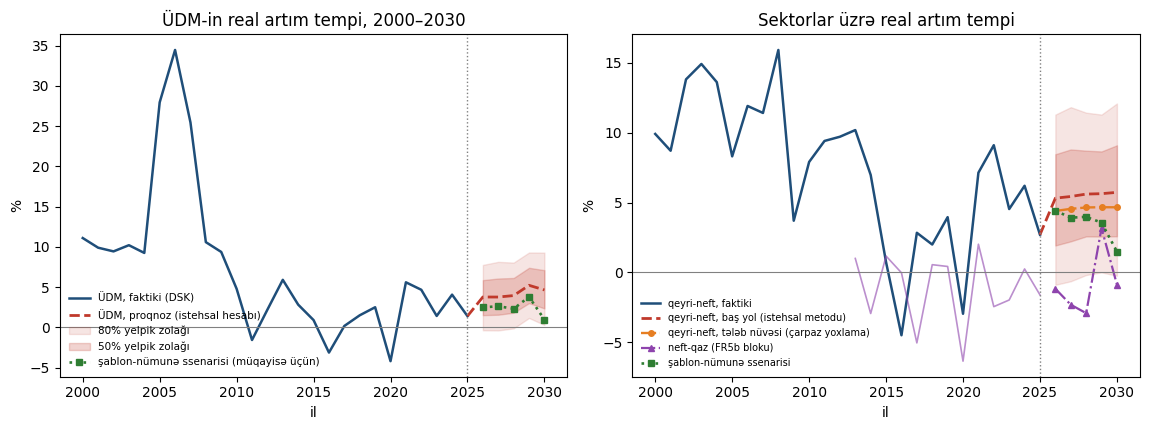

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
ax = axes[0]
h = gdp_g_pub.loc[2000:]
ax.plot(h.index, h.values, "-", color="#1f4e79", lw=1.8, label="ÜDM, faktiki (DSK)")
ax.plot([LA] + FY, [float(gdp_g_pub.loc[LA])] + list(gg_fc.values), "--", color="#c0392b", lw=2.0,
        label="ÜDM, proqnoz (istehsal hesabı)")
ax.fill_between(FY, bands_gg["lo80"], bands_gg["hi80"], color="#c0392b", alpha=0.13,
                label="80% yelpik zolağı")
ax.fill_between(FY, bands_gg["lo50"], bands_gg["hi50"], color="#c0392b", alpha=0.22,
                label="50% yelpik zolağı")
ax.plot(mb["gdp_realg"].index, mb["gdp_realg"].values, ":", color="#2e7d32", lw=1.9, marker="s", ms=4,
        label="şablon-nümunə ssenarisi (müqayisə üçün)")
ax.axhline(0, color="grey", lw=0.8); ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("ÜDM-in real artım tempi, 2000–2030"); ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(loc="lower left", frameon=False, fontsize=7.5)

ax = axes[1]
hn = S["y"].loc[2000:]
ax.plot(hn.index, hn.values, "-", color="#1f4e79", lw=1.8, label="qeyri-neft, faktiki")
ax.plot([LA] + FY, [float(hn.loc[LA])] + list(g_non_head.values), "--", color="#c0392b", lw=2.0,
        label="qeyri-neft, baş yol (istehsal metodu)")
ax.fill_between(FY, bands_head["lo80"], bands_head["hi80"], color="#c0392b", alpha=0.13)
ax.fill_between(FY, bands_head["lo50"], bands_head["hi50"], color="#c0392b", alpha=0.22)
ax.plot(FY, list(g_non_c.values), "-.", color="#e67e22", lw=1.7, marker="o", ms=4,
        label="qeyri-neft, tələb nüvəsi (çarpaz yoxlama)")
ax.plot(FY, [float(oil_g_fc.loc[y]) for y in FY], "-.", color="#8e44ad", lw=1.6, marker="^", ms=4,
        label="neft-qaz (FR5b bloku)")
ax.plot(oil_g.index, oil_g.values, "-", color="#8e44ad", lw=1.2, alpha=0.6)
ax.plot(mb["nonoil_realg"].index, mb["nonoil_realg"].values, ":", color="#2e7d32", lw=1.9,
        marker="s", ms=4, label="şablon-nümunə ssenarisi")
ax.axhline(0, color="grey", lw=0.8); ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("Sektorlar üzrə real artım tempi"); ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(loc="lower left", frameon=False, fontsize=7.0)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR01_artim.png"), dpi=140)
plt.show()

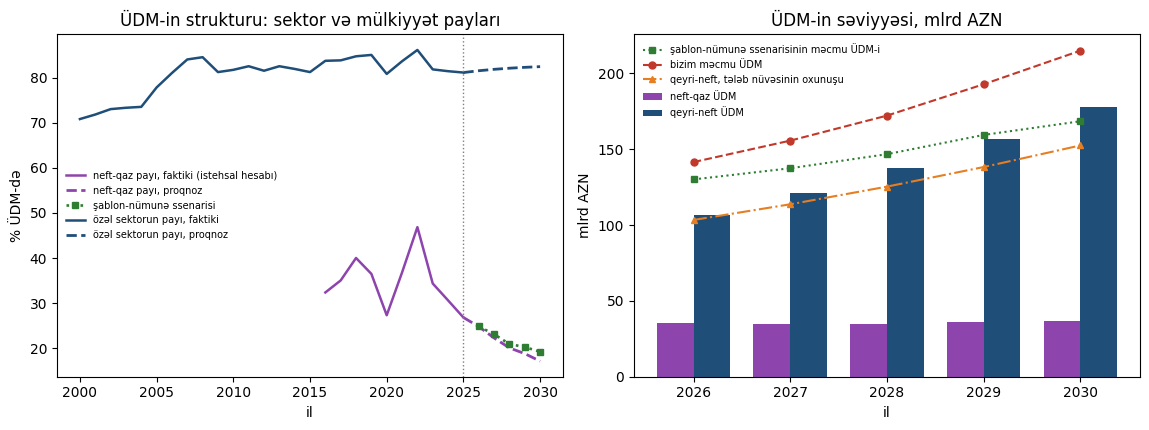

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
ax = axes[0]
sh_hist = sh_o.loc[:LA].dropna()
ax.plot(sh_hist.index, sh_hist.values, "-", color="#8e44ad", lw=1.8,
        label="neft-qaz payı, faktiki (istehsal hesabı)")
ax.plot([LA] + FY, [float(sh_hist.loc[LA])] + list(sh_o.loc[FY].values), "--", color="#8e44ad", lw=2.0,
        label="neft-qaz payı, proqnoz")
ax.plot(mb["oil_share"].index, mb["oil_share"].values, ":", color="#2e7d32", lw=1.9, marker="s", ms=4,
        label="şablon-nümunə ssenarisi")
ps_hist = psh.loc[2000:]
ax.plot(ps_hist.index, ps_hist.values, "-", color="#1f4e79", lw=1.8, label="özəl sektorun payı, faktiki")
ax.plot([LA] + FY, [float(psh.loc[LA])] + list(ps_fc.values), "--", color="#1f4e79", lw=2.0,
        label="özəl sektorun payı, proqnoz")
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("ÜDM-in strukturu: sektor və mülkiyyət payları")
ax.set_ylabel("% ÜDM-də"); ax.set_xlabel("il")
ax.legend(loc="center left", frameon=False, fontsize=7.0)

ax = axes[1]
xs = np.arange(len(FY)); w = 0.38
ax.bar(xs - w / 2, [O.loc[y] / 1000 for y in FY], width=w, color="#8e44ad", label="neft-qaz ÜDM")
ax.bar(xs + w / 2, [N.loc[y] / 1000 for y in FY], width=w, color="#1f4e79", label="qeyri-neft ÜDM")
ax.plot(xs, [mb["gdp_nom"].loc[y] / 1000 for y in FY], "s:", color="#2e7d32", ms=5,
        label="şablon-nümunə ssenarisinin məcmu ÜDM-i")
ax.plot(xs, [G.loc[y] / 1000 for y in FY], "o--", color="#c0392b", ms=5, label="bizim məcmu ÜDM")
ax.plot(xs, [N_dem.loc[y] / 1000 for y in FY], "^-.", color="#e67e22", ms=5,
        label="qeyri-neft, tələb nüvəsinin oxunuşu")
ax.set_xticks(xs); ax.set_xticklabels([str(y) for y in FY])
ax.set_title("ÜDM-in səviyyəsi, mlrd AZN"); ax.set_ylabel("mlrd AZN"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7.0)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR01_struktur.png"), dpi=140)
plt.show()

## 8. Nəticələrin ixracı

Dörd çıxış faylı yazılır: vahid fərziyyə dəsti (`data/assumptions.csv` — aşağı axın FR-lərinin
istifadə edəcəyi sürücü yolları), proqnoz və faktiki sıralar (`outputs/forecast_long.csv`), tənlik
kataloqu (`outputs/equations_catalog.csv`) və artıq yuxarıda yazılmış sınaq nəticələri. Sonda bütün
eyniliklər HƏR il üçün yoxlanılır.

In [40]:
NOTE_CORE = ("FR01 simultan nüvəsinin həlli (tələb-investisiya-istehlak-gəlir bloku), "
             "FR5 neft yolu, FR9 İQİ yolu və WEO tərəfdaş artımı ilə şərtləndirilmiş")
NOTE_HEAD = ("FR02-nin aşağıdan-yuxarı istehsal aqreqatı — 11 sahə əlavə dəyəri + qeyri-neft "
             "mədənçıxarma, miqyaslama YOXDUR (istehsal metoduna keçid); "
             + (NOTE_BU if "NOTE_BU" in globals() else "sınaq bu icrada hesablanmadı"))
rows = []
def _add(key, series, unit, note):
    for y in FY:
        rows.append({"assumption_key": key, "year": int(y), "value": round(float(series.loc[y]), 4),
                     "unit": unit, "note": note})

_add("gdp_realg", gg_fc, "%",
     "FR01: istehsal hesabının üç komponentinin (neft-qaz VA, qeyri-neft VA, xalis vergilər) "
     "gecikmiş nominal paylarla çəkili həcm artımı — eynilik")
_add("nonoil_realg", g_non_head, "%", NOTE_HEAD)
NOTE_BAND_H = ("80% yelpik zolağının {} sərhədi — FR02-nin aqreqat zolağı (sahə σ₁-lərinin tam "
               "korrelyasiya fərziyyəsi ilə çəkili cəmi); mərkəzi yol aşağıdan-yuxarı aqreqatdır")
_add("nonoil_realg_lo80", bands_head["lo80"], "%", NOTE_BAND_H.format("aşağı"))
_add("nonoil_realg_hi80", bands_head["hi80"], "%", NOTE_BAND_H.format("yuxarı"))
_add("gdp_defl", gd_fc, "%", "FR01: nominal və real artımdan eyniliklə")
_add("nonoil_defl", d_non_head, "%",
     "FR02: sahə deflyatorlarının çəkili nəticəsi — istehsal tərkibinin implisit deflyatoru")
_add("oil_defl", d_oil_c, "%", "FR01: FR05b-nin çəkili neft+qaz qiymət indeksinə bağlı deflyator "
                               "tənliyinin ansamblı (köhnə Brent spesifikasiyası da ansambldadır); "
                               "FR02 mədənçıxarmanın neft-qaz hissəsini bu açarla zəncirləyir")
# --- tələb tərəfinin oxunuşu: baş göstərici DEYİL, çarpaz yoxlama və ssenari mühərriki -----------
NOTE_DEM = ("FR01 tələb nüvəsinin oxunuşu — baş göstərici DEYİL (istehsal metoduna keçiddən sonra baş yol "
            "istehsal metodudur); istehsal metodu ilə fərq `gdp_nonoil_gap` sırasında nəşr olunur. "
            + NOTE_SKILL + "; " + NOTE_CORE)
_add("nonoil_realg_demand", g_non_c, "%", NOTE_DEM)
NOTE_BAND = (f"80% yelpik zolağının {{}} sərhədi — ŞƏRTSİZ (2016 daxil) ansambl RMSE-si "
             f"σ₁ = {float(bt16.ensemble_rmse):.2f} f.b. + parametr qeyri-müəyyənliyi (FR5 kalibrləmə "
             f"presedenti); tələb nüvəsinin oxunuşuna aiddir")
_add("nonoil_realg_demand_lo80", bands_non["lo80"], "%", NOTE_BAND.format("aşağı"))
_add("nonoil_realg_demand_hi80", bands_non["hi80"], "%", NOTE_BAND.format("yuxarı"))
_add("nonoil_defl_demand", d_non_c, "%",
     "FR01: İQİ-yə bağlı deflyator tənliyinin ansamblı (FR9 yolu ilə) — tələb tərəfinin oxunuşu")
_add("g_inv_core", core["g_inv"], "%", "FR01 nüvəsi: investisiyanın real artımı — FR6 bu yolu istifadə edir")
_add("g_cons_core", core["g_cons"], "%", "FR01 nüvəsi: son istehlakın real artımı — FR2/FR8 bu yolu istifadə edir")
_add("g_income_core", core["g_inc"], "%", "FR01 nüvəsi: əhalinin real gəlirlərinin artımı — FR8 bu yolu istifadə edir")
_add("partner_gdp_realg", partner_fc, "%", "ekzogen giriş — IMF WEO (external_block_annual.csv), paketdə modeli yoxdur")
_add("m2_real_g", DLRM2_PATH, "%",
     f"fərziyyə PROFİLİ (sabit fərziyyə əvəzinə profil yolu): real pul kütləsinin artımı 2025-in faktiki dəyərindən "
     f"lövbərə yığılır; {_m2_note}. Profil aralığı {float(DLRM2_PATH.min()):.2f}-"
     f"{float(DLRM2_PATH.max()):.2f} %, profilin ortası {DLRM2:.2f} % (v2-nin sabit fərziyyəsi "
     f"{DLRM2_ANCHOR:.2f} % idi). Həssaslıq: profil bütövlükdə ± 3 f.b. sürüşdürülür — tələb "
     f"nüvəsinin qeyri-neft yolu bu aralıqda ən çox {SENS_NON_WIDTH:.2f} f.b. dəyişir "
     f"(şok ansamblın M2-yə həssas BÜTÜN üzvlərinə ötürülür, çəki {_W_M2:.3f}), lakin "
     f"investisiya yolunun ({SENS_INV_LO:.2f} – {SENS_INV_HI:.2f} %) "
     f"İŞARƏSİ dəyişir (dönmə nöqtəsi {X_STAR:.2f} %; profilin öz aralığına görə: "
     f"{'daxilindədir' if float(DLRM2_PATH.min()) <= X_STAR <= float(DLRM2_PATH.max()) else 'xaricindədir'})")
_add("pop_avg", P.loc[FY], "min nəfər", "fərziyyə: son beş ilin orta artım tempi ilə uzadılıb")
assum = pd.DataFrame(rows)
outputs.write_assumptions(assum)
print(f"assumptions.csv: {len(assum)} sətir, {assum['assumption_key'].nunique()} açar yazıldı")
print(sorted(assum["assumption_key"].unique()))

assumptions.csv: 85 sətir, 17 açar yazıldı
['g_cons_core', 'g_income_core', 'g_inv_core', 'gdp_defl', 'gdp_realg', 'm2_real_g', 'nonoil_defl', 'nonoil_defl_demand', 'nonoil_realg', 'nonoil_realg_demand', 'nonoil_realg_demand_hi80', 'nonoil_realg_demand_lo80', 'nonoil_realg_hi80', 'nonoil_realg_lo80', 'oil_defl', 'partner_gdp_realg', 'pop_avg']


## 7.9 Dinamiklik göstəricisi — baş göstəricilər

Proqnozun canlılığı ölçülən kəmiyyətdir:
$\text{dinamiklik}(s)=\sigma(\text{proqnoz}_{2026-2030})\,/\,\sigma(\text{faktiki}_{2013-2025})$
(hər ikisi populyasiya standart kənarlaşmasıdır). Göstərici `validation_backtest.csv`-ə
`model = "DINAMIKLIK"` sətirləri ilə yazılır — `actual` sütununda σ(faktiki), `forecast`
sütununda σ(proqnoz), `rmse_h` sütununda göstəricinin özü, `rw_rmse_h` sütununda isə istinad
dəyəri 1,0 durur.

**Oxunuşu.** Şərti orta proqnoz tərifinə görə faktikidən az dəyişkəndir, ona görə 1-dən kiçik
dəyər qüsur deyil; sıfıra yaxın dəyər isə proqnozun praktik olaraq sabit olduğunu bildirir.
Göstərici DƏQİQLİK ölçüsü deyil — dəqiqlik etalona qarşı bacarıqla ölçülür və ayrıca nəşr olunur;
ikisi birlikdə oxunmalıdır, çünki dəyişkənliyi süni artırmaq dəqiqliyi pisləşdirir.

Neft-qaz sırasının göstəricisi yüksəkdir, çünki onun yolu FR05b-nin **hasilat profilindən** gəlir
və hasilat profili özü qeyri-hamar sıradır; qeyri-neft sıralarının göstəricisi aşağıdır, çünki
onları şərtləndirən girişlər (İQİ, tərəfdaş ölkələrin artımı, real pul kütləsi) hamar yollardır.


In [41]:
# Dinamiklik göstəricisi — baş göstəricilər. Pəncərə və σ tərifi bütün dəftərlərdə eynidir
# (`ek.sigma_ratio`), ona görə FR01, FR02 və digər blokların rəqəmləri birbaşa müqayisə oluna bilir.
dyn_fr1 = []


def _dyn(code, label, fc, hist, just="", dyn_class=""):
    # `dyn_class` — aşağı dəyişkənliyin MEXANİZM sinfi (`ek.DYN_CLASSES`): qeyd sütununda
    # əsaslandırma ilə birlikdə nəşr olunur (D2), aralığın özü isə nəşr olunmur.
    try:
        r = ek.sigma_ratio(pd.Series(fc).reindex(FY), pd.Series(hist),
                           series_code=code, label_az=label, justification=just,
                           dyn_class=dyn_class)
    except ValueError as e:
        print(f"  DİQQƏT: {code} — hesablanmadı ({e})")
        return
    dyn_fr1.append(r)


_dyn("gdp_realg", "ÜDM-in real artım tempi", gg_fc, data_layer.actuals("gdp_realg"),
     just="aqreqat üç komponentin çəkili cəmidir (neft-qaz bloku, qeyri-neft istehsal bloku, "
          "xalis vergilər); neft-qaz komponentinin HƏCM yolu Nazirliyin hasilat planından gəlir "
          "(FR05b, Bölmə 9 — inzibati, hamar yol) və onun ÜDM-dəki payı ~25 %-dir, ona görə "
          "aqreqatın dəyişkənliyinin böyük hissəsi həmin plana bağlıdır; qeyri-neft hissəsinin "
          "sahə-sahə səbəbləri FR02, Bölmə 7.8-dədir", dyn_class="ekzogen")
_dyn("gdp_defl", "ÜDM deflyatoru", gd_fc, data_layer.actuals("gdp_defl"),
     just="ÜDM deflyatoru iki blok deflyatorunun çəkili nəticəsidir: neft-qaz deflyatoru FR05b-nin "
          "çəkili neft+qaz qiymət indeksinə, qeyri-neft deflyatoru isə İQİ yoluna bağlıdır; hər iki "
          "giriş şərti orta yoldur (Brent FR05-in struktur tənliyindən, İQİ hədəfə yığılan ansambl), "
          "ona görə nəticənin dəyişkənliyi girişlərinkindən böyük ola bilməz; tarixi σ 13,3 f.b. "
          "isə 2015-2016 devalvasiyası və 2021-2022 qiymət epizodunu ehtiva edir",
     dyn_class="qiymet")
_dyn("nonoil_realg", "Qeyri-neft ÜDM-in real artımı (baş göstərici)", g_non_head,
     data_layer.actuals("nonoil_realg"),
     just="baş göstərici FR02-nin sahə tənliklərinin cəmidir; sahə sürücülərinin yolları hamar "
          "olduğu üçün aqreqatın dəyişkənliyi də məhduddur — sahə-sahə səbəb FR02, Bölmə 7.8-də",
     dyn_class="ekzogen")
_dyn("nonoil_defl", "Qeyri-neft ÜDM deflyatoru", d_non_head, data_layer.actuals("nonoil_defl"),
     just="deflyator yolu İQİ yolu ilə şərtlənir; İQİ-nin öz yolu hədəfə yığılan hamar sıradır",
     dyn_class="qiymet")
_dyn("oil_defl", "Neft-qaz sektorunun deflyatoru", d_oil_c, data_layer.actuals("oil_defl"),
     just="tarixi σ 34 f.b.-dir (2015-2016 və 2020 qiymət şokları); şərti orta proqnoz belə "
          "şokları ehtiva etmir, ona görə nisbət konstruksiya etibarilə kiçikdir",
     dyn_class="qiymet")
_dyn("nonoil_realg_demand", "Qeyri-neft ÜDM — tələb nüvəsinin oxunuşu", g_non_c,
     data_layer.actuals("nonoil_realg"),
     just="tələb nüvəsi üç aqreqat sürücü ilə şərtlənir (investisiya, istehlak, tərəfdaş artımı) "
          "və nüvə xətti olduğu üçün girişlərin hamarlığı çıxışa keçir", dyn_class="ekzogen")
_dyn("oil_realg", "Neft-qaz sektorunun real artımı", A["oil_realg"], data_layer.actuals("oil_realg"),
     just="yol FR05b-nin həcm × qiymət konstruksiyasından gəlir; həcm yolu Nazirliyin hasilat "
          "planıdır və plan illər üzrə əhəmiyyətli dəyişdiyi üçün göstərici daxili aralıqdadır",
     dyn_class="ekzogen")

dyn_fr1_table = pd.DataFrame([{
    "sıra": r.series_code, "göstərici": r.label_az[:42],
    "σ(faktiki) 2013-2025": round(r.sd_actual, 3),
    "σ(proqnoz) 2026-2030": round(r.sd_forecast, 3),
    "dinamiklik": round(r.ratio, 3), "sinif": r.dyn_class} for r in dyn_fr1])
outputs.write_backtest(ek.dynamics_rows(dyn_fr1))
_b = ek.assert_dynamics_band(dyn_fr1, strict=False)
print(f"Dinamiklik göstəricisi — {len(dyn_fr1)} baş göstərici yazıldı "
      f"(model = DINAMIKLIK); daxili qəbul yoxlaması: "
      f"{int(_b['aralıqda'].sum())}/{len(_b)} sıra aralıqdadır, qalanlarının səbəbi qeyddədir.")
dyn_fr1_table



Dinamiklik göstəricisi — 7 baş göstərici yazıldı (model = DINAMIKLIK); daxili qəbul yoxlaması: 1/7 sıra aralıqdadır, qalanlarının səbəbi qeyddədir.


,sıra,göstərici,σ(faktiki) 2013-2025,σ(proqnoz) 2026-2030,dinamiklik,sinif
0,gdp_realg,ÜDM-in real artım tempi,2.914,0.576,0.198,ekzogen
1,gdp_defl,ÜDM deflyatoru,13.337,0.342,0.026,qiymet
2,nonoil_realg,Qeyri-neft ÜDM-in real artımı (baş göstəri,4.161,0.149,0.036,ekzogen
3,nonoil_defl,Qeyri-neft ÜDM deflyatoru,3.054,0.210,0.069,qiymet
4,oil_defl,Neft-qaz sektorunun deflyatoru,35.234,0.431,0.012,qiymet
5,nonoil_realg_demand,Qeyri-neft ÜDM — tələb nüvəsinin oxunuşu,4.161,0.102,0.025,ekzogen
6,oil_realg,Neft-qaz sektorunun real artımı,2.424,2.124,0.876,ekzogen


In [42]:
NAMES = {
    "gdp_nom": ("ÜDM bazar qiymətləri ilə", "mln AZN"),
    "gdp_realg": ("ÜDM real artım tempi", "%"),
    "gdp_defl": ("ÜDM deflyatoru", "%"),
    "oil_nom": ("Neft-qaz sektoru ÜDM-i", "mln AZN"),
    "oil_realg": ("Neft-qaz sektorunun real artım tempi", "%"),
    "oil_defl": ("Neft-qaz sektorunun deflyatoru", "%"),
    "oil_share": ("Neft-qaz sektorunun ÜDM-də payı", "%"),
    "nonoil_nom": ("Qeyri neft-qaz sektoru ÜDM-i", "mln AZN"),
    "nonoil_realg": ("Qeyri neft-qaz sektorunun real artım tempi", "%"),
    "nonoil_defl": ("Qeyri neft-qaz sektorunun deflyatoru", "%"),
    "nonoil_share": ("Qeyri neft-qaz sektorunun ÜDM-də payı", "%"),
    "gdp_nonoil_demand": ("Qeyri-neft ÜDM — tələb nüvəsinin oxunuşu", "mln AZN"),
    "gdp_nonoil_gap_pct": ("Qeyri-neft ÜDM: istehsal metodu ilə tələb nüvəsinin fərqi, %", "%"),
    "private_share_gdp": ("Özəl sektorun ÜDM-də payı", "%"),
    "private_gdp_nom": ("Özəl sektorun ÜDM-i", "mln AZN"),
    "state_gdp_nom": ("Dövlət sektorunun ÜDM-i", "mln AZN"),
    "gdp_pc_azn": ("Adambaşına düşən ÜDM (manatla)", "AZN"),
    "gdp_pc_usd": ("Adambaşına düşən ÜDM (ABŞ dolları ilə)", "USD"),
    "gdp_pc_realg": ("Adambaşına düşən ÜDM-in real artım tempi", "%"),
    "pop_avg": ("Əhalinin orta illik sayı", "min nəfər"),
}
# §0 qaydası: 2024-də kəsilən sıralar sahibi olan FR-də arifmetik yolla tamamlanır
pc_g_hist = data_layer.actuals("gdp_pc_realg")
pc_g_2025 = (1 + float(gdp_g_pub.loc[LA]) / 100) / (1 + float(pop.pct_change().loc[LA])) * 100 - 100
pc_g_hist = pd.concat([pc_g_hist, pd.Series({LA: pc_g_2025})]).sort_index()
# DATA-GAP: dollar ifadəsi şablonda #REF!-dir → manatla göstərici və məzənnədən hesablanır
pc_usd_hist = (data_layer.actuals("gdp_pc_azn") / fx_avg).dropna()
pc_usd_fc = gdp_pc.loc[FY] / config.USD_AZN_PEG
BANDS = {"nonoil_realg": bands_head, "gdp_realg": bands_gg, "oil_defl": bands_od,
         "oil_realg": bands_oil}
if bands_non_lvl is not None:
    BANDS["nonoil_nom"] = bands_non_lvl
if bands_gdp_lvl is not None:
    BANDS["gdp_nom"] = bands_gdp_lvl
ACTUALS = {c: data_layer.actuals(c) for c in
           ["gdp_nom", "gdp_realg", "gdp_defl", "oil_realg", "nonoil_realg", "nonoil_defl",
            "private_share_gdp", "gdp_pc_azn", "pop_avg"]}
# Neft/qeyri-neft bölgüsünün FAKTİKİ sıraları da istehsal hesabının tərifi ilə verilir (Bölmə 2.0):
# qeyri-neft mədənçıxarma qeyri-neft blokundadır; sıra 2016-cı ildən başlayır (DATA-GAP).
_o_h, _n_h = O_all.loc[:LA].dropna(), N_all.loc[:LA].dropna()
ACTUALS["oil_nom"] = _o_h
ACTUALS["nonoil_nom"] = _n_h
ACTUALS["oil_share"] = sh_o.loc[:LA].dropna()
ACTUALS["nonoil_share"] = sh_n.loc[:LA].dropna()
ACTUALS["oil_defl"] = d_oil.loc[2013:]
ACTUALS["private_gdp_nom"] = priv_h
ACTUALS["state_gdp_nom"] = state_h
ACTUALS["gdp_pc_realg"] = pc_g_hist
ACTUALS["gdp_pc_usd"] = pc_usd_hist
FCAST = {"gdp_nom": G.loc[FY], "gdp_realg": gg_fc, "gdp_defl": gd_fc,
         "oil_nom": O.loc[FY], "oil_realg": oil_g_fc, "oil_defl": d_oil_c, "oil_share": sh_o.loc[FY],
         "nonoil_nom": N.loc[FY], "nonoil_realg": g_non_head, "nonoil_defl": d_non_head,
         "nonoil_share": sh_n.loc[FY],
         "gdp_nonoil_demand": N_dem.loc[FY], "gdp_nonoil_gap_pct": GAP_NON_PCT,
         "private_share_gdp": ps_fc,
         "private_gdp_nom": priv, "state_gdp_nom": state,
         "gdp_pc_azn": gdp_pc.loc[FY], "gdp_pc_usd": pc_usd_fc, "gdp_pc_realg": gdp_pc_g,
         "pop_avg": P.loc[FY]}

fl = []
def _row(code, y, kind, src, v, b=None):
    nm, un = NAMES[code]
    r = {"fr": "FR1", "series_code": code, "series_name_az": nm, "unit": un, "year": int(y),
         "kind": kind, "source": src, "value": round(float(v), 6),
         "lo80": None, "hi80": None, "lo50": None, "hi50": None}
    if b is not None and y in b.index:
        for c in ("lo80", "hi80", "lo50", "hi50"):
            r[c] = round(float(b.loc[y, c]), 4)
    return r

for code, s in ACTUALS.items():
    for y, v in s.dropna().items():
        fl.append(_row(code, y, "actual", "ours", v))
for code, s in FCAST.items():
    for y, v in s.items():
        fl.append(_row(code, y, "forecast", "ours", v, BANDS.get(code)))
for code in NAMES:                       # şablon-nümunə ssenarisi — overlay
    s = data_layer.ministry_baseline(code)
    for y, v in s.items():
        fl.append(_row(code, y, "forecast", "template_sample", v))
fl = pd.DataFrame(fl)

# --- XƏRC TƏRƏFİ (bu buraxılış, xərc tərəfinin müstəqil oxunuşu): milli hesablar əsaslı dövlət və ev təsərrüfatı
# son istehlakı. Əvvəllər dövlət ayağı DATA-GAP idi; indi DSK-nın 27-ci cədvəlindən gəlir.
_EXP_NAMES = {
    "gov_cons_total": ("Dövlət idarələrinin son istehlak xərcləri (P.3 + P.4)", "mln AZN"),
    "gov_cons_indiv": ("Dövlət idarələrinin fərdi xidmət xərcləri (P.3)", "mln AZN"),
    "gov_cons_collect": ("Dövlət idarələrinin kollektiv xidmət xərcləri (P.4)", "mln AZN"),
    "hh_cons_actual": ("Ev təsərrüfatlarının faktiki son istehlak xərcləri (P.4)", "mln AZN"),
    "gov_cons_realg": ("Dövlət son istehlakının real artım tempi", "%"),
}
exp_rows = []
for _c in ("gov_cons_total", "gov_cons_indiv", "gov_cons_collect", "hh_cons_actual"):
    for _y, _v in data_layer.actuals(_c).dropna().items():
        exp_rows.append({"fr": "FR1", "series_code": _c, "series_name_az": _EXP_NAMES[_c][0],
                         "unit": _EXP_NAMES[_c][1], "year": int(_y), "kind": "actual",
                         "source": "ours", "value": round(float(_v), 6),
                         "lo80": None, "hi80": None, "lo50": None, "hi50": None})
for _y, _v in S["g_gov"].dropna().items():
    exp_rows.append({"fr": "FR1", "series_code": "gov_cons_realg",
                     "series_name_az": _EXP_NAMES["gov_cons_realg"][0], "unit": "%",
                     "year": int(_y), "kind": "actual", "source": "ours",
                     "value": round(float(_v), 6),
                     "lo80": None, "hi80": None, "lo50": None, "hi50": None})
for _y in FY:
    exp_rows.append({"fr": "FR1", "series_code": "gov_cons_total",
                     "series_name_az": _EXP_NAMES["gov_cons_total"][0], "unit": "mln AZN",
                     "year": int(_y), "kind": "forecast", "source": "ours",
                     "value": round(float(gov_cons_fc.loc[_y]), 6),
                     "lo80": None, "hi80": None, "lo50": None, "hi50": None})
    exp_rows.append({"fr": "FR1", "series_code": "gov_cons_realg",
                     "series_name_az": _EXP_NAMES["gov_cons_realg"][0], "unit": "%",
                     "year": int(_y), "kind": "forecast", "source": "ours",
                     "value": round(float(gov_g_fc.loc[_y]), 6),
                     "lo80": None, "hi80": None, "lo50": None, "hi50": None})
exp = pd.DataFrame(exp_rows).astype({"lo80": "float64", "hi80": "float64",
                                     "lo50": "float64", "hi50": "float64"})
fl = pd.concat([fl, exp], ignore_index=True)

# --- BVF ETALON SƏTİRLƏRİ (R23) ------------------------------------------------------------
# `source=imf_reference`. Sətirlər BU partiya ilə BİR çağırışda yazılır: `write_forecast_long`
# əhatəni `fr` sütunu üzrə yerinə-yazdığı üçün ayrıca çağırış FR1-in qalan sətirlərini silərdi.
imf = data_layer.reference_rows(FY, {"gdp_realg": "FR1", "nonoil_realg": "FR1"})
fl = pd.concat([fl, imf], ignore_index=True)
print(f"BVF etalonu: {len(imf)} sətir ({imf['series_code'].nunique()} sıra), "
      f"buraxılış — {data_layer.REFERENCE_VINTAGE_NOTE}")
outputs.write_forecast_long(fl)
print(f"xərc tərəfi: {exp['series_code'].nunique()} sıra, {len(exp)} sətir "
      f"({int(exp['year'].min())}-{int(exp['year'].max())}) — dövlət son istehlakı "
      "DATA-GAP-dan çıxarıldı")

# lüğətə yalnız bu dəftərin yaratdığı törəmə sıralar əlavə olunur
outputs.write_series_dictionary(pd.DataFrame([
    {"series_code": "private_gdp_nom", "name_az": NAMES["private_gdp_nom"][0],
     "name_en": "Private sector GDP", "unit": "mln AZN", "fr": "FR1",
     "statutory_sheet_ref": "8 vərəq, 2.4.1.1.", "price_basis": "cari"},
    {"series_code": "state_gdp_nom", "name_az": NAMES["state_gdp_nom"][0],
     "name_en": "State sector GDP", "unit": "mln AZN", "fr": "FR1",
     "statutory_sheet_ref": "8 vərəq, 2.4.1.1.", "price_basis": "cari"},
    {"series_code": "gdp_pc_usd", "name_az": NAMES["gdp_pc_usd"][0],
     "name_en": "GDP per capita, USD", "unit": "USD", "fr": "FR1",
     "statutory_sheet_ref": "8 vərəq, 2.4.1.1.", "price_basis": "cari"},
    {"series_code": "gdp_nonoil_demand", "name_az": NAMES["gdp_nonoil_demand"][0],
     "name_en": "Non-oil GDP, demand-core reading", "unit": "mln AZN", "fr": "FR1",
     "statutory_sheet_ref": "FR01 simultan nüvəsi; istehsal metodu ilə fərq: FR2 `gdp_nonoil_gap`",
     "price_basis": "cari"},
    # Tələb nüvəsinin ARTIM oxunuşu: `forecast_long.csv`-ə səviyyə kimi (`gdp_nonoil_demand`)
    # düşür, temp isə fərziyyə açarı və dinamiklik sırası kimi mövcuddur — lüğətdə də olmalıdır ki,
    # D2 əsaslandırması ona bağlana bilsin.
    {"series_code": "nonoil_realg_demand",
     "name_az": "Qeyri neft-qaz ÜDM-in real artımı — tələb nüvəsinin oxunuşu",
     "name_en": "Non-oil GDP real growth, demand-core reading", "unit": "%", "fr": "FR1",
     "statutory_sheet_ref": ("FR01 simultan nüvəsi (DİAQNOSTİK — baş göstərici DEYİL, istehsal metoduna "
                             "keçiddən sonra baş göstərici FR02-nin aqreqatıdır); "
                             "fərziyyə açarı: nonoil_realg_demand"),
     "price_basis": "indeks"},
    {"series_code": "gov_cons_total",
     "name_az": "Dövlət idarələrinin son istehlak xərcləri (P.3 + P.4)",
     "name_en": "Government final consumption expenditure (P.3 + P.4)", "unit": "mln AZN",
     "fr": "FR1", "price_basis": "cari",
     "statutory_sheet_ref": ("DSK cədvəl 27 (`027en`), sətir 10 + sətir 12, 1993–2025 — milli "
                             "hesablar əsaslı dövlət son istehlakı (xərc tərəfinin müstəqil oxunuşu); iş kitabının "
                             "`final_consumption` sırası bu ayağı DAŞIMIR")},
    {"series_code": "gov_cons_indiv",
     "name_az": "Dövlət idarələrinin fərdi xidmət xərcləri (P.3)",
     "name_en": "Government expenditure on individual services (P.3)", "unit": "mln AZN",
     "fr": "FR1", "price_basis": "cari",
     "statutory_sheet_ref": "DSK cədvəl 27 (`027en`), sətir 10 (P.3), 1993–2025"},
    {"series_code": "gov_cons_collect",
     "name_az": "Dövlət idarələrinin kollektiv xidmət xərcləri (P.4)",
     "name_en": "Government actual final consumption, collective services (P.4)",
     "unit": "mln AZN", "fr": "FR1", "price_basis": "cari",
     "statutory_sheet_ref": "DSK cədvəl 27 (`027en`), sətir 12 (P.4), 1993–2025"},
    {"series_code": "hh_cons_actual",
     "name_az": "Ev təsərrüfatlarının faktiki son istehlak xərcləri (P.4)",
     "name_en": "Actual final consumption expenditure of households (P.4)", "unit": "mln AZN",
     "fr": "FR1", "price_basis": "cari",
     "statutory_sheet_ref": ("DSK cədvəl 27 (`027en`), sətir 7 (P.4), 1993–2025 — iş kitabının "
                             "`final_consumption` sırasından FƏRQLİ anlayış, ona görə ayrıca kod")},
    {"series_code": "gov_cons_realg",
     "name_az": "Dövlət son istehlakının real artım tempi",
     "name_en": "Government final consumption, real growth", "unit": "%", "fr": "FR1",
     "statutory_sheet_ref": ("DSK cədvəl 27 (`027en`), P.3 + P.4, 1993–2025; İQİ ilə "
                             "deflyasiya edilib. FR01 tələb tənliyində ayrıca sürücü kimi "
                             "sınaqdan keçirilir"),
     "price_basis": "indeks"},
    {"series_code": "gdp_nonoil_gap_pct", "name_az": NAMES["gdp_nonoil_gap_pct"][0],
     "name_en": "Non-oil GDP: production minus demand reading, % of production reading",
     "unit": "%", "fr": "FR1",
     "statutory_sheet_ref": "İki oxunuş arasındakı fərq miqyaslanmır, nəşr olunur; səviyyə sırası: FR2 `gdp_nonoil_gap`",
     "price_basis": "indeks"},
]))
print(f"forecast_long.csv: {len(fl)} sətir yazıldı — "
      f"{fl['series_code'].nunique()} sıra, mənbələr: {sorted(fl['source'].unique())}")
fl.head(4)

# D2 — ƏSASLANDIRMANIN NƏŞRİ (`outputs.publish_dynamics_notes`, bütün dəftərlərdə eyni funksiya).
# Aralığın özü nəşr olunmur; göstəricinin dəyəri və SƏBƏBİ seriya lüğətinin qeyd sütununa düşür.
# Çağırış lüğət yazıldıqdan SONRA olmalıdır: funksiya mövcud sətrin qeydinə əlavə edir.
outputs.publish_dynamics_notes(dyn_fr1)


BVF etalonu: 10 sətir (2 sıra), buraxılış — BVF Maddə IV 26/112, aprel 2026 vintajı
xərc tərəfi: 5 sıra, 168 sətir (1993-2030) — dövlət son istehlakı DATA-GAP-dan çıxarıldı
forecast_long.csv: 653 sətir yazıldı — 25 sıra, mənbələr: ['imf_reference', 'ours', 'template_sample']
D2: 7 sıra üçün dinamiklik əsaslandırması seriya lüğətinə yazıldı


,series_code,name_az,name_en,unit,fr,statutory_sheet_ref,price_basis
0,agri_export_russia_share,Kənd təsərrüfatı ixracında top-1 ölkənin (Rusi...,Kənd təsərrüfatı ixracında top-1 ölkənin (Rusi...,%,FR11,Ticarət (əsas iş kitabı),indeks
1,bop_total_balance,Tədiyə balansının ümumi balansı (BPM6 eyniliyi...,"BoP total balance (identity, zero by construct...",mln USD,FR12,"8 vərəq, 2.4.1.13.-14.",cari
2,brent_breakeven_ca0,Cari hesabın sıfırlandığı Brent qiyməti (break...,Break-even Brent price for CA = 0,USD/barel,FR12,"8 vərəq, 2.4.1.13.-14.",cari
3,brent_usd,Neftin dünya bazarında qiyməti (Brent),World oil price (Brent),USD/barel,FR5,"8 vərəq, 2.4.1.5.-7.",cari
4,budget_balance,Dövlət büdcəsinin kəsiri/profisiti,State budget balance,mln AZN,FR6,"Fiskal sektor, sətir 21; FAKTİKİ sıra — proqno...",cari
...,...,...,...,...,...,...,...
676,wage_ssc_water,Su təchizatı; tullantıların təmizlənməsi və em...,Water supply; waste treatment and disposal — a...,AZN,FR8,"DSK cədvəl 4.5–4.8 (`004_5-8en.xls`, `Dynamics...",cari
677,wage_ssc_water_nonstate,Su təchizatı; tullantıların təmizlənməsi və em...,Water supply; waste treatment and disposal — a...,AZN,FR8,"DSK cədvəl 4.5–4.8 (`004_5-8en.xls`, `Dynamics...",cari
678,wage_ssc_water_state,Su təchizatı; tullantıların təmizlənməsi və em...,Water supply; waste treatment and disposal — a...,AZN,FR8,"DSK cədvəl 4.5–4.8 (`004_5-8en.xls`, `Dynamics...",cari
679,wage_state,Dövlət sektorunda orta aylıq əmək haqqı,"Average wage, state sector",AZN,FR8,Sosial sektor,cari


In [43]:
cat_rows = pd.DataFrame([
    res_od.catalog_row(
        eq_name="FR1_neft_deflyatoru",
        description=("STRUKTUR: neft-qaz deflyatoru — ixrac dəyəri ilə çəkilənmiş neft+qaz qiymət "
                     "indeksi (FR05b) və məzənnə; süni dəyişən tələb olunmur"),
        lhs="oil_defl", series_code="oil_defl", fr="FR1", workbook=WB, sheet="Real sektor",
        rhs="oilgas_pw_g + dlfx"),
    res_od22.catalog_row(
        eq_name="FR1_neft_deflyatoru_d22",
        description=("ROBUSTLİK: eyni tənlik + 2022 süni dəyişəni — əmsal 49,05-dən 8,09-a enir və "
                     "5 % səviyyəsində əhəmiyyətini itirir (t = 1,68, p = 0,094); "
                     "çəkili indeksin qəbul testi"),
        lhs="oil_defl", series_code="oil_defl", fr="FR1", workbook=WB, sheet="Real sektor",
        rhs="oilgas_pw_g + dlfx + d22"),
    res_odb.catalog_row(
        eq_name="FR1_neft_deflyatoru_brent",
        description=("MÜQAYİSƏ: əvvəlki buraxılışın spesifikasiyası — yalnız Brent və məzənnə; "
                     "süni dəyişənsiz düzəldilmiş R² 0,7917 (çəkili indeksin eyni "
                     "variantı 0,9247 verir)"),
        lhs="oil_defl", series_code="oil_defl", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_odb22.catalog_row(
        eq_name="FR1_neft_deflyatoru_brent_d22",
        description=("MÜQAYİSƏ: əvvəlki buraxılışın işlək variantı — Brent + 2022 süni dəyişəni; "
                     "izahedici gücün böyük hissəsi bir ilə aid süni dəyişəndən gəlirdi"),
        lhs="oil_defl", series_code="oil_defl", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_ndp.catalog_row(
        eq_name="FR1_qeyri_neft_deflyatoru",
        description=("STRUKTUR: qeyri-neft deflyatoru ~ İQİ, 2017 sonrası ötürülmə fərqi ilə "
                     "(qarşılıqlı hədd -0,465, t = -3,05)"),
        lhs="nonoil_defl", series_code="nonoil_defl", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_nd.catalog_row(
        eq_name="FR1_qeyri_neft_deflyatoru_sade",
        description="ROBUSTLİK: eyni tənlik rejim fərqi olmadan — İQİ əmsalı 1,103",
        lhs="nonoil_defl", series_code="nonoil_defl", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_non.catalog_row(
        eq_name="FR1_nuve_teleb",
        description=("STRUKTUR (i): qeyri-neft TƏLƏB tənliyi — investisiya, son istehlak, tərəfdaş "
                     "artımı, devalvasiya və 2017 sonrası rejim süni dəyişənləri. istehsal metoduna keçiddən "
                     "sonra baş göstərici DEYİL: xərc tərəfinin müstəqil oxunuşu və ssenari "
                     "mühərriki; istehsal metodu ilə fərq `gdp_nonoil_gap` sırasında nəşr olunur"),
        lhs="nonoil_realg_demand", series_code="nonoil_realg_demand", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_non_nd.catalog_row(
        eq_name="FR1_nuve_teleb_dummisiz",
        description=("ROBUSTLİK (i): eyni tələb tənliyi süni dəyişənlərsiz — sabit hədd artım dövrünün "
                     "izini daşıyır və proqnozu yuxarı çəkir; alternativ aqreqat kimi saxlanılır"),
        lhs="nonoil_realg_demand", series_code="nonoil_realg_demand", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_non_d20.catalog_row(
        eq_name="FR1_nuve_teleb_pandemiya",
        description=("DİAQNOSTİK (i): pandemiya süni dəyişəni əlavə olunmuş — əmsal sıfırdan fərqli "
                     "deyil, spesifikasiyaya daxil edilmir"),
        lhs="nonoil_realg_demand", series_code="nonoil_realg_demand", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_inv.catalog_row(
        eq_name="FR1_nuve_investisiya",
        description=("STRUKTUR (ii): investisiyanın real artımı — real pul kütləsinin cari və "
                     "gecikmiş artımı, 2015-16 ölçmə sınığı süni dəyişəni"),
        lhs="inv_total_g", series_code="inv_total_g", fr="FR1", workbook=WB, sheet="Monetar sektoru"),
    res_inv_nd.catalog_row(
        eq_name="FR1_nuve_investisiya_dummisiz",
        description=("ROBUSTLİK (ii): eyni kanal süni dəyişənsiz və gecikməsiz — əmsal 0,292; "
                     "2015-16 çıxarıldıqda 0,563-ə qalxır"),
        lhs="inv_total_g", series_code="inv_total_g", fr="FR1", workbook=WB, sheet="Monetar sektoru"),
    res_cons_nom.catalog_row(
        eq_name="FR1_nuve_istehlak_nominal",
        description=("ROBUSTLİK (iii): eyni nümunə, nominal templər və İQİ ayrıca reqressor — "
                     "ortaq deflyator qərəzinin sınağı; MPC praktik olaraq dəyişmir, yəni "
                     "qərəz məlumatda görünmür (Bölmə 5.3 və Bölmə 9)"),
        lhs="final_consumption", series_code="final_consumption", fr="FR1", workbook=WB,
        sheet="macro_annual.csv", rhs="income_nom + cpi_infl"),
    res_cons.catalog_row(
        eq_name="FR1_nuve_istehlak",
        description="STRUKTUR (iii): son istehlakın real gəlirdən keçid əmsalı (MPC) = 0,667",
        lhs="final_consumption", series_code="final_consumption", fr="FR1", workbook=WB,
        sheet="macro_annual.csv"),
    res_inc.catalog_row(
        eq_name="FR1_nuve_gelir",
        description="STRUKTUR (iv): əhalinin real gəlirləri qeyri-neft artımı ilə birə-bir hərəkət edir",
        lhs="income_realg", series_code="income_realg", fr="FR1", workbook=WB, sheet="Real sektor"),
    res_ps.catalog_row(
        eq_name="FR1_ozel_pay_ar1",
        description=("STRUKTUR: özəl sektorun payı, AR(1) orta qiymətə qayıdış — uzunmüddətli pay "
                     "82,96 %, qayıdış sürəti qiymətləndirilib"),
        lhs="private_share_gdp", series_code="private_share_gdp", fr="FR1", workbook=WB,
        sheet="Real sektor"),
])
# İstehsal metoduna keçid: baş göstəricinin qeyri-neft yolu artıq TƏNLİK deyil, AQREQASİYA nəticəsidir — sahə
# tənlikləri FR02-nin kataloq sətirlərindədir. Buradakı üç sətir tələb tərəfinin oxunuşunu
# (alternativ aqreqat) sənədləşdirir və Geriyə Sınaq səhifəsində onun bacarıq rəqəmini daşıyır.
outputs.write_equations_catalog(cat_rows)
cat_rows[["eq_name", "lhs", "rhs", "sample_start", "sample_end", "adj_r2", "se_regression"]]

,eq_name,lhs,rhs,sample_start,sample_end,adj_r2,se_regression
0,FR1_neft_deflyatoru,oil_defl,oilgas_pw_g + dlfx,2001,2025,0.9247,7.7537
1,FR1_neft_deflyatoru_d22,oil_defl,oilgas_pw_g + dlfx + d22,2001,2025,0.9239,7.7965
2,FR1_neft_deflyatoru_brent,oil_defl,dlb + dlfx,2001,2025,0.7917,12.8984
3,FR1_neft_deflyatoru_brent_d22,oil_defl,dlb + dlfx + d22,2001,2025,0.9117,8.3971
4,FR1_qeyri_neft_deflyatoru,nonoil_defl,cpi + cpi_post,2001,2025,0.7868,3.1759
5,FR1_qeyri_neft_deflyatoru_sade,nonoil_defl,cpi,2001,2025,0.7233,3.6184
6,FR1_nuve_teleb,nonoil_realg_demand,g_inv + g_cons + partner + d15 + dpost,2001,2025,0.8728,1.8779
7,FR1_nuve_teleb_dummisiz,nonoil_realg_demand,g_inv + g_cons + partner,2001,2025,0.7409,2.6797
8,FR1_nuve_teleb_pandemiya,nonoil_realg_demand,g_inv + g_cons + partner + d15 + dpost + d20,2001,2025,0.8695,1.9021
9,FR1_nuve_investisiya,inv_total_g,dlrm2 + dlrm2_l1 + d15,2008,2025,0.5887,9.6636


In [44]:
v = validate.Verifier("FR01 — ÜDM baş göstəricisi (aşağıdan-yuxarı) və tələb nüvəsi")

_YRS = [LA] + FY                     # eyniliklər 2025 bazası ilə birlikdə yoxlanılır

# 1. əsas eynilik: ÜDM = neft-qaz + qeyri neft-qaz, HƏR il
v.identity("ÜDM = neft-qaz + qeyri neft-qaz (2025-2030)", G.loc[_YRS], (O + N).loc[_YRS],
           tol=1e-7, rel_tol=1e-12)

# 2. paylar cəmi 100 %
v.identity("neft payı + qeyri-neft payı = 100", (sh_o + sh_n).loc[FY],
           pd.Series({y: 100.0 for y in FY}), tol=1e-9)

# 3. İSTEHSAL METODUNA KEÇİD: baş göstərici FR02-nin aşağıdan-yuxarı hesabı ilə HƏR il üst-üstə düşür.
#    Bu, çevrilmənin özünün yoxlanışıdır: miqyaslama, düzəliş və ya ortalama yoxdur.
if INVERSION:
    # DÖZÜM QEYDİ: hər iki tərəf `forecast_long.csv`-dən oxunur və orada dəyərlər ÜÇ onluq
    # işarə ilə (0,001 mln AZN = 1 manat) yazılır; sol tərəf iki belə komponentin cəmidir, ona
    # görə eynilik ən çox 2 × 0,0005 qədər fərqlənə bilər. Dözüm məhz nəşr addımına bağlanır —
    # bu, eyniliyin zəiflədilməsi deyil, onun NƏŞR OLUNAN dəqiqlikdə yoxlanılmasıdır.
    v.identity("ÜDM = FR02 istehsal metodu (`gdp_prod`), hər il",
               G.loc[_YRS], PROD["gdp_prod"].reindex(_YRS), tol=5e-3, rel_tol=1e-12)
    v.identity("qeyri-neft ÜDM = FR02 `gdp_nonoil_prod`, hər il",
               N.loc[_YRS], PROD["gdp_nonoil_prod"].reindex(_YRS), tol=1e-6, rel_tol=1e-12)
    v.identity("neft-qaz ÜDM = FR02 `gdp_oilgas_prod`, hər il",
               O.loc[_YRS], PROD["gdp_oilgas_prod"].reindex(_YRS), tol=1e-6, rel_tol=1e-12)
    # A4: hər blok bazar qiymətlərində = əlavə dəyər + öz xalis vergiləri. Dözüm 0,01 mln AZN —
    # `forecast_long.csv` səviyyələri ÜÇ onluq işarə ilə saxlanılır, ona görə iki-üç komponentin
    # cəmində qalıq sıfır ola bilmir (FR03 eyni səbəbdən 0,1 dözümü işlədir). Balanslaşdırma YOXDUR.
    v.identity("qeyri-neft ÜDM = qeyri-neft əlavə dəyəri + qeyri-neft xalis vergiləri",
               N.loc[_YRS], (PROD["va_nonoil_prod"] + PROD["net_taxes_nonoil"]).reindex(_YRS),
               tol=0.01, rel_tol=1e-7)
    v.identity("neft-qaz ÜDM = neft-qaz əlavə dəyəri + neft xalis vergiləri",
               O.loc[_YRS], (PROD["va_mining_oilgas"] + PROD["net_taxes_oil"]).reindex(_YRS),
               tol=0.01, rel_tol=1e-7)
    v.identity("ÜDM = üç komponentin cəmi (neft-qaz VA + qeyri-neft VA + xalis vergilər)",
               G.loc[_YRS], (VAO + VAN + NTT).reindex(_YRS), tol=0.01, rel_tol=1e-7)

# 4. blok səviyyələri öz implisit deflyatorları ilə zəncirlənir
# ETİKET QEYDİ (4-9): aşağıdakı yoxlamalar seriyanı ONU YARADAN ifadə ilə tutuşdurur, yəni
# ARİFMETİK YENİDƏN TÖRƏTMƏDİR — kod sürüşməsini tutur, spesifikasiya səhvini tutmur.
# Müstəqil yoxlama yalnız 11-ci bənddir (`v.recompute`, nüvənin əl ilə matris həlli).
for nm, lv, gr, df in [("neft-qaz", O, oil_g_fc, d_oil_mp), ("qeyri-neft", N, g_non_head, d_non_mp)]:
    v.identity(f"{nm} nominal zənciri: V(t) = V(t-1)(1+g)(1+d_implisit) [arifmetik yenidən törətmə]",
               lv.loc[FY],
               pd.Series({y: lv.loc[y - 1] * (1 + float(gr.loc[y]) / 100) * (1 + float(df.loc[y]) / 100)
                          for y in FY}), tol=1e-6, rel_tol=1e-12)

# 5. məcmu deflyator eyniliyi: nominal artım = (1+g)(1+d)
v.identity("nominal artım = (1 + real artım)(1 + deflyator) [arifmetik yenidən törətmə]",
           pd.Series({y: G.loc[y] / G.loc[y - 1] for y in FY}),
           pd.Series({y: (1 + gg_fc.loc[y] / 100) * (1 + gd_fc.loc[y] / 100) for y in FY}), tol=1e-9)

# 6. məcmu real artım istehsal hesabının ÜÇ komponentinin çəkili cəmidir
v.identity("ÜDM real artımı = çəkili həcm artımı (VA_neft + VA_qeyri-neft + xalis vergilər) [arifmetik yenidən törətmə]", gg_fc,
           pd.Series({y: (float(VAO.loc[y - 1]) * float(oil_g_fc.loc[y])
                          + float(VAN.loc[y - 1]) * float(g_non_head.loc[y])
                          + float(NTT.loc[y - 1]) * float(nt_g_fc.loc[y])) / float(G.loc[y - 1])
                      for y in FY}), tol=1e-9)

# 7. mülkiyyət bölgüsü ÜDM-ə qapanır
v.identity("özəl + dövlət = ÜDM", (priv + state), G.loc[FY], tol=1e-7, rel_tol=1e-12)

# 8. adambaşına göstərici eyniliyi
v.identity("adambaşına ÜDM = ÜDM / əhali [arifmetik yenidən törətmə]", gdp_pc.loc[FY],
           pd.Series({y: G.loc[y] / P.loc[y] * 1000.0 for y in FY}), tol=1e-9)

# 9. İKİ OXUNUŞUN FƏRQİ — nəşr olunan sıra öz təriflərinə uyğundur (düzəliş yoxdur)
v.identity("fərq = istehsal metodu − tələb nüvəsi [arifmetik yenidən törətmə]", GAP_NON,
           (N.loc[FY] - N_dem.loc[FY]), tol=1e-9)
v.identity("fərq, % = fərq / qeyri-neft ÜDM × 100 [arifmetik yenidən törətmə]", GAP_NON_PCT,
           (GAP_NON / N.loc[FY] * 100), tol=1e-9)
# çarpaz yoxlama: FR02-nin nəşr etdiyi `gdp_nonoil_gap` eyni kəmiyyətdir. Dözüm 1 mln AZN —
# FR02 nüvənin templərini `assumptions.csv`-dən DÖRD onluq işarə ilə oxuyur, burada isə yaddaşdakı
# tam dəqiqlikli seriya istifadə olunur; fərq yalnız bu yuvarlaqlaşdırmadan gəlir.
_gap_fr2 = _FL_IN[(_FL_IN["fr"] == "FR2") & (_FL_IN["series_code"] == "gdp_nonoil_gap")
                  & (_FL_IN["source"] == "ours")].set_index("year")["value"].astype(float)
# İKİ KEÇİDLİ DAG: bu yoxlama YALNIZ FR02 CARİ tələb nüvəsi ilə işlədikdə mənalıdır. FR02
# `gdp_nonoil_gap` sırasını `assumptions.csv`-in `nonoil_realg_demand` / `nonoil_defl_demand`
# açarlarından qurur; 1-ci keçiddə həmin açarlar HƏLƏ ƏVVƏLKİ icranın dəyərləridir (bu dəftər
# onları yalnız aşağıda yazır). Ona görə əvvəlcə faylın TƏZƏLİYİ yoxlanılır: diskdəki açarlar
# yaddaşdakı nüvə ilə üst-üstə düşmürsə, fərq sırası köhnədir və yoxlama 2-ci keçidə saxlanılır.
# Köhnə fayla qarşı yoxlamanı MƏCBUR etmək iki keçidli DAG-ı işləməz edərdi; onu SƏSSİZ buraxmaq
# isə yoxlamanı itirərdi — ona görə səbəb açıq çap olunur.
def _fr02_fresh():
    """FR02-nin diskdəki sətirləri BU icranın tələb nüvəsi ilə qurulubmu?

    FR02 hər icrada `assumptions.csv`-ə `fr02_nonoil_demand_used` audit möhürünü yazır — orada
    məhz onun İŞLƏTDİYİ tələb nüvəsi yolu durur. Möhür yaddaşdakı nüvə ilə üst-üstə düşürsə,
    fayl təzədir (2-ci keçid); düşmürsə, FR02 hələ köhnə nüvə ilə işləyib (1-ci keçid).
    Möhür `assumptions.csv`-dən DİSKDƏN TƏZƏ oxunur — bu dəftər öz açarlarını yuxarıda artıq
    yazdığı üçün yaddaşdakı `A` lüğəti bu sualı cavablandıra bilməz."""
    stamp = outputs.read_assumptions().get("fr02_nonoil_demand_used")
    if stamp is None:
        return False
    d = (stamp.reindex(FY) - pd.Series(g_non_c).reindex(FY)).abs().max()
    return bool(np.isfinite(d) and d <= 1e-4)


_FRESH = _fr02_fresh()
if INVERSION and len(_gap_fr2.reindex(FY).dropna()) == len(FY) and _FRESH:
    v.identity("FR02-nin nəşr etdiyi fərq sırası bu dəftərin hesabladığı fərqə bərabərdir",
               GAP_NON, _gap_fr2.reindex(FY), tol=1.0, rel_tol=1e-3)
elif INVERSION and not _FRESH:
    print("QEYD (1-ci keçid): diskdəki FR02 sətirləri ƏVVƏLKİ tələb nüvəsi ilə qurulub "
          "(`nonoil_realg_demand` açarı yaddaşdakı nüvədən fərqlənir) — `gdp_nonoil_gap` "
          "yoxlaması 2-ci keçidə saxlanılır (run_all.py DAG-ı: FR01 → FR02 → FR01).")
    v.ok("FR02 fərq sırası köhnə nüvə ilə qurulub (1-ci keçid) — ikinci keçiddə yoxlanılır", True)
else:
    v.ok("FR02 fərq sırası hələ yazılmayıb (1-ci keçid) — ikinci keçiddə yoxlanılır", True)

# 10. mərkəzi yol ansambl çəkilərinin cəmidir — tələb nüvəsinin müstəqil yenidən hesablanması
v.close("ansambl çəkilərinin cəmi = 1", sum(bt.weights.values()), 1.0, tol=1e-12)
v.identity("tələb nüvəsinin mərkəzi yolu = Σ çəki(m) × yol(m)", g_non_c,
           pd.Series({y: sum(bt.weights[m] * paths[m][y] for m in bt.weights) for y in FY}), tol=1e-12)

# 11. 2026 tələb nüvəsi tamamilə müstəqil kodla yenidən törədilir
def _yeniden_hesabla_2026():
    """Nüvəni əl ilə (matris həlli ilə) qurub 2026 üçün ansamblı yenidən hesablayır."""
    dN = S.loc[2001:LA, ["y"] + NON_COLS].dropna()
    bN = np.linalg.lstsq(np.column_stack([np.ones(len(dN)), dN[NON_COLS].values]), dN["y"].values, rcond=None)[0]
    dI = S.loc[2008:LA, ["g_inv"] + INV_COLS].dropna()
    bI = np.linalg.lstsq(np.column_stack([np.ones(len(dI)), dI[INV_COLS].values]), dI["g_inv"].values, rcond=None)[0]
    dC = S.loc[2001:LA, ["g_cons", "g_inc"]].dropna()
    bC = np.linalg.lstsq(np.column_stack([np.ones(len(dC)), dC[["g_inc"]].values]), dC["g_cons"].values, rcond=None)[0]
    dY = S.loc[2001:LA, ["g_inc", "y"]].dropna()
    bY = np.linalg.lstsq(np.column_stack([np.ones(len(dY)), dY[["y"]].values]), dY["g_inc"].values, rcond=None)[0]
    inv26 = bI[0] + bI[1] * float(DLRM2_PATH.loc[FY[0]]) + bI[2] * float(S.loc[LA, "dlrm2"])
    # g = a0 + a1*inv + a2*(c0 + c1*(e0 + e1*g)) + a3*W + a5
    a0, a1, a2, a3, a5 = bN[0], bN[1], bN[2], bN[3], bN[5]
    num = a0 + a1 * inv26 + a2 * (bC[0] + bC[1] * bY[0]) + a3 * float(partner_fc.loc[FY[0]]) + a5
    g26 = num / (1 - a2 * bC[1] * bY[1])
    others = {m: paths[m][FY[0]] for m in bt.weights if m != "NUVE_SERTLI"}
    return bt.weights["NUVE_SERTLI"] * g26 + sum(bt.weights[m] * others[m] for m in others)

v.recompute("2026 tələb nüvəsi (müstəqil matris həlli ilə)",
            shipped=float(g_non_c.loc[FY[0]]), fn=_yeniden_hesabla_2026, tol=1e-6)

# 12. yelpik zolaqları mərkəzi yolları əhatə edir
v.ok("baş göstəricinin 80% zolağı mərkəzi yolu əhatə edir",
     bool(((bands_head["lo80"] < g_non_head) & (bands_head["hi80"] > g_non_head)).all()),
     f"minimal genişlik {float((bands_head['hi80'] - bands_head['lo80']).min()):.2f} p.b.")
v.ok("tələb nüvəsinin 80% zolağı öz mərkəzi yolunu əhatə edir",
     bool(((bands_non["lo80"] < g_non_c) & (bands_non["hi80"] > g_non_c)).all()),
     f"minimal genişlik {float((bands_non['hi80'] - bands_non['lo80']).min()):.2f} p.b.")

# 13. gələcəyə baxış yoxdur — bütün qiymətləndirmə nümunələri
for nm, idx in [("tələb tənliyi", sN.index), ("investisiya tənliyi", sI.index),
                ("istehlak tənliyi", sC.index), ("gəlir tənliyi", sY.index),
                ("neft deflyatoru", OD.index), ("qeyri-neft deflyatoru", ND_h.index),
                ("özəl pay", PS.index)]:
    v.no_lookahead(nm, idx)

v.assert_all()

  YOXLAMA: FR01 — ÜDM baş göstəricisi (aşağıdan-yuxarı) və tələb nüvəsi
  [PASS] eynilik: ÜDM = neft-qaz + qeyri neft-qaz (2025-2030)
         6 il, maksimal fərq 0.000e+00
  [PASS] eynilik: neft payı + qeyri-neft payı = 100
         5 il, maksimal fərq 1.421e-14
  [PASS] eynilik: ÜDM = FR02 istehsal metodu (`gdp_prod`), hər il
         6 il, maksimal fərq 1.000e-03
  [PASS] eynilik: qeyri-neft ÜDM = FR02 `gdp_nonoil_prod`, hər il
         6 il, maksimal fərq 0.000e+00
  [PASS] eynilik: neft-qaz ÜDM = FR02 `gdp_oilgas_prod`, hər il
         6 il, maksimal fərq 0.000e+00
  [PASS] eynilik: qeyri-neft ÜDM = qeyri-neft əlavə dəyəri + qeyri-neft xalis vergiləri
         6 il, maksimal fərq 1.000e-03
  [PASS] eynilik: neft-qaz ÜDM = neft-qaz əlavə dəyəri + neft xalis vergiləri
         6 il, maksimal fərq 1.000e-03
  [PASS] eynilik: ÜDM = üç komponentin cəmi (neft-qaz VA + qeyri-neft VA + xalis vergilər)
         6 il, maksimal fərq 1.000e-03
  [PASS] eynilik: neft-qaz nominal zənciri: V(t) 

In [45]:
# Yazılmış sətirlərin diskdə həqiqətən yerləşdiyinin yoxlanması
fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
as_disk = pd.read_csv(config.ASSUMPTIONS)
eq_disk = pd.read_csv(os.path.join(config.OUT, "equations_catalog.csv"))
bt_disk = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))
print("forecast_long.csv, FR1 sətirləri     :", int((fl_disk["fr"] == "FR1").sum()))
print("  o cümlədən şablon overlay-i        :",
      int(((fl_disk["fr"] == "FR1") & (fl_disk["source"] == "template_sample")).sum()))
print("equations_catalog.csv, FR1 sətirləri :", int((eq_disk["fr"] == "FR1").sum()))
print("validation_backtest.csv, FR1 sıraları:",
      int(bt_disk["series_code"].isin(["nonoil_realg", "nonoil_realg_asagidan_yuxari", "oil_defl",
                                       "nonoil_defl", "inv_total_g_fr1_core",
                                       "private_share_gdp"]).sum()))
need = ["gdp_realg", "nonoil_realg", "gdp_defl", "nonoil_defl", "oil_defl",
        "nonoil_realg_demand", "nonoil_defl_demand",
        "g_inv_core", "g_cons_core", "g_income_core", "partner_gdp_realg", "m2_real_g", "pop_avg"]
have = set(as_disk["assumption_key"])
print("\naşağı axın üçün yazılan fərziyyə açarları:",
      {k: int((as_disk["assumption_key"] == k).sum()) for k in need})
assert all(k in have for k in need), [k for k in need if k not in have]
print("bütün fərziyyə açarları diskdə mövcuddur.")
print("\nfərziyyə dəstinin tam açar siyahısı:", sorted(have))

forecast_long.csv, FR1 sətirləri     : 653
  o cümlədən şablon overlay-i        : 70
equations_catalog.csv, FR1 sətirləri : 15
validation_backtest.csv, FR1 sıraları: 358

aşağı axın üçün yazılan fərziyyə açarları: {'gdp_realg': 5, 'nonoil_realg': 5, 'gdp_defl': 5, 'nonoil_defl': 5, 'oil_defl': 5, 'nonoil_realg_demand': 5, 'nonoil_defl_demand': 5, 'g_inv_core': 5, 'g_cons_core': 5, 'g_income_core': 5, 'partner_gdp_realg': 5, 'm2_real_g': 5, 'pop_avg': 5}
bütün fərziyyə açarları diskdə mövcuddur.

fərziyyə dəstinin tam açar siyahısı: ['brent_usd', 'brent_usd_hi80', 'brent_usd_lo80', 'cbar_target', 'cpi_infl', 'cpi_infl_hi80', 'cpi_infl_lo80', 'drv_agri_g', 'drv_constr_state_g', 'drv_constr_works_g', 'drv_ict_exp_g', 'drv_ict_subs_g', 'drv_manuf_g', 'drv_power_g', 'drv_social_g', 'drv_social_pens_g', 'drv_tourism_bop_g', 'drv_tourism_g', 'drv_trade_g', 'drv_transport_g', 'drv_water_g', 'drv_water_pop_g', 'eur_azn', 'eur_azn_hi80', 'eur_azn_lo80', 'fr02_nonoil_demand_used', 'g_cons_core', 

## 9. Məhdudiyyətlər

**Baş göstərici bu dəftərdə qiymətləndirilmir.** istehsal metoduna keçiddən sonra qeyri-neft artımı və
deflyatoru FR02-nin sahə tənliklərinin aqreqasiyasıdır; bu dəftər onları oxuyur və üzərinə yalnız
eynilikləri, mülkiyyət bölgüsünü və adambaşına göstəricini qoyur. Deməli baş göstəricinin bütün
spesifikasiya məhdudiyyətləri — sahə sürücülərinin qısa nümunələri, üç sahədə struktur sürücünün
qapıdan keçməməsi, sahə deflyatorlarının izahedici gücü — FR02-nin Bölmə 11-indədir və burada
təkrarlanmır. Bu dəftərin öz məhdudiyyətləri aşağıdakılardır.

**Tərif dəyişikliyi: qeyri-neft mədənçıxarma.** Statutar şablonun neft/qeyri-neft bölgüsündə
mədənçıxarma sənayesi bütövlükdə neft-qaz blokundadır; istehsal hesabında isə yalnız xam neft və
qaz hasilatı neft-qaz blokunda qalır. 2025-ci ildə fərq **2 116,4 mln AZN**-dir (ÜDM-in 1,6 %-i).
Bölgü tarixi hissədə də, proqnozda da eyni tərif üzərində qurulur — yəni sərhəddə süni sıçrayış
yoxdur — lakin nəşr olunan `oil_nom` / `nonoil_nom` / `oil_share` / `nonoil_share` faktiki sıraları
şablonun öz bölgüsündən fərqlidir və bu fərq **məcmu ÜDM-ə toxunmur**. **DATA-GAP:** mədənçıxarmanın
alt-sətirləri iş kitabında 2016-cı ildən başladığı üçün bu dörd sıranın faktiki hissəsi 2013 deyil,
2016-cı ildən verilir.

**İki oxunuş və onların fərqi.** Tələb nüvəsi ilə istehsal metodu eyni kəmiyyəti iki müstəqil yolla
ölçür və nəticələr üst-üstə düşmür. Fərq nə ortalanır, nə də biri digərinə uyğunlaşdırılır: o,
`gdp_nonoil_gap` (FR02, mln AZN) və `gdp_nonoil_gap_pct` (bu dəftər, %) sıraları ilə nəşr olunur və
τ = 3 % daxili qapısı ilə izlənir (Bölmə 7.6). Qapının aşılması **modelin səhvi deyil** — iki
metodun ölçdüyü fərqdir. **Bu icrada qapı dörd ildə aşılır (2027–2030) və aşılma monotondur**:
fərq 2,84 %-dən 14,35 %-ə qalxır, heç bir ildə geri yaxınlaşmır. Monoton uzaqlaşma dözüm məsələsi
deyil, spesifikasiya əlamətidir və onun sürücüsü ölçülüb: fərqin böyük hissəsi **deflyator
kanalından** gəlir (hər il 2,1 faiz bəndi, praktik olaraq sabit), həcm fərqi isə 0,9–1,1 faiz
bəndidir.

**Bu dəftər fərqi ÖLÇÜR, ünvanlandırmır.** İki aqreqatın fərqi hansı xərc maddəsindən gəldiyini
göstərə bilməz — bunun üçün xərc hesabı lazımdır və o, bu buraxılışda **FR01b** dəftərində
qurulub. Deməli fərqin bağlanması iki addımlıdır: (i) **qiymət kanalının uzlaşdırılması** — sahə
deflyatorlarının çəkili nəticəsi ilə İQİ-yə bağlı tək tənliyin uzlaşdırılması, yuxarıda ölçülən
sabit 2,1 faiz bəndlik hissə; (ii) qalan həcm fərqinin xərc maddələri üzrə ünvanlandırılması —
FR01b bunu artıq edir. Hər iki addımın nəticəsi növbəti buraxılışda bu dəftərin öz spesifikasiyasına
qaytarılmalıdır; hazırda tələb nüvəsinin tənlikləri dəyişdirilməyib.

**Əvvəlki mətndə iki səhv qeyd var idi və ləğv edilib.** Birincisi, burada «ehtiyatların dəyişməsi
heç bir mənbədə yoxdur» yazılırdı — səhv idi, sıra DSK-nın 27-ci cədvəlində 1993-cü ildən var
(P.52). İkincisi, buradan belə çıxırdı ki, fərqin azaldılmasının ilk addımı «xərc hesabı DEYİL» —
bu, xərc hesabının mövcud olmadığı vaxtın nəticəsi idi; indi hesab var və o, qiymət kanalının
uzlaşdırılmasını əvəz etmir, onu **tamamlayır**.

**Nümunə uzunluğu və sınıq nöqtələr (tələb nüvəsi).** Tələb tənliyi n = 25, investisiya tənliyi
n = 18 müşahidə üzərində qurulub. Bu, illik makro məlumat üçün adi vəziyyətdir, lakin iki nəticəsi
var: birincisi, əmsalların dəqiqliyi məhduddur; ikincisi, nümunə iki sınıq nöqtəni (2015–2016
devalvasiyası, 2017-dən sonrakı rejim) əhatə etdiyi üçün onların süni dəyişənlə idarə olunması
məcburidir və hər iki süni dəyişən əhəmiyyətlidir. Pandemiya üçün ayrıca süni dəyişən sınaqdan
keçirilib, əmsalı sıfırdan fərqli çıxmadığı üçün daxil edilməyib.

**Sınaq spesifikasiya səviyyəsində nümunədən kənar deyil.** `ek.backtest` məlumat baxımından
ciddidir — hər buraxılış üçün təlim nümunəsi `t-1`-də kəsilir və `v.no_lookahead` bunu yoxlayır.
Lakin **spesifikasiyanın özü** tam nümunə bilinməklə seçilib: sınıq nöqtələrin tarixləri
($D^{15\text{-}16}$, $D^{post}$ üçün 2017, $D^{22}$), gecikmiş pul həddinin daxil edilməsi və
on bir variant arasından hansının "STRUKTUR" adlandırılması — hamısı 2025-ə qədərki məlumata
baxılaraq qərara alınıb. Genişlənən pəncərə yalnız **əmsalları** yenidən qiymətləndirir, seçimləri
yox. Ona görə nəşr olunan bacarıq rəqəmləri **real vaxt bacarığının yuxarı sərhədidir**; bu, aşağıda
sadalanan iki şərtiliyə (pəncərənin 2016-nı əhatə etməməsi və cari il girişlərinin bilinməsi) əlavə
olunan üçüncü şərtilikdir və onlarla birlikdə oxunmalıdır.

**Rejim fərziyyəsi.** Tələb nüvəsində proqnoz üfüqündə $D^{post} = 1$ götürülür, yəni 2017-dən
sonrakı artım rejiminin davam etdiyi fərz olunur. Bu, ekonometrik nəticə deyil, **fərziyyədir**;
ölçüsü Bölmə 7.9-da ədədlə göstərilib (süni dəyişən olmadan nüvənin qeyri-neft yolu orta hesabla
1,4 faiz bəndi yuxarı olardı). Fərziyyə baş göstəriciyə birbaşa keçmir, lakin iki oxunuşun fərqinin
bir hissəsi məhz ondan gəlir.

**Simultanlıq və qiymətləndirmə qərəzi.** Nüvənin tənlikləri ayrı-ayrılıqda ən kiçik kvadratlar
üsulu ilə qiymətləndirilir, halbuki blok simultandır: istehlak və gəlir bir-birini eyni ildə
müəyyən edir. Bu, əmsallarda qərəz yaradır. Alternativ (üç mərhələli ən kiçik kvadratlar və ya tam
məlumat metodu) bu uzunluqda nümunədə etibarlı alət dəyişəni tapa bilmədiyi üçün seçilməyib; qərəzin
istiqaməti standart nəticəyə görə yuxarıdır, yəni istehlak əmsalı bir qədər böyük qiymətləndirilmiş
ola bilər.

**Ortaq deflyator qərəzi — sınaqdan keçirilib.** `g_cons` və `g_inc` eyni İQİ ilə deflyasiya olunur,
yəni MPC tənliyinin hər iki tərəfində $-\pi_t$ komponenti var və İQİ-nin nümunə daxilindəki
dispersiyası MPC-ni yuxarı qərəzləyə bilərdi — üstəlik yuxarıdakı simultanlıq qərəzi ilə eyni
istiqamətdə. Sınaq aparılıb (Bölmə 5.3, `FR1_nuve_istehlak_nominal`): eyni 25 müşahidə nominal
formada, İQİ ayrıca reqressor kimi qiymətləndirildikdə MPC 0,667-dən 0,665-ə dəyişir və İQİ-nin öz
əmsalı $(1-\text{MPC})$-yə uyğun çıxır. **Bu kanaldan qərəz görünmür**; yuxarıdakı simultanlıq
qeydi isə qüvvədə qalır.

**Çevrilmiş baş göstəricinin sınağı və onun pəncərəsi.** Bölmə 6.1-in nəticəsi iki qeydlə
oxunmalıdır. Birincisi, hər on sahənin model əsaslı proqnozu yalnız qısa pəncərədə mövcuddur (kənd
təsərrüfatı və nəqliyyat sürücülərinin tarixi 2020-ci ildən başlayır), ona görə "ciddi pəncərə"nin
müşahidə sayı azdır və ondan tək başına nəticə çıxarılmır; genişlənmiş pəncərədə isə qısa sahələr
üçün öz təsadüfi gəzişməsi qoyulur və bu, hər il üçün neçə sahədə tətbiq olunduğu ilə birlikdə çap
edilir. İkincisi, həm sahə ansambllarının, həm nüvə ansamblının çəkiləri bütün pəncərə üzərində
hesablanır — paketin hər yerində istifadə olunan konvensiya, lakin çəki seçiminin özü nümunədən
kənar deyil.

**Sınaq pəncərəsi və tələb nüvəsinin bacarıq rəqəminin şərtiliyi.** Nüvənin sınaq pəncərəsi
2017–2025-dir (9 il) və 2016-cı il — ən çətin il — ora düşmür (səbəb: M2 sırası 2006-cı ildən
başlayır). Nəşr olunan +45,7 % həmişə iki alternativi ilə birlikdə verilir (Bölmə 6, üç sətirlik
cədvəl): 2016-cı ili əhatə edən pəncərədə +1,8 %, yalnız ex-ante modellərdən qurulan ansamblda
+32,2 %. Məhz buna görə tələb nüvəsinin yelpik zolağının σ₁-i şərti deyil, **şərtsiz** (2016 daxil
olan) ansamblın RMSE-sindən götürülür (Bölmə 7.3).

**Real pul kütləsi fərziyyəsi investisiya yolunun işarəsini müəyyən edir.** Δln(M2/İQİ) üçün elan
olunmuş **3,23–9,24 %** aralığı nüvənin qeyri-neft yolunu ən çox **0,43 faiz bəndi** hərəkət etdirir.
Bu rəqəm əvvəlki buraxılışda 0,25 f.b. kimi verilirdi və **səhv idi**: həssaslıq mühərriki şoku
ansambla yalnız `NUVE_SERTLI` (çəki 0,259) vasitəsilə ötürürdü, halbuki `NUVE_G_BOLGUSU` (0,229) və
`NUVE_GECIKMELI` (0,157) də real pul kütləsindən asılıdır — yəni ansamblın M2-yə həssas çəkisi
0,645-dir. Mühərrik düzəldilib (Bölmə 7.9) və rəqəmlər artıq mətndə deyil, hesablanaraq
`assumptions.csv`-ə yazılır. İnvestisiya tənliyinin sıfır nöqtəsi (7,48 %) baza profilindən
(6,23–6,24 %) kənarda, lakin elan olunmuş aralığın daxilindədir: aralığın aşağı ucunda investisiya
illik **−5,09 %**, yuxarı ucunda **+2,10 %** artır. FR6-da təhvil verilən enən investisiya yolu bu
fərziyyəyə həssasdır və bu, FR6-nın Bölmə 9-unda da qeyd olunur.

**Məcmu artımın yelpik zolağı və xalis vergilər.** Zolaq iki blokdan qidalanır — qeyri-neft
(FR02-nin aqreqat zolağı) və neft-qaz (FR05b-nin ölçülmüş xətası) — və onlar müstəqil sayılaraq
kvadratların cəmi qaydası ilə birləşdirilir. Üçüncü komponentin, məhsula və idxala xalis vergilərin,
həcm yoluna ayrıca qeyri-müəyyənlik verilmir, çünki onun bölgüsü kalibrlənmiş pay xəritəsidir
(FR02, D5 qeydi). Nəticədə məcmu zolaq **faktiki qeyri-müəyyənlikdən bir qədər dardır**.

Buna bir metodoloji uyğunsuzluq da əlavə olunur və o, açıq deyilməlidir: **iki aqreqasiya
addımında korrelyasiya fərziyyəsi əks istiqamətdədir**. FR02 qeyri-neft zolağını sahələr arasında
**tam korrelyasiya** fərziyyəsi ilə qurur (ehtiyatlı seçim, zolağı genişləndirir); bu dəftər isə
qeyri-neft və neft-qaz bloklarını **müstəqil** sayaraq kvadratların cəmi ilə birləşdirir (zolağı
daraldır). Ayrı-ayrılıqda hər ikisi müdafiə oluna bilər, lakin birlikdə ardıcıl deyil, üstəlik
ikinci fərziyyə daha zəifdir: neft qiyməti qeyri-neft fəaliyyətinə büdcə kanalı ilə keçir. Zolağın
demand-nüvə variantı üçün ayrıca bir daralma da var — parametr qeyri-müəyyənliyi yalnız qeyri-neft
tələb tənliyindən çəkilir, $g^{I}$ və $g^{C}$ isə nüvənin öz çıxışları olduqları halda sabit
saxlanılır, yəni onların əmsal qeyri-müəyyənliyi zolağa daxil olmur.

**Şərtsiz σ₁-in mənbəyi tək modeldir.** Bölmə 7.3-ün σ₁ = 5,14 f.b. rəqəmi "2016 daxil olan ansambl"
adlanır, lakin həmin pəncərədə `ORTA5`-dən başqa heç bir model RW-ni üstələmir, ona görə çəkinin
100 %-i ona keçir: σ₁ faktiki olaraq **son beş ilin ortası modelinin** RMSE-sidir. Seçim ehtiyatlı
istiqamətdədir və mərkəzi yola toxunmur, lakin "ansambl" adı bu halda genişdir.

**Dövlət-bölgülü nüvə variantının çəkisi.** `NUVE_G_BOLGUSU` ansamblda 0,229 çəki daşıyır, halbuki
onun fərqləndirici həddinin tam nümunə əmsalı sıfırdan ayırd edilə bilmir ($\beta \approx -0{,}003$,
p = 0,94) və düzəldilmiş R² onunla **enir**. Yeddi parametr `_fit(..., need=9)` həddi ilə birlikdə
erkən buraxılışlarda cəmi iki sərbəstlik dərəcəsi qoyur. Ona görə variantın sınaqdakı üstünlüyünü
`g_gov` termindəki informasiya kimi deyil, **pəncərəyə xas uyğunlaşma** kimi oxumaq lazımdır; o,
ex-ante rəqəmdən onsuz da çıxarılır (Bölmə 6).

**Eynilik yoxlamalarının təbiəti.** Bölmə 8-dəki yoxlamaların bir hissəsi (nominal zəncir, məcmu
deflyator, çəkili həcm artımı, adambaşına göstərici, fərq sıraları) seriyanı **onu yaradan ifadə**
ilə tutuşdurur — yəni arifmetik yenidən törətmədir və kod sürüşməsini tutur, spesifikasiya səhvini
tutmur. Bu, yoxlamaların adında açıq işarələnib. Həqiqi müstəqil yoxlama yalnız 11-ci bənddir:
nüvənin əl ilə, matris həlli ilə yenidən hesablanması.

**Baş göstəricinin zolağı FR02-də düzəldilib.** Bu dəftər qeyri-neft artımının zolağını FR02-nin
aqreqat zolağından oxuyur. FR02-də həmin zolaq əvvəllər σ_h = σ₁·√h ilə genişlənirdi — yəni
SƏVİYYƏ qaydası artım tempinə tətbiq olunurdu və bu, məhz bu dəftərin Bölmə 7.3-də tələb nüvəsi
üçün işlətdiyi orta qiymətə qayıdış qaydasına zidd idi. FR02 indi σ_h-i öz çoxüfüqlü sınağından
ÖLÇÜR; ölçü fərziyyəni təsdiqləyir — aqreqat σ_h üfüq boyu praktik olaraq düzdür. Nəticədə məcmu
ÜDM artımının 80 % zolağının 2030-cu il üçün yarım-eni 10,25 f.b.-dən 4,64 f.b.-ə enib. Mərkəzi
yol bu düzəlişdən dəyişmir.

**Qeyri-neft deflyatorunun zolağı yoxdur.** Baş yolun deflyatoru sahə deflyatorlarının çəkili
nəticəsidir; onun zolağı sahə deflyatorlarının qalıq kovariasiyasını tələb edir, FR02 isə hazırda
yalnız aqreqat HƏCM zolağını nəşr edir. Ona görə `nonoil_defl` sırası mərkəzi yolla verilir; tələb
tərəfinin deflyatoru (`nonoil_defl_demand`) isə öz sınaq xətasına malikdir.

**Blok deflyatorlarının iki ölçüsü.** Nəşr olunan `oil_defl` və `nonoil_defl` **əlavə dəyər**
deflyatorlarıdır (tənlik və sahə tərkibi); blokların bazar qiymətlərindəki səviyyələri isə xalis
vergiləri də daxil edir və onların öz qiymət yolu var (FR02: `eq_def_ntp` uyğunlaşdırılmış). Ona
görə səviyyə zəncirlərində implisit bazar-qiyməti qalığı istifadə olunur. **Adlandırma
dəqiqləşdirilib:** həmin qalıq təmiz qiymət indeksi DEYİL. `gdp_nonoil_realg_prod` diskdə
yoxlanılıb — o, `va_nonoil_prod` zəncirini 6·10⁻⁴ f.b. dəqiqliklə bağlayır, `gdp_nonoil_prod`
zəncirini isə 0,55 f.b.-ə qədər fərqlə; yəni ƏLAVƏ DƏYƏRİN həcm artımıdır. Bazar qiymətindəki
nominal artımı ona böldükdə qalıq həm xalis vergilərin öz QİYMƏT yolunu, həm də onların HƏCM
yolunun əlavə dəyərinkindən fərqini daşıyır (əvvəlki mətn yalnız qiymət fərqini göstərirdi).
Bu kəmiyyət **nəşr olunmur** — nəşr olunan `nonoil_defl` əlavə dəyər deflyatorudur; qalıq yalnız
səviyyə zəncirinin bağlanmasında işlənir və müvafiq eynilik yoxlaması bu səbəbdən arifmetik
yenidən törətmədir (Bölmə 8).

**DATA-GAP (BAĞLANIB): orta illik məzənnə.** Əvvəlki buraxılışda orta illik məzənnə dövrün sonuna
dəyərlərdən iki nöqtəli ortalama ilə yaxınlaşdırılırdı. Bu buraxılışda AMB-nin 2.16 cədvəlinin rəsmi
orta illik sırası (1995–2025) birbaşa istifadə olunur; yaxınlaşma yalnız müqayisə üçün saxlanılır və
fərqi çap olunur (maksimum 0,15 AZN, 2015-ci il; 2018-dən sonra sıfır). Bənd tarixi izləmə üçün
saxlanılır, aktiv məhdudiyyət deyil.

**DATA-GAP: mülkiyyət formaları üzrə deflyator.** Dövlət və özəl sektorun ayrıca deflyatoru heç bir
mənbədə yoxdur, ona görə hər iki sektorun real artımı ümumi ÜDM deflyatoru ilə hesablanır. Nəticədə
iki sektorun real artımı arasındakı fərq tamamilə nominal payın dəyişməsindən gəlir; bu, iqtisadi
məzmun daşıyan bir bölgü deyil, ölçmə məhdudiyyətidir.

**DATA-GAP: 2025-ci il üçün neft deflyatoru.** Statutar şablonda 2025 üçün neft-qaz deflyatoru
nəşr olunmayıb (paketin 18 belə sırasından biri); dəyər nominal səviyyə və real artım tempindən
eyniliklə (−7,97 %) tamamlanıb. 2024-cü il üçün eyni hesablama nəşr olunmuş dəyərlə tam üst-üstə
düşür, ona görə üsul yoxlanılmış sayılır.

**Real pul kütləsinin yolu.** Δln(M2/İQİ) paketin heç bir mərhələsində davranış tənliyi ilə
modelləşdirilmir. Proqnoz üfüqündə o **sabit saxlanılmır** (əvvəlki buraxılışda belə idi və bu
bənd həmin köhnə vəziyyəti təsvir edirdi): yol `ek.profile_path` ilə qurulan **profildir** —
2025-in faktiki dəyərindən sıranın öz uzunmüddətli lövbərinə yığılır, yığılma sürəti sıranın öz
avtokorrelyasiyasından qiymətləndirilir və namizədlər h = 1–5 üfüqlərində genişlənən pəncərəli
sınaqla seçilir. Bu icrada profil 6,23–6,24 % aralığındadır. Yenə də bu, paketin ekonometrik
davranış tənliyi olmayan yeganə daxili girişidir.

**Neft-qaz həcminin ekzogenliyi.** Sektorun real artımı hasilat planından gəlir; FR05b həmin yolun
ətrafında ölçülmüş qeyri-müəyyənlik verir və o, məcmu zolağa daxildir. Lakin planın özündən kənara
çıxan hallar (yataqların gözlənilməz azalması və ya "Şahdəniz-2"nin gec çıxışı) bu zolaqla
ölçülmür.

**Neft deflyatorundakı sabit hədd.** STRUKTUR tənliyinin sabit həddi **0,852 faiz bəndidir**
(p = 0,619) — sıfırdan fərqli deyil, lakin proqnozda saxlanılır. Qeyd: bu rəqəm əvvəlki buraxılışın
Brent spesifikasiyasında 5,0 f.b. idi və mətndə köhnə dəyər qalmışdı; indi hesablanaraq yazılır
(Bölmə 7.9-un çıxışı). Kəmiyyət təsiri də ölçülüb: sabit hədd ansamblda sıfır götürülsəydi,
neft-qaz nominal ÜDM-i 2030-cu ildə cəmi **2,3 % aşağı** olardı — yəni çəkili qiymət indeksinə
keçiddən sonra "avtonom meyl" praktik olaraq yox olub. Tənlik həm burada, həm FR02-də işlədiyi üçün
qalan təsir məcmu göstəriciyə iki kanalla keçir.